# Credit repayment probability prediction

## Project objective

- The objective of this project is to develop a binary classification model that estimates the probability of repayment of a loan by a bank client.
- The model is intended to support credit approval decisions and help reduce credit risk by providing a more accurate assessment of borrower reliability.

## Business context

- In credit lending, a bank faces two types of decision errors:
    - **Issuing a loan to an unreliable borrower** — results in direct financial loss due to loan default.
    - **Rejecting a reliable borrower** — leads to missed profit and potential loss of customer loyalty.
- Within this project, priority is given to minimizing the number of defaulted loans, even if this leads to a more conservative borrower selection.

## Model evaluation criteria

- Since the model produces default probability estimates, **ROC-AUC** is used as the primary evaluation metric, as it reflects the model’s ability to distinguish between reliable and unreliable borrowers.
- In addition, model performance is evaluated using the confusion matrix, and the decision threshold is explicitly selected based on business risk considerations rather than a fixed default value.

## Table of contents
- [Imports](#imports)
- [Data loading and basic checks](#data-loading-and-basic-checks)
- [Exploratory data analysis (EDA)](#exploratory-data-analysis-eda)
- [Data preprocessing & Pipeline setup](#data-preprocessing-and-pipeline-setup)
- [Exploration of data structure via clustering](#exploration-of-data-structure-via-clustering)
- [Model training & hyperparameter tuning](#model-training-and-hyperparameter-tuning)
  - [Linear models](#linear-models)
  - [K-Nearest Neighbors](#k-nearest-neighbors)
  - [Support Vector Machines](#support-vector-machines)
  - [Naive Bayes models](#naive-bayes-models)
  - [Tree-based models](#tree-based-models)
  - [Neural network model](#neural-network-model)
- [Final model: LightGBM](#final-model-lightgbm)
- [Final model evaluation and comparison](#final-model-evaluation-and-comparison)
- [Feature importance analysis](#feature-importance-analysis)
- [Final prediction and submission file generation](#final-prediction-and-submission-file-generation)


<a id="imports"></a>
## Imports

In [1]:
# Notebook display helpers
from IPython.display import display, Markdown, HTML
import io

def md(text: str):
    """Render a small markdown snippet."""
    display(Markdown(text))

def show_kv(title: str, value):
    """Pretty key-value display."""
    md(f"**{title}:** `{value}`")

def show_df(title: str, df, head: int = 5):
    """Title + dataframe head."""
    md(f"**{title}**")
    display(df.head(head))

def df_info(df):
    """Capture df.info() into a readable code block."""
    buf = io.StringIO()
    df.info(buf = buf)
    md("```\n" + buf.getvalue() + "\n```")

In [2]:
# Setup project root for imports
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))
show_kv("PROJECT_ROOT", PROJECT_ROOT)
show_kv("sys.path[0]", sys.path[0])

**PROJECT_ROOT:** `D:\PyCharm\Data Science\loan_py`

**sys.path[0]:** `D:\PyCharm\Data Science\loan_py`

In [3]:
# Core libraries
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, uniform, randint

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: model selection and preprocessing
from sklearn.model_selection import (
    train_test_split,
    KFold,
    StratifiedKFold,
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    RobustScaler,
    OneHotEncoder,
    FunctionTransformer)
from sklearn.base import BaseEstimator, TransformerMixin

# Scikit-learn: evaluation and inspection
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance

# Supervised models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.neural_network import MLPClassifier

# Unsupervised learning and dimensionality reduction
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Global plotting style
plt.rcParams.update({"font.size": 12, })

# Utilities and configuration
import re
from IPython.display import HTML, display
import time
from itertools import product
import warnings
from src.data.load import load_kaggle_data

warnings.filterwarnings("ignore", category = FutureWarning)
warnings.filterwarnings("ignore", category = UserWarning)

import logging
logging.getLogger("matplotlib.category").setLevel(logging.WARNING)

<a id="data-loading-and-basic-checks"></a>
## Data loading and basic checks

In [4]:
train_data, test_data = load_kaggle_data("data/raw")

In [5]:
show_kv("Training set shape", train_data.shape)
show_kv("Test set shape", test_data.shape)

show_df("Training data head", train_data, head = 5)
show_df("Test data head", test_data, head = 5)

md("**Training data info**")
df_info(train_data)

md("**Test data info**")
df_info(test_data)

md("**Missing values — train**")
display(train_data.isnull().sum().to_frame("missing_count"))

md("**Missing values — test**")
display(test_data.isnull().sum().to_frame("missing_count"))

**Training set shape:** `(593994, 13)`

**Test set shape:** `(254569, 12)`

**Training data head**

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0


**Test data head**

...

```
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 254569 entries, 0 to 254568
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    254569 non-null  int64  
 1   annual_income         254569 non-null  float64
 2   debt_to_income_ratio  254569 non-null  float64
 3   credit_score          254569 non-null  int64  
 4   loan_amount           254569 non-null  float64
 5   interest_rate         254569 non-null  float64
 6   gender                254569 non-null  object 
 7   marital_status        254569 non-null  object 
 8   education_level       254569 non-null  object 
 9   employment_status     254569 non-null  object 
 10  loan_purpose          254569 non-null  object 
 11  grade_subgrade        254569 non-null  object 
dtypes: float64(4), int64(2), object(6)
memory usage: 23.3+ MB

```

**Missing values — train**

,missing_count
id,0
annual_income,0
debt_to_income_ratio,0
credit_score,0
loan_amount,0
interest_rate,0
gender,0
marital_status,0
education_level,0
employment_status,0


**Missing values — test**

,missing_count
id,0
annual_income,0
debt_to_income_ratio,0
credit_score,0
loan_amount,0
interest_rate,0
gender,0
marital_status,0
education_level,0
employment_status,0


#### Summary and implications

- The datasets were loaded successfully and have the expected structure.
- The training and test datasets share the same feature set, except for the target variable, which is present only in the training data.
- All features have appropriate data types, and no missing values were found.
- The data is suitable for consistent preprocessing and further analysis.

<a id="exploratory-data-analysis-eda"></a>
## Exploratory data analysis (EDA)

### Target variable analysis

**Class distribution for `loan_paid_back` (%)**

,percentage
loan_paid_back,
0.0,20.118048
1.0,79.881952


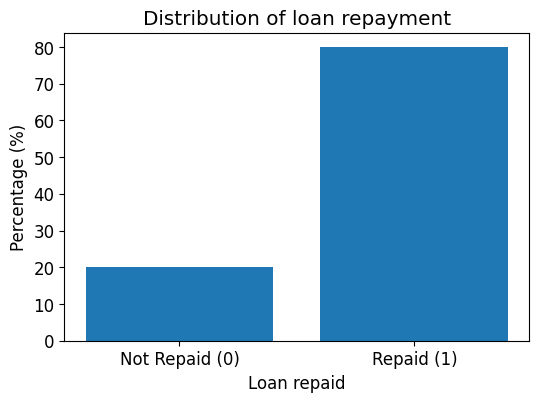

In [6]:
target_name = 'loan_paid_back'
target_counts = (
    train_data[target_name]
    .value_counts(normalize = True)
    .mul(100)
    .rename("percentage")
    .sort_index())
display(Markdown(f"**Class distribution for `{target_name}` (%)**"))
display(target_counts.to_frame())

plt.figure(figsize = (6, 4))
plt.bar(
    x = target_counts.index.astype(int),
    height = target_counts.values)
plt.title("Distribution of loan repayment")
plt.xlabel("Loan repaid")
plt.ylabel("Percentage (%)")
plt.xticks([0, 1], ["Not Repaid (0)", "Repaid (1)"])
plt.show()

#### Key observations and implications

- The target variable is moderately imbalanced, with approximately 80% of loans repaid and 20% defaulted.
- This imbalance suggests that accuracy alone is not an appropriate evaluation metric.
- Probability-based metrics and explicit decision threshold selection will be required.

### Feature definition and separation

In [7]:
y = train_data['loan_paid_back']
x_train = train_data.drop(['id', 'loan_paid_back'], axis = 1)
x_test = test_data.drop(['id'], axis = 1)

numerical_features = x_train.select_dtypes(include = np.number).columns.tolist()
categorical_features = x_train.select_dtypes(include = 'object').columns.tolist()

md("**Numerical feature statistics**")
display(x_train[numerical_features].describe().T)

**Numerical feature statistics**

,count,mean,std,min,25%,50%,75%,max
annual_income,593994.0,48212.202976,26711.942078,6002.430,27934.400,46557.680,60981.320,393381.740
debt_to_income_ratio,593994.0,0.120696,0.068573,0.011,0.072,0.096,0.156,0.627
credit_score,593994.0,680.916009,55.424956,395.000,646.000,682.000,719.000,849.000
loan_amount,593994.0,15020.297629,6926.530568,500.090,10279.620,15000.220,18858.580,48959.950
interest_rate,593994.0,12.356345,2.008959,3.200,10.990,12.370,13.680,20.990


- The target variable was separated from the feature set, and identifier columns were removed.
- Numerical and categorical features were identified to enable feature-type–specific preprocessing.
- Basic descriptive statistics provide an initial overview of feature scales and distributions.

### Numerical feature analysis

### Distribution of numerical features by loan repayment status

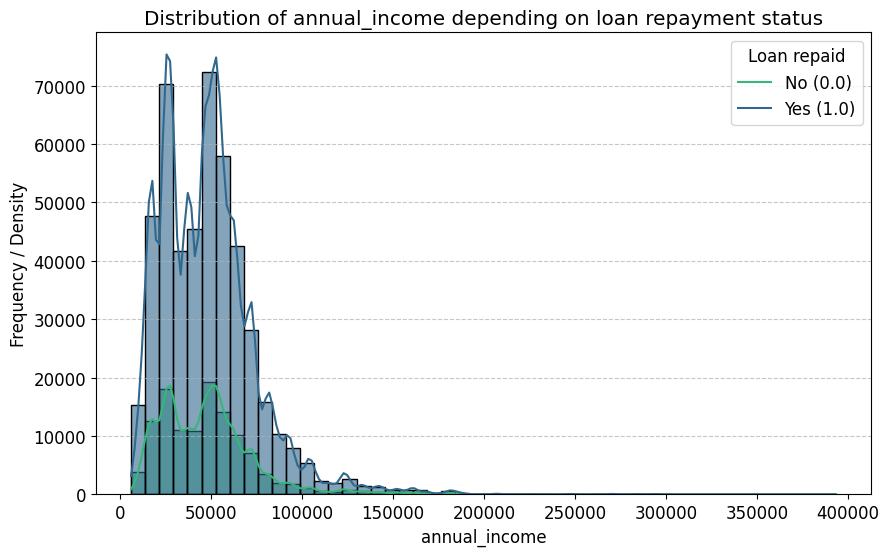

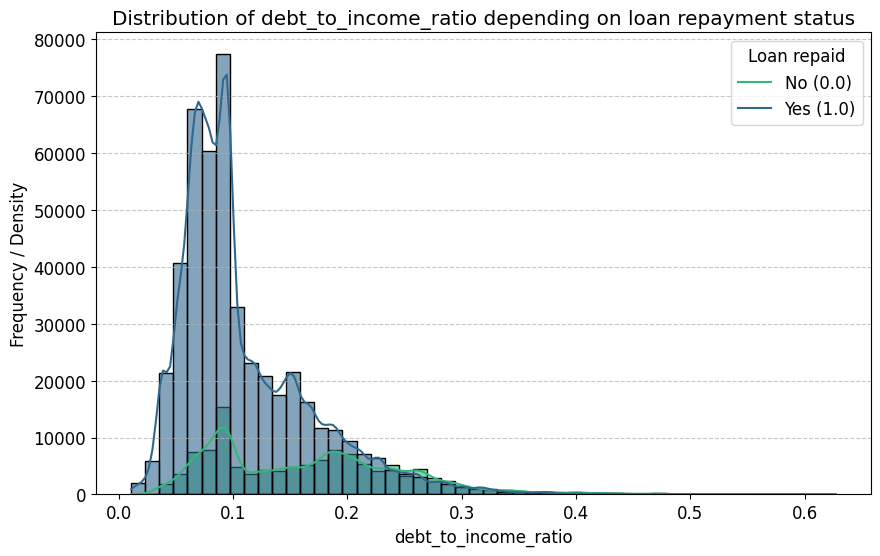

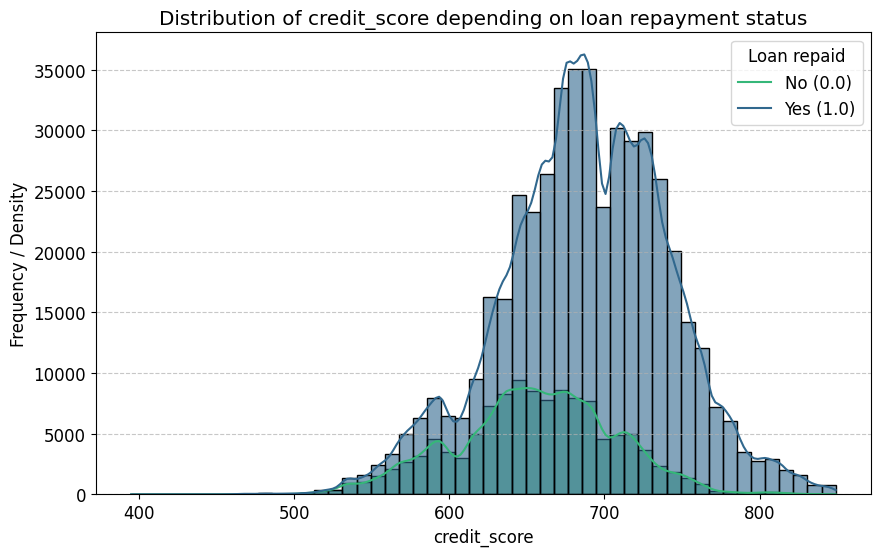

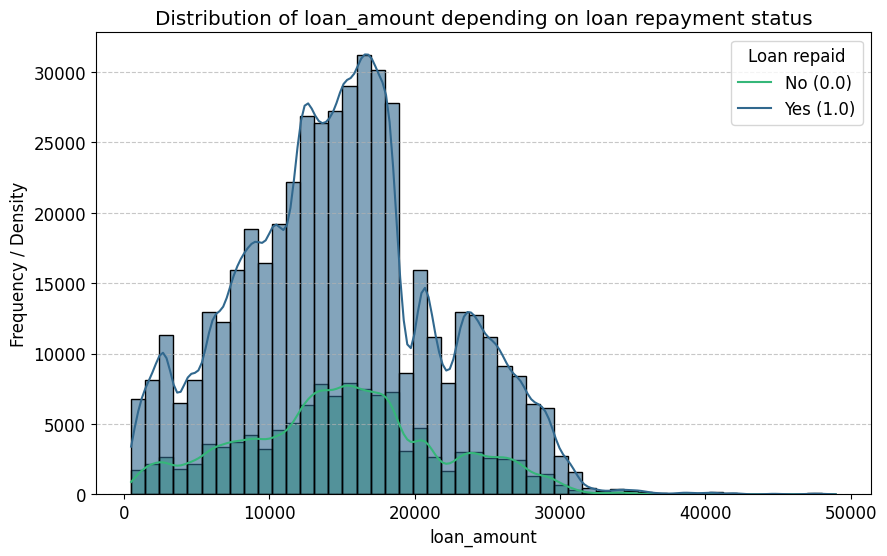

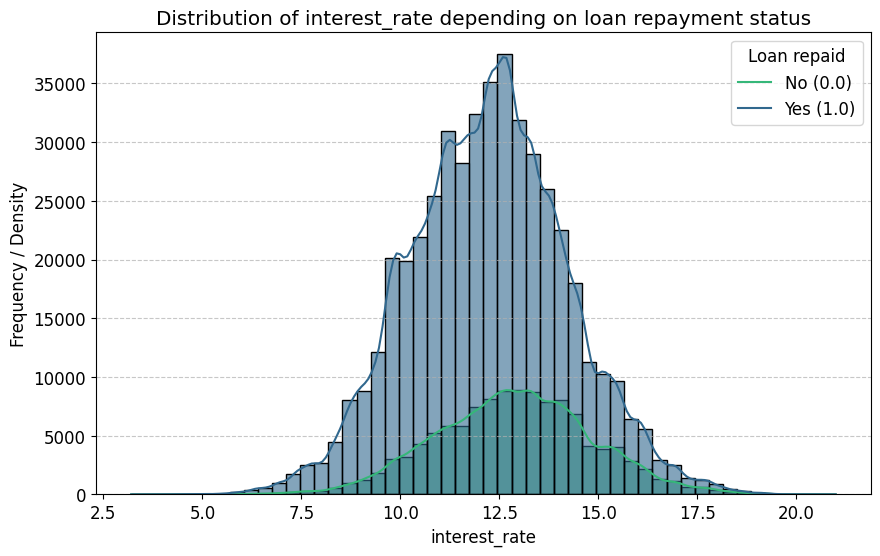

In [8]:
df_num = train_data.copy()
df_num[target_name] = df_num[target_name].astype(str)

for col in numerical_features:
    plt.figure(figsize = (10, 6))
    sns.histplot(
        data = df_num,
        x = col, 
        hue = target_name, 
        bins = 50,
        kde = True,
        alpha = 0.6,
        palette = 'viridis')
    plt.title(f'Distribution of {col} depending on loan repayment status')
    plt.xlabel(col)
    plt.ylabel('Frequency / Density')
    plt.legend(title = 'Loan repaid' , labels = ['No (0.0)', 'Yes (1.0)'])
    plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
    plt.show()

#### Key observations and implications

- Key numerical features, such as annual_income and debt_to_income_ratio, exhibit a highly right-skewed distribution, with their primary peaks sharply concentrated on the left side of the axis. This suggests a deviation from the normal distribution.
- To potentially improve the stability and performance of linear models, a logarithmic transformation to the skewed features and utilizing a RobustScaler are can be used for addressing the non-normality and reducing the impact of extreme values during preprocessing.

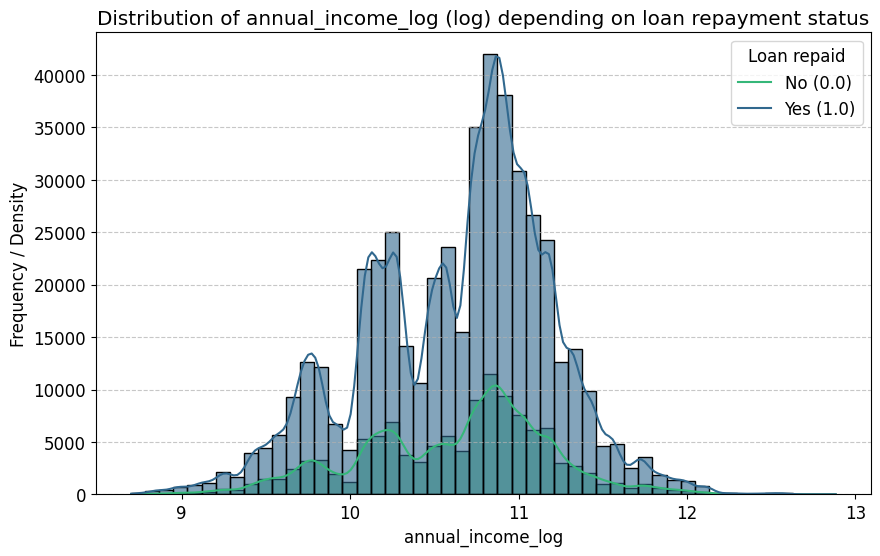

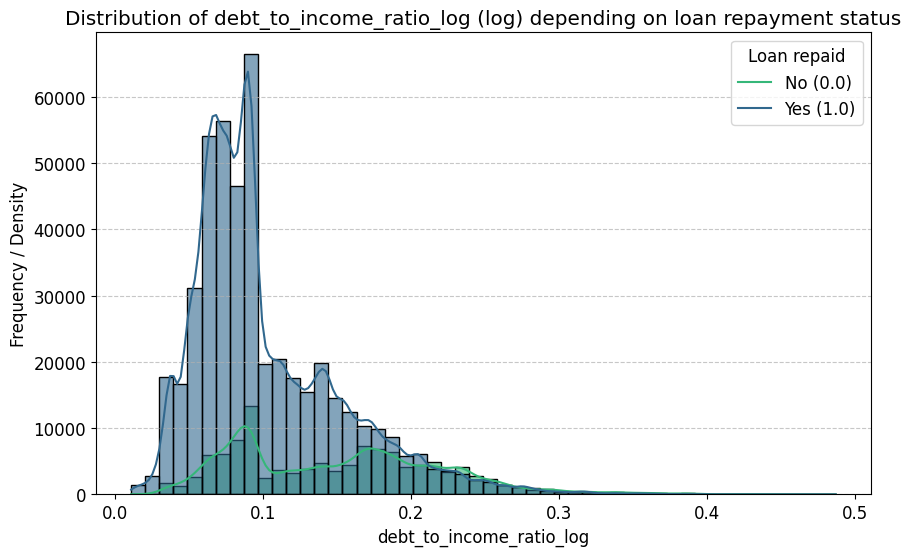

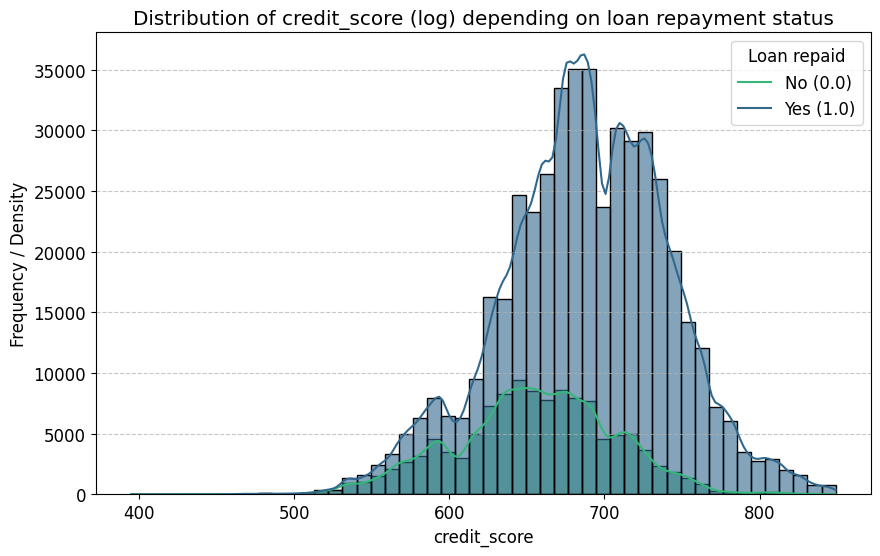

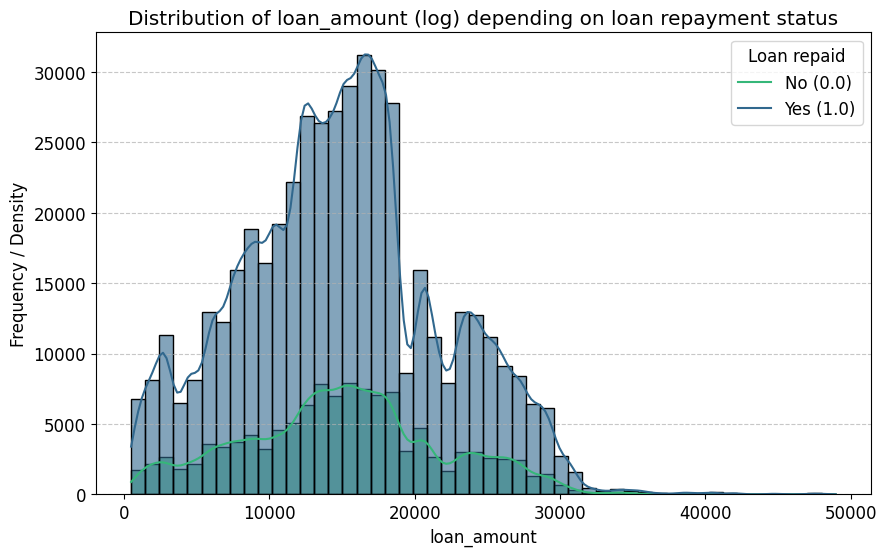

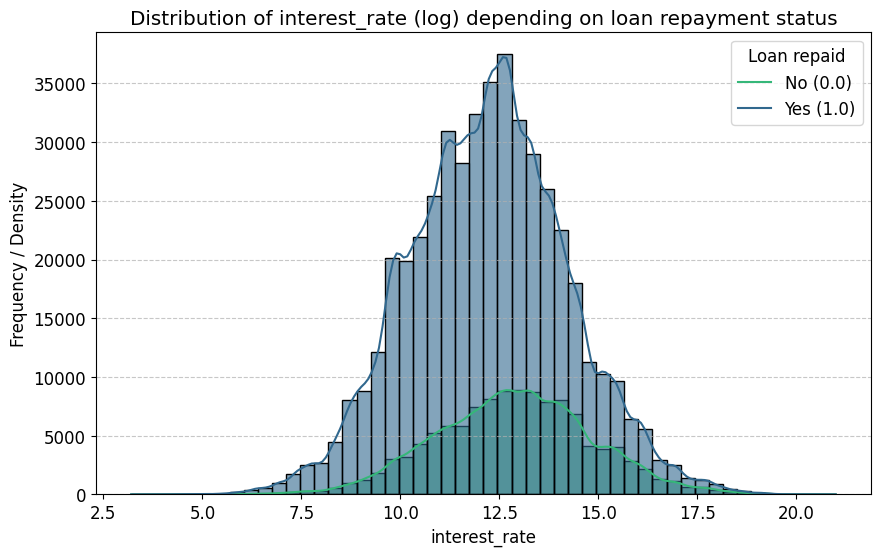

In [9]:
df_num_log = df_num.copy() 
df_num_log['annual_income_log'] = np.log1p(df_num_log['annual_income'])
df_num_log['debt_to_income_ratio_log'] = np.log1p(df_num_log['debt_to_income_ratio'])
num_log_cols = [
    'annual_income_log', 
    'debt_to_income_ratio_log', 
    'credit_score', 
    'loan_amount', 
    'interest_rate']

for col in num_log_cols:
    plt.figure(figsize = (10, 6))
    sns.histplot(
        data = df_num_log,
        x = col, 
        hue = target_name, 
        bins = 50,
        kde = True,
        alpha = 0.6,
        palette = 'viridis')
    if 'log' in col:
        original_name = col.replace("_log", "")
        title_name = f'Distribution of {original_name} (log) by repayment status'
    else:
        title_name = f'Distribution of {col} (original values) by repayment status'
    plt.title(f'Distribution of {col} (log) depending on loan repayment status')
    plt.xlabel(col)
    plt.ylabel('Frequency / Density')
    plt.legend(title = 'Loan repaid' , labels = ['No (0.0)', 'Yes (1.0)'])
    plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
    plt.show()

#### Key observations and implications

- Logarithmic transformation has a stronger impact on unbounded numerical features such as annual_income. For bounded ratio features, like debt_to_income_ratio, the transformation primarily smooths the distribution and reduces the influence of outliers without substantially altering the overall scale.
- Log-transformed features combined with robust scaling are expected to improve model stability.

### Box plot analysis of numerical features by loan repayment status

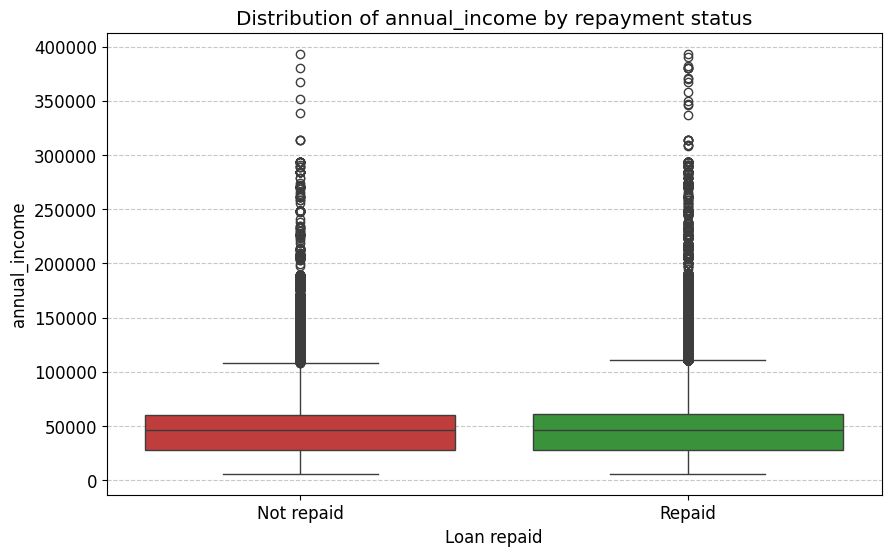

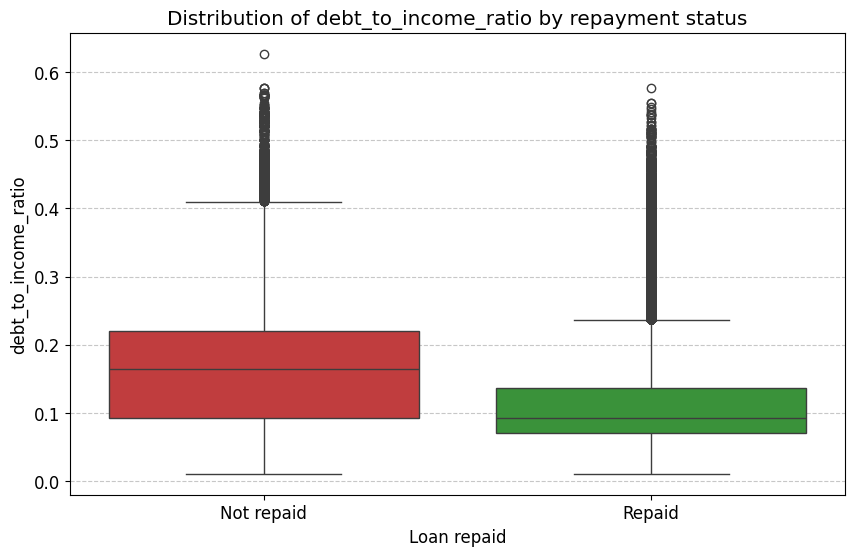

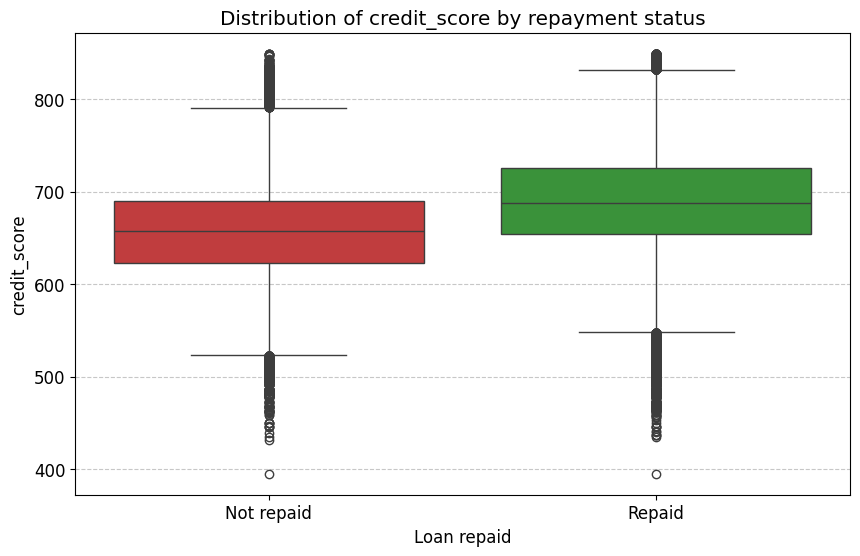

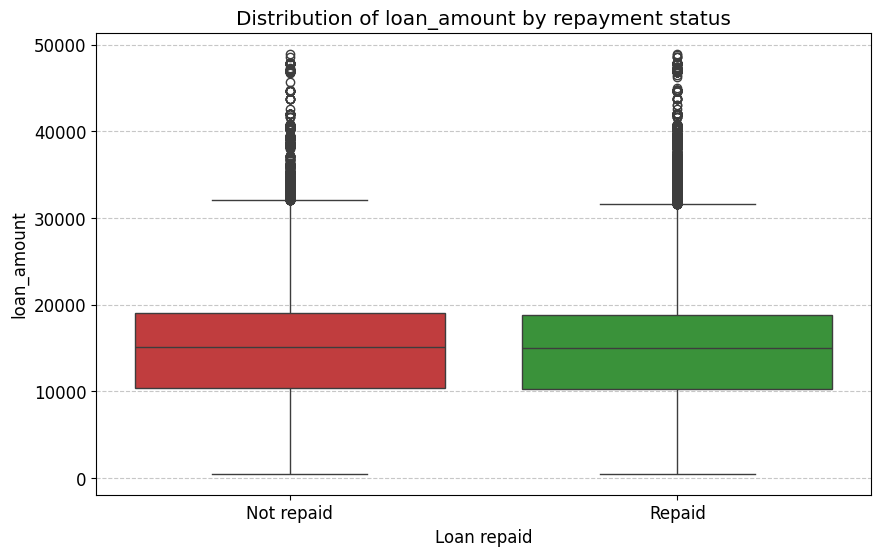

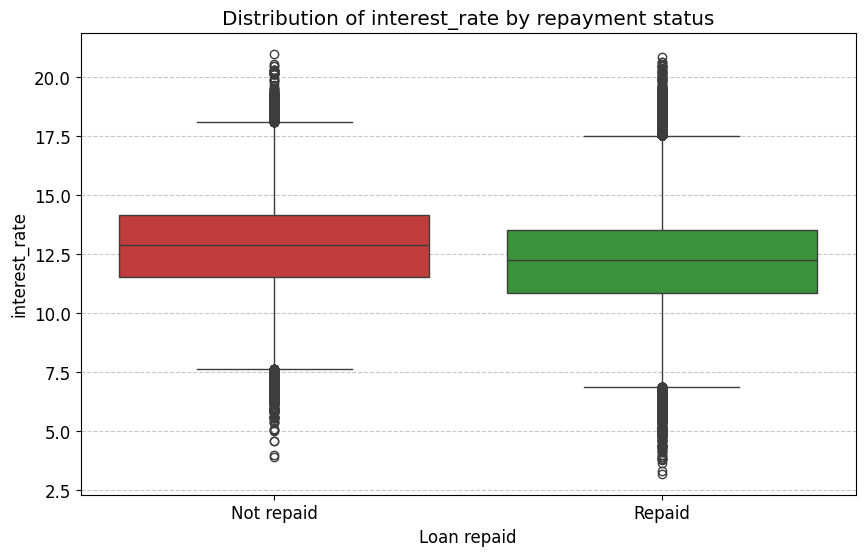

In [10]:
# Prepare a clean binary target for visualization purposes only
df_num = df_num.copy()

df_num[target_name] = (
    df_num[target_name]
    .astype(float)
    .astype(int))

# Create human-readable categorical labels for clear EDA interpretation
df_num["repayment_status"] = pd.Categorical(
    df_num[target_name].map({0: "Not repaid", 1: "Repaid"}),
    categories = ["Not repaid", "Repaid"],
    ordered = True)

# Consistent color mapping for repayment classes
palette_map = {
    "Not repaid": "#d62728",
    "Repaid": "#2ca02c"}

# Box plot analysis of numerical features by loan repayment status
for col in numerical_features:
    plt.figure(figsize = (10, 6))

    sns.boxplot(
        x = "repayment_status",
        y = col,
        data = df_num,
        palette = palette_map)

    plt.title(f"Distribution of {col} by repayment status")
    plt.xlabel("Loan repaid")
    plt.ylabel(col)
    plt.grid(axis = "y", linestyle = "--", alpha = 0.7)
    plt.show()

# Cleanup: remove auxiliary columns used only for visualization
df_num.drop(columns = ["repayment_status"], inplace = True)

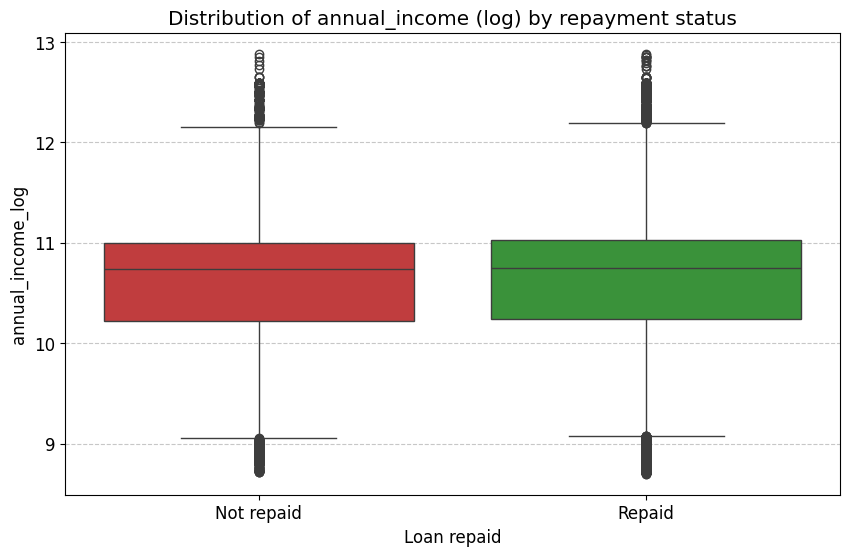

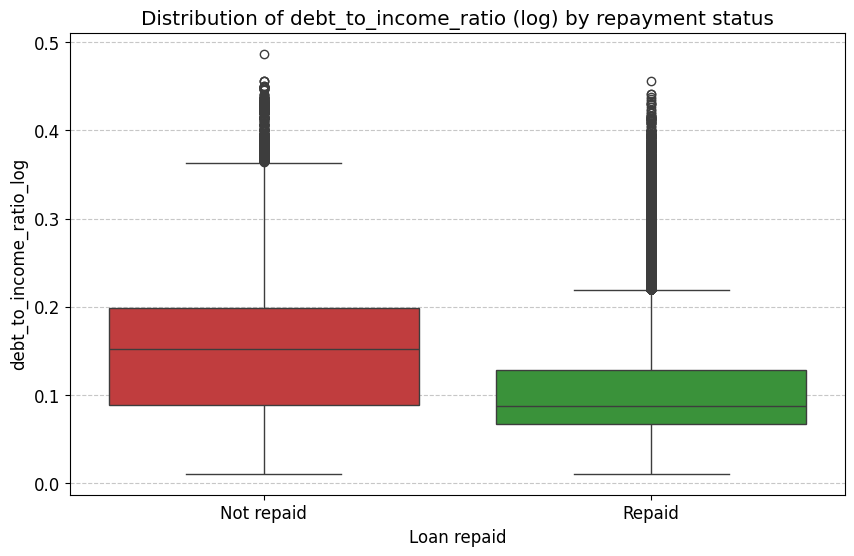

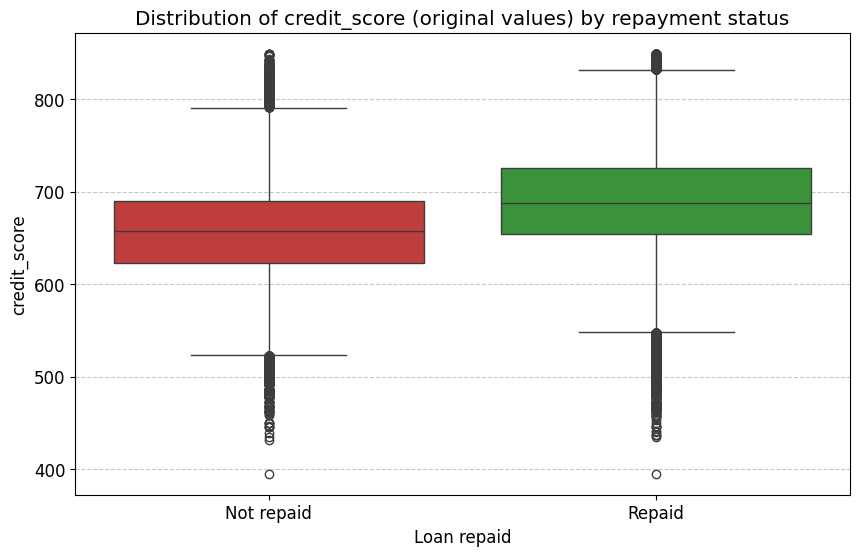

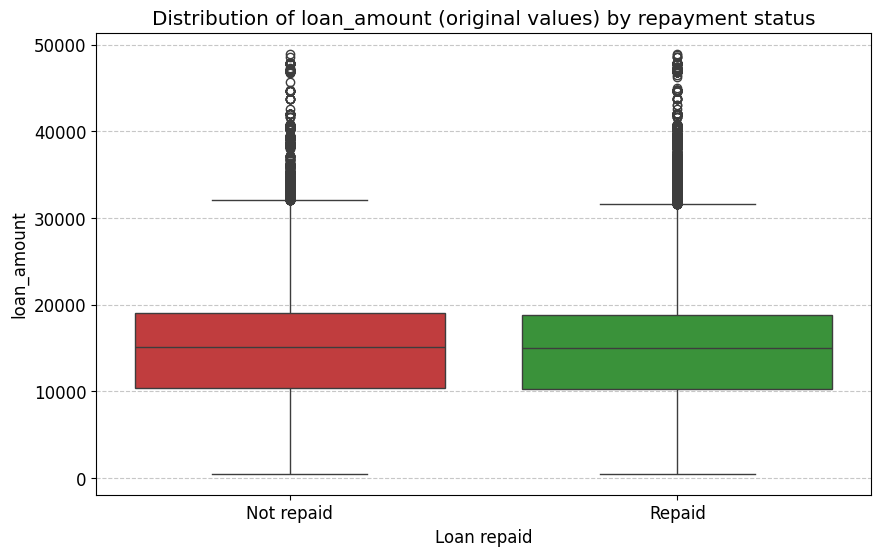

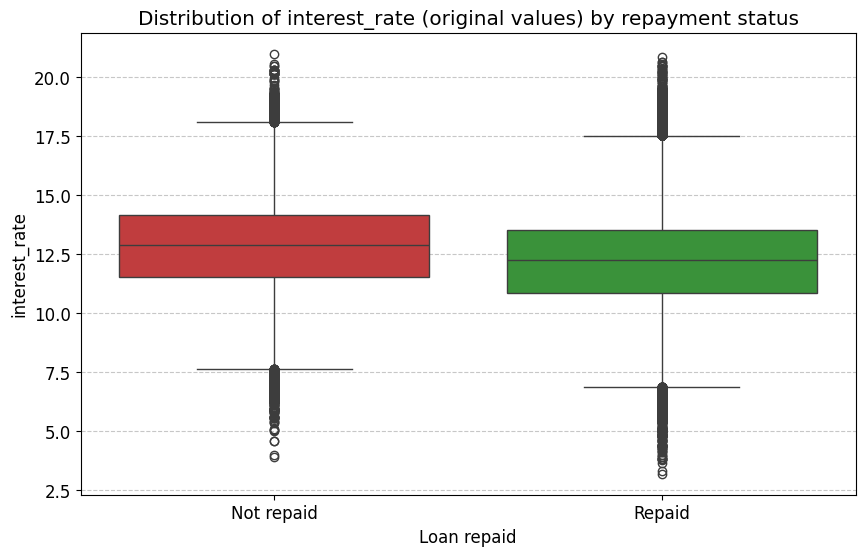

In [11]:
# Prepare a clean binary target for visualization purposes only
df_num_log = df_num_log.copy()
df_num_log["_target01"] = pd.to_numeric(df_num_log[target_name], errors = "coerce")

# Drop rows with invalid / missing target values
df_num_log = df_num_log.dropna(subset = ["_target01"]).copy()

# Enforce strict binary integer encoding (0 / 1)
df_num_log["_target01"] = df_num_log["_target01"].astype(int)

# Create human-readable categorical labels for stable and clean plots
df_num_log["repayment_status"] = pd.Categorical(
    df_num_log["_target01"].map({0: "Not repaid", 1: "Repaid"}),
    categories = ["Not repaid", "Repaid"],
    ordered = True)

# Consistent color mapping for repayment classes
palette_map = {
    "Not repaid": "#d62728",
    "Repaid": "#2ca02c"}

# Box plot analysis of log-transformed numerical features by loan repayment status
for col in num_log_cols:
    plt.figure(figsize = (10, 6))

    sns.boxplot(
        x = "repayment_status",
        y = col,
        data = df_num_log,
        palette = palette_map)

    # Adjust title depending on whether the feature is log-transformed
    if col.endswith("_log"):
        original_name = col.replace("_log", "")
        title_name = f"Distribution of {original_name} (log) by repayment status"
    else:
        title_name = f"Distribution of {col} (original values) by repayment status"

    plt.title(title_name)
    plt.xlabel("Loan repaid")
    plt.ylabel(col)
    plt.grid(axis = "y", linestyle = "--", alpha = 0.7)
    plt.show()

# Cleanup: remove auxiliary columns used only for visualization
df_num_log.drop(columns = ["_target01", "repayment_status"], inplace = True)

#### Key observations and implications

- The box plots confirm the distribution patterns observed in the histogram analysis. Numerical features with heavy right-tailed distributions, such as `annual_income` and `loan_amount`, exhibit a large number of high-value outliers and noticeable spread differences between repayment groups.
- After logarithmic transformation, the distributions become more compact, with reduced influence of extreme values and narrower interquartile ranges. For bounded features such as `debt_to_income_ratio`, the relative position of the median remains stable across both original and log-transformed scales.
- Box plot analysis validates the suitability of logarithmic transformation primarily for unbounded numerical features, where it effectively mitigates outlier impact and stabilizes variability.

### Correlation of numerical features with the target variable

In [12]:
feature_target_corr = df_num[numerical_features].corrwith(df_num[target_name]).sort_values(ascending = False)
display(feature_target_corr.round(4).rename("corr_with_target").to_frame().sort_values("corr_with_target", ascending = False))

,corr_with_target
credit_score,0.2346
annual_income,0.0063
loan_amount,-0.0038
interest_rate,-0.1312
debt_to_income_ratio,-0.3357


#### Key observations and implications 

- The correlation analysis reveals a strong positive linear relationship between `credit_score` and the target variable, and a strong negative relationship with `debt_to_income_ratio`. Conversely, `annual_income` and `loan_amount` show extremely weak linear correlations with the target variable.
- Features with very low absolute correlation (such as `annual_income` and `loan_amount`) are likely to have minimal direct predictive power in a linear model. For linear algorithms, these features may be excluded after empirical  validation, while they are retained for tree-based and non-linear models.

### Multicollinearity check (correlation matrix and heatmap)

,feature_1,feature_2,abs_correlation
0,interest_rate,credit_score,0.538335
1,credit_score,debt_to_income_ratio,0.061617
2,interest_rate,debt_to_income_ratio,0.030316
3,loan_amount,debt_to_income_ratio,0.008236
4,loan_amount,credit_score,0.005761
5,loan_amount,annual_income,0.003407
6,interest_rate,annual_income,0.002507
7,credit_score,annual_income,0.001509
8,interest_rate,loan_amount,0.001174
9,debt_to_income_ratio,annual_income,0.000553


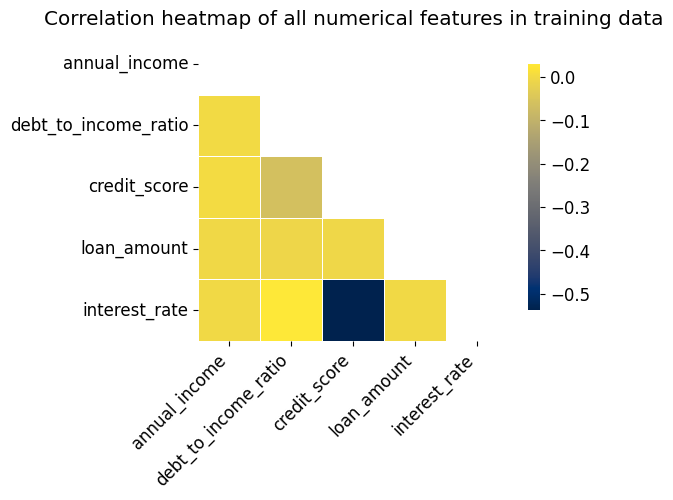

In [13]:
corr_matrix = x_train[numerical_features].corr()

triangle = corr_matrix.abs().where(np.tril(np.ones(corr_matrix.shape), k = -1).astype(bool))
top_corr = (
    triangle
    .stack()
    .sort_values(ascending = False)
    .head(10)
    .rename("abs_correlation")
    .reset_index()
    .rename(columns = {
        "level_0": "feature_1",
        "level_1": "feature_2"}))
display(top_corr)

n_features = corr_matrix.shape[0]
mask = np.triu(corr_matrix)
plt.figure(figsize = (5, 4))
sns.heatmap(
    corr_matrix, 
    mask = mask,
    annot = False,
    cmap = 'cividis',
    fmt = ".2f", 
    linewidths = 0.5,
    cbar_kws = {'shrink': 0.8})
plt.title('Correlation heatmap of all numerical features in training data')
plt.xticks(rotation = 45, ha = 'right')
plt.yticks(rotation = 0)
plt.show()

#### Key observations and implications

- The correlation analysis between all pairs of numerical features in both the training and test datasets shows that the vast majority of correlations are extremely weak. The only moderate relationship observed is between `interest_rate` and `credit_score`but it is not high enough to indicate severe multicollinearity.  
- Since there is no evidence of strong multicollinearity in either the training or test data (no feature pairs with |r| > 0.8), all numerical features can be safely retained in the modeling process.

#### Numerical feature analysis summary

- Numerical features exhibit heterogeneous scales, skewness, and outlier
- `Debt_to_income_ratio` and `credit_score` emerge as the most informative numerical predictors.
- Logarithmic transformation will be considered selectively for features with pronounced right-skewed distributions in order to correct distributional
asymmetry. Outlier handling will be explored as an optional preprocessing strategy and evaluated experimentally. Feature scaling will be applied consistently, with robust scaling considered as the primary approach and standard scaling used for comparison.ps.

### Categorical feature analysis

### Analysis of categorical features by loan repayment status

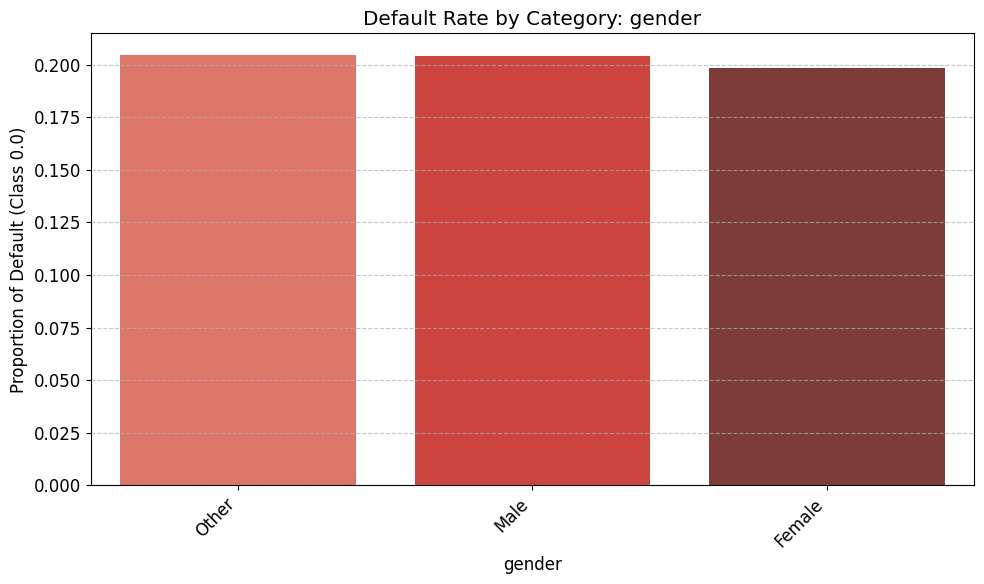

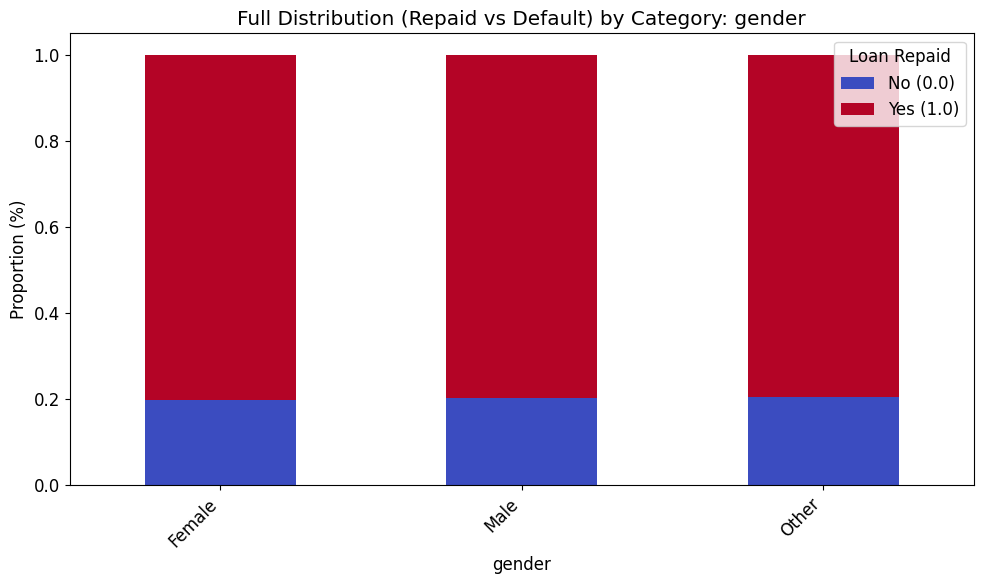

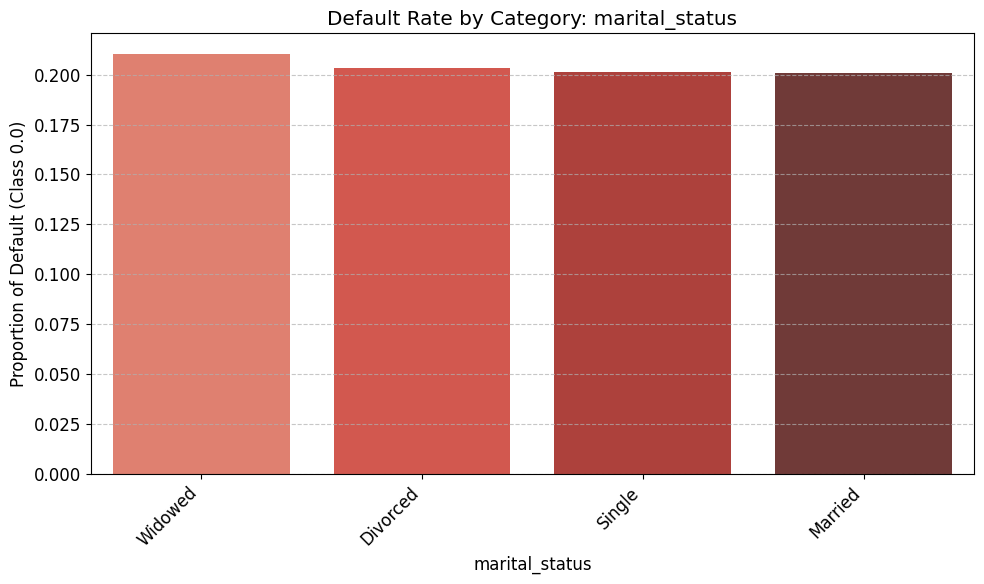

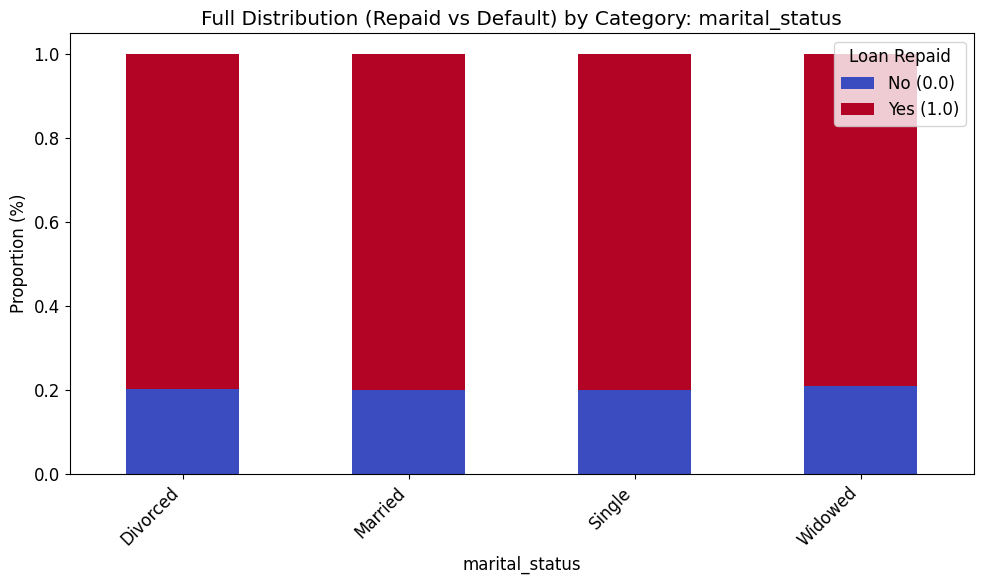

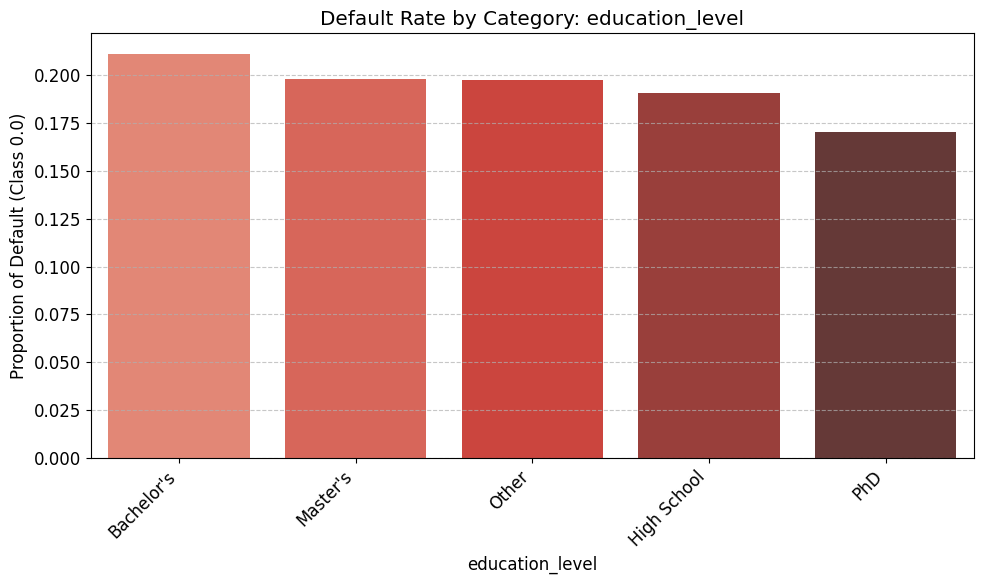

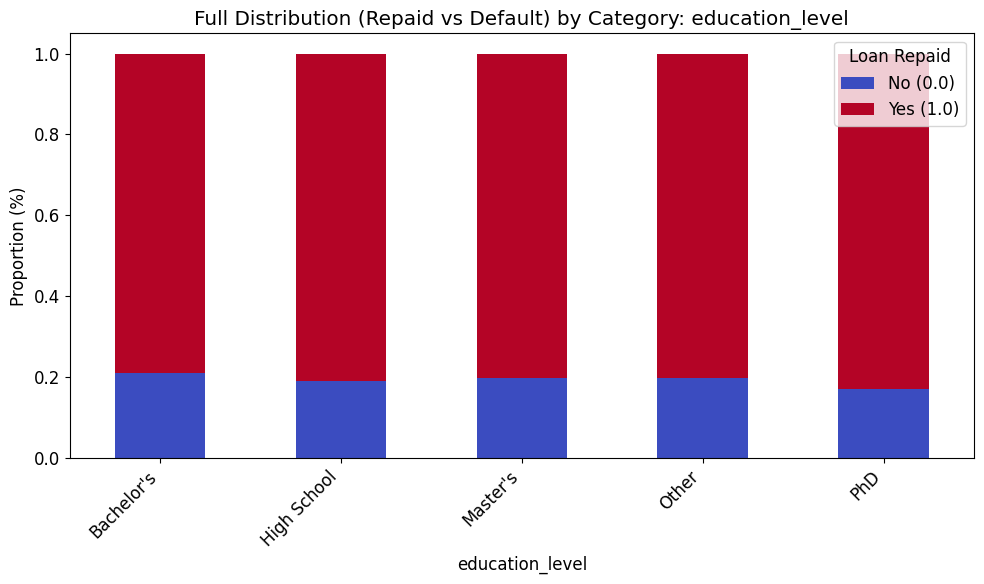

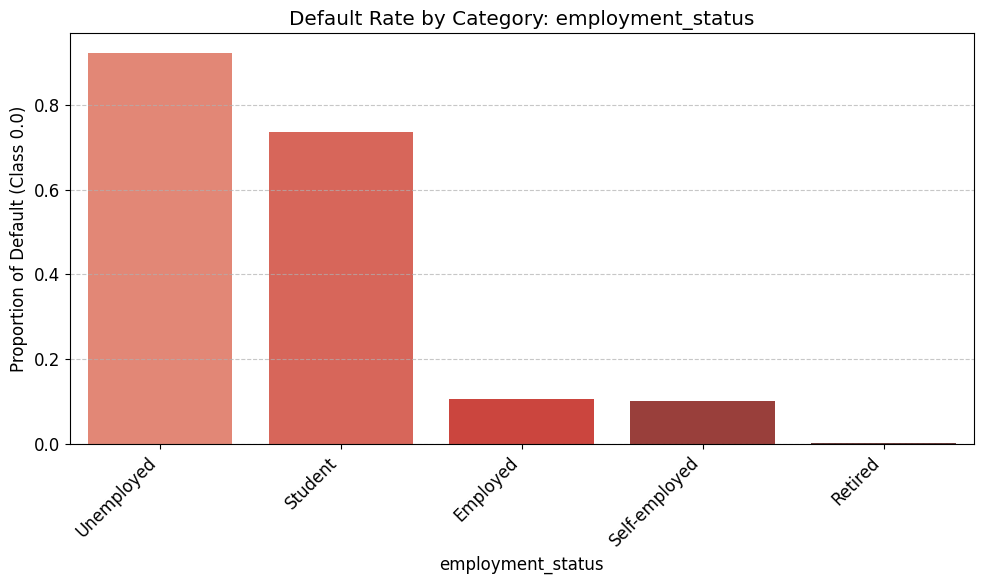

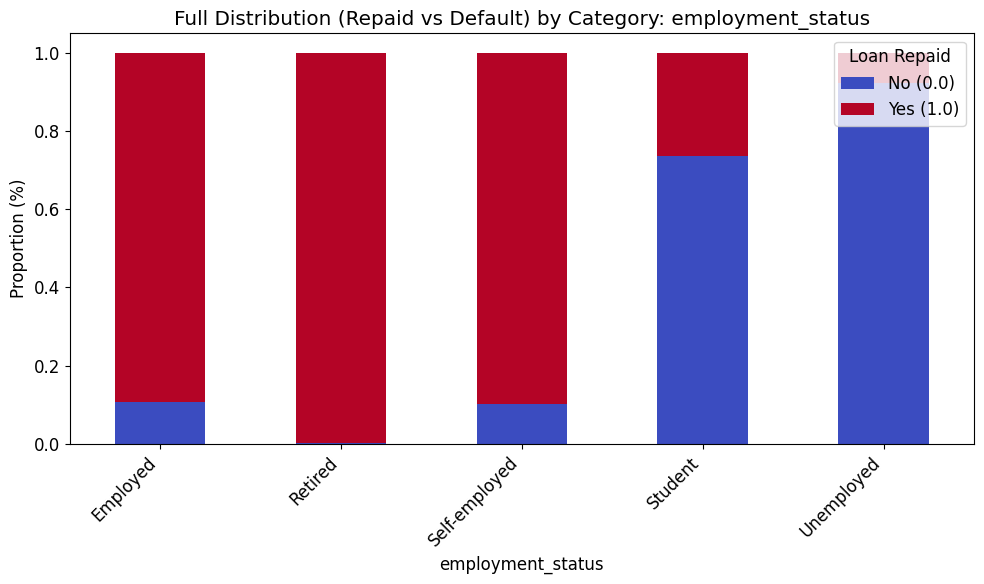

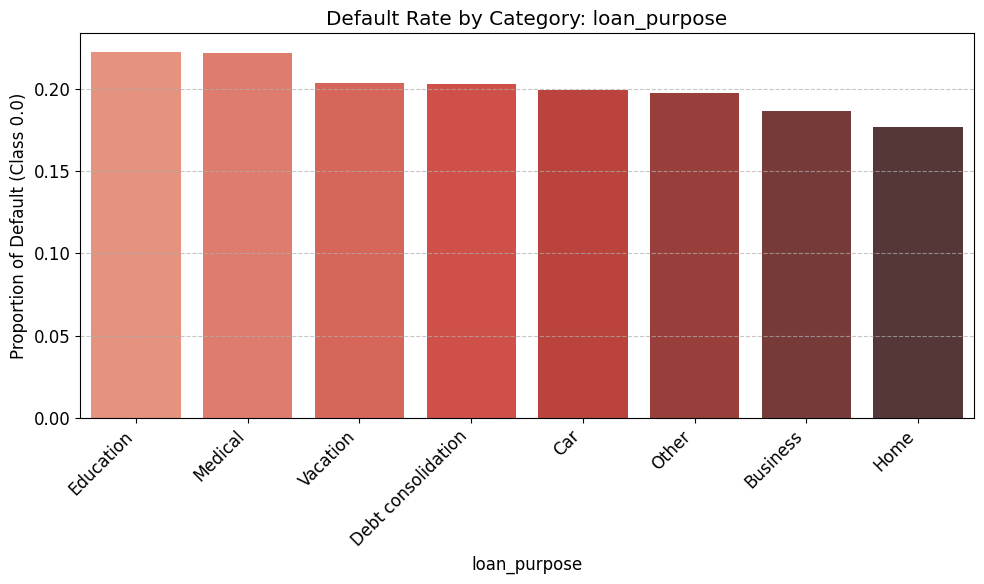

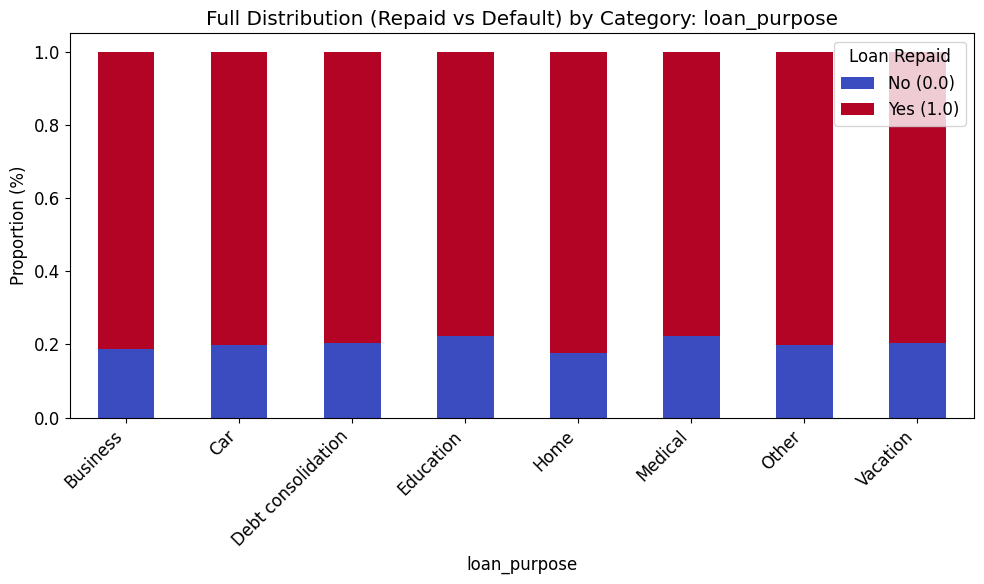

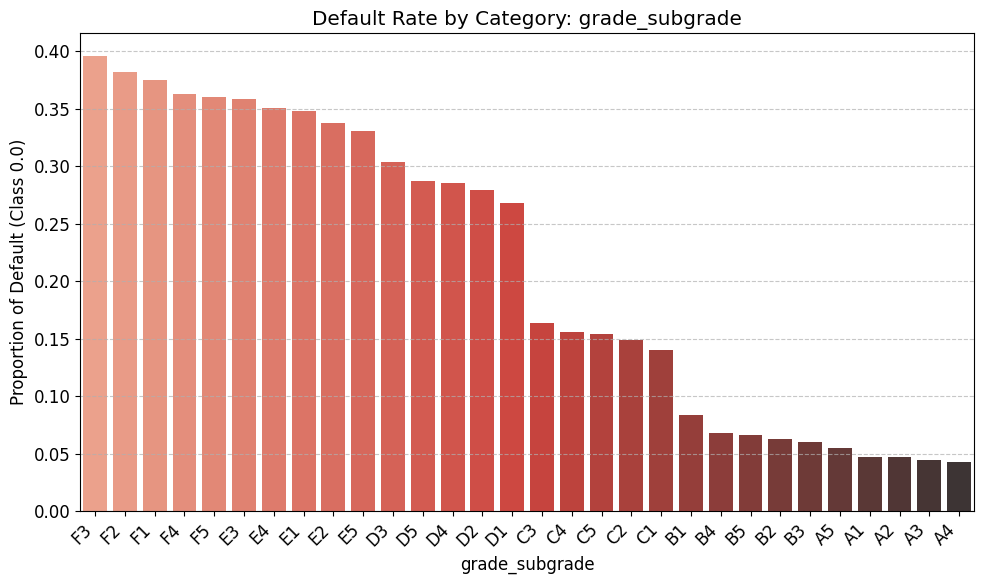

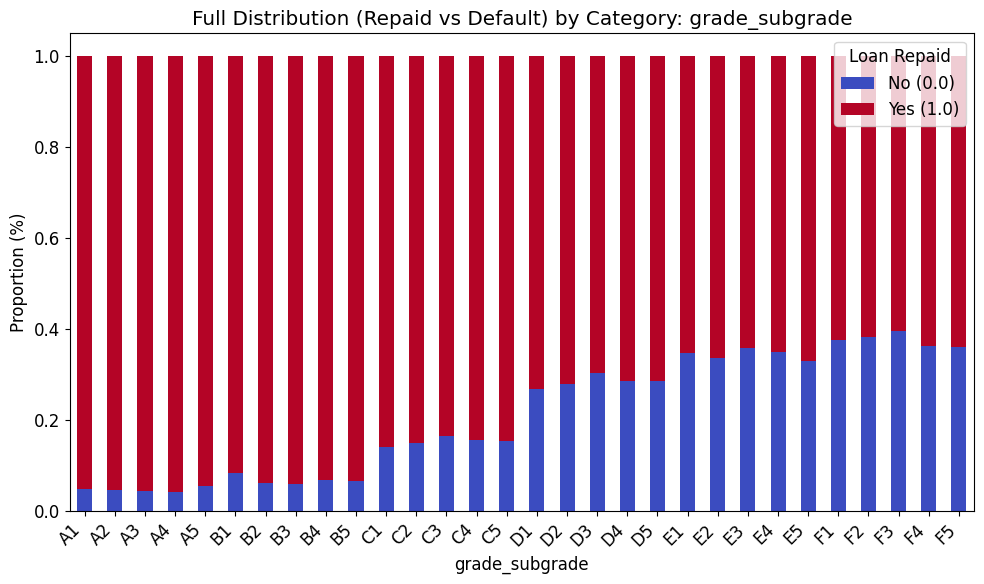

In [14]:
for col in categorical_features:
    risk_table = pd.crosstab(df_num[col], df_num[target_name], normalize = 'index')
    default_rate = risk_table[0].sort_values(ascending = False)
    plt.figure(figsize = (10, 6))
    sns.barplot(
        x = default_rate.index, 
        y = default_rate.values, 
        palette = 'Reds_d')
    plt.title(f'Default Rate by Category: {col}')
    plt.xlabel(col)
    plt.ylabel('Proportion of Default (Class 0.0)')
    plt.xticks(rotation = 45, ha = 'right')
    plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
    plt.tight_layout()
    plt.show()
    
    plt.figure(figsize = (10, 6))
    risk_table.plot(kind = 'bar', stacked = True, ax = plt.gca(), cmap = 'coolwarm')
    plt.title(f'Full Distribution (Repaid vs Default) by Category: {col}')
    plt.xlabel(col)
    plt.ylabel('Proportion (%)')
    plt.xticks(rotation = 45, ha = 'right')
    plt.legend(title = 'Loan Repaid', labels = ['No (0.0)', 'Yes (1.0)'], loc = 'upper right')
    plt.tight_layout()
    plt.show()

#### Key observations and implications

- Default rates vary across categories for most categorical features, indicating  heterogeneous credit risk profiles within these variables.
- For some features, such as `marital_status`, the default rate appears relative 
  uniform across categories, suggesting limited univari te discriminative power.
- Visual differences observed in default rates require statistical validatio o
  distinguish meaningful associations from random variation.
- A formal chi-square test of independence is therefore used in the subs ent
  analysis to assess the statistical significance of the observed patterns.

### Statistical validation (chi-square test)

In [15]:
alpha = 0.05

chi2_rows = []
for feature_to_check in categorical_features:
    contingency_table = pd.crosstab(x_train[feature_to_check], y)
    chi2, p_value, _, _ = chi2_contingency(contingency_table)

    chi2_rows.append({
        "feature": feature_to_check,
        "p_value": p_value,
        "significant_(p<0.05)": p_value < alpha})

chi2_df = (
    pd.DataFrame(chi2_rows)
    .sort_values("p_value", ascending = True)
    .reset_index(drop = True))

chi2_df["p_value"] = chi2_df["p_value"].round(4)

md("**Chi-square test (categorical features vs target)**")
display(chi2_df)

**Chi-square test (categorical features vs target)**

,feature,p_value,significant_(p<0.05)
0,employment_status,0.0000,True
1,grade_subgrade,0.0000,True
2,education_level,0.0000,True
3,loan_purpose,0.0000,True
4,gender,0.0000,True
5,marital_status,0.2486,False


#### Categorical feature analysis summary

- Categorical features exhibit heterogeneous default rates across categorie 
  indicating meaningful variation in credit risk profiles.
- Statistical testing confirms significant associations for most categor l
  features, while `marital_status` shows weak univariate dependence on the target.
- For linear models, features with weak linear or univariate effects   be
  excluded after empirical validation.
- For non-linear and tree-based models, all categorical features are  ained
  due to potential interaction effects and non-linear contributions.

#### EDA conclusions and modeling strategy

- EDA findings will inform all preprocessing and modeling decisions.
- Feature transformations and selection strategies will be model-dependent and validated empirically.
- Multiple preprocessing pipelines will be evaluated to compare the impact of scaling, transformations, and feature selection on model performance.

<a id="data-preprocessing-and-pipeline-setup"></a>
## Data preprocessing & Pipeline setup

In [16]:
x_train_train, x_train_test, y_train, y_test = train_test_split(x_train, y, test_size = 0.2, random_state = 42, stratify = y)

- The dataset is split into training and validation subsets in an 80/20 ratio with stratification based on the target variable `loan_paid_back`. This preserves the original class distribution in each subset.

In [17]:
# Numerical feature groups based on EDA
numerical_features_log = ['annual_income', 'debt_to_income_ratio'] 
numerical_features_non_log = [col for col in numerical_features if col not in numerical_features_log]

# Feature subsets evaluated for linear models only
numerical_features_log_selected = [col for col in numerical_features_log if col !=  'annual_income']
numerical_features_non_log_selected = [col for col in numerical_features_non_log if col !=  'loan_amount']
categorical_features_selected = [col for col in categorical_features if col !=  'marital_status']

# Feature subset for clustering (exclude expert-driven grade)
categorical_features_clust = [col for col in categorical_features if col !=  'grade_subgrade']

- Logarithmic transformation will be considered for a small subset of numerical features (`annual_income`, `debt_to_income_ratio`) identified during EDA as strongly right-skewed.
- Features with weak linear or univariate effects (`annual_income`, `loan_amount`, `marital_status`) are excluded from the `*_selected` feature subsets. These subsets are evaluated only for linear models and validated empirically.
- All numerical and categorical features are retained for non-linear and tree-based models. Categorical features are processed through a dedicated encoding pipeline.


In [18]:
class Winsorizer(BaseEstimator, TransformerMixin):
    """The class clips each feature to [q_low, q_high] computed on the training data in fit().
    This prevents validation/test-dependent clipping (data leakage)."""
    
    def __init__(self, lower_quantile = 0.01, upper_quantile = 0.99):
        self.lower_quantile = lower_quantile
        self.upper_quantile = upper_quantile

    def fit(self, x, y = None):
        """Compute clipping thresholds (quantiles) on training data."""
        x_df = pd.DataFrame(x).astype(float)
        self.lower_ = x_df.quantile(self.lower_quantile).to_numpy(dtype = float)
        self.upper_ = x_df.quantile(self.upper_quantile).to_numpy(dtype = float)
        return self

    def transform(self, x):
        """Apply winsorization using precomputed quantile bounds."""
        x_arr = np.asarray(x, dtype = float)
        return np.clip(x_arr, self.lower_, self.upper_)

winsor_transformer = Winsorizer(lower_quantile = 0.01, upper_quantile = 0.99)

- Winsorization is implemented as a custom transformer following the scikit-learn fit/transform protocol. Clipping thresholds (1st and 99th percentiles) are estimated on the training data during `fit` and then reused for validation and test sets.
- This ensures consistent outlier handling and prevents data leakage during cross-validation and model evaluation.

In [19]:
def log_transform(x):
    """The function applies natural logarithm transformation (log1p) to the input data."""
    return np.log1p(x)

log_transformer = FunctionTransformer(log_transform, validate = False)

def get_log_pipeline(scaler):
    """The function creates a pipeline that first applies log1p transformation, then scales the data using the provided scaler."""
    return Pipeline([('log1p', log_transformer), ('scaler', scaler)])

def get_scale_only_pipeline(scaler):
    """The function creates a pipeline that scales the input data using the provided scaler without any transformation."""
    return Pipeline([('scaler', scaler)])

def get_log_pipeline_only():
    """The function creates a pipeline that applies only log1p transformation without scaling."""
    return Pipeline([('log1p', log_transformer)])

def get_numeric_pipeline(scaler, use_log = False):
    """The function creates a numeric preprocessing pipeline that applies winsorization, optional log transformation, and scaling."""
    steps = [('winsor', winsor_transformer)]
    if use_log:
        steps.append(('log1p', log_transformer))
    steps.append(('scaler', scaler))
    return Pipeline(steps)

- This block defines reusable preprocessing components for numerical features, implemented in a modular and pipeline-compatible manner.
- A logarithmic transformation (`log1p`) is defined as a deterministic, element-wise operation and is considered for a limited subset of numerical features identified during EDA as strongly right-skewed. The transformation is intended to address distributional asymmetry rather than outlier magnitude.
- Scaling is applied after optional transformations (log1p and/or winsorization) to standardize feature ranges. Both `StandardScaler` and `RobustScaler` are evaluated to compare their impact on model performance.
- Winsorization is integrated as an optional preprocessing step to limit the influence of extreme values. It is implemented as a stateful transformer and learns clipping thresholds on the training data only, ensuring consistent application across validation and test sets without introducing data leakage.
- In the winsorized pipelines, clipping is applied before log transformation to stabilize extreme values prior to scaling.
- Helper functions are used to flexibly construct numerical preprocessing pipelines with different combinations of winsorization, logarithmic transformation, and scaling. This design enables systematic comparison of alternative preprocessing strategies across models.

In [20]:
preprocessor_baseline = ColumnTransformer(
    transformers = [
        ('scaler', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown = 'ignore', sparse_output = False), categorical_features)],
    remainder = 'passthrough',
    n_jobs = -1)

preprocessor_full_ss = ColumnTransformer(
    transformers = [
        ('log_scale_ss', get_log_pipeline(StandardScaler()), numerical_features_log),
        ('scale_only_ss', get_scale_only_pipeline(StandardScaler()), numerical_features_non_log),
        ('cat', OneHotEncoder(handle_unknown = 'ignore', sparse_output = False), categorical_features)],
    remainder = 'drop',
    n_jobs = -1)

preprocessor_full_rs = ColumnTransformer(
    transformers = [
        ('log_scale_rs', get_log_pipeline(RobustScaler()), numerical_features_log),
        ('scale_only_rs', get_scale_only_pipeline(RobustScaler()), numerical_features_non_log),
        ('cat', OneHotEncoder(handle_unknown = 'ignore', sparse_output = False), categorical_features)],
    remainder = 'drop',
    n_jobs = -1)

preprocessor_full_rs_clust = ColumnTransformer(
    transformers = [
        ('log_scale_rs', get_log_pipeline(RobustScaler()), numerical_features_log),
        ('scale_only_rs', get_scale_only_pipeline(RobustScaler()), numerical_features_non_log),
        ('cat', OneHotEncoder(handle_unknown = 'ignore', sparse_output = False), categorical_features_clust)],
    remainder = 'drop',
    n_jobs = -1)

preprocessor_selected_ss = ColumnTransformer(
    transformers = [
        ('log_scale_ss', get_log_pipeline(StandardScaler()), numerical_features_log_selected),
        ('scale_only_ss', get_scale_only_pipeline(StandardScaler()), numerical_features_non_log_selected),
        ('cat', OneHotEncoder(handle_unknown = 'ignore', sparse_output = False), categorical_features_selected)],
    remainder = 'drop',
    n_jobs = -1)

preprocessor_selected_rs = ColumnTransformer(
    transformers = [
        ('log_scale_rs', get_log_pipeline(RobustScaler()), numerical_features_log_selected),
        ('scale_only_rs', get_scale_only_pipeline(RobustScaler()), numerical_features_non_log_selected),
        ('cat', OneHotEncoder(handle_unknown = 'ignore', sparse_output = False), categorical_features_selected)],
    remainder = 'drop',
    n_jobs = -1)

preprocessor_full_nb = ColumnTransformer(
    transformers = [
        ('log_only', get_log_pipeline_only(), numerical_features_log),
        ('num_passthrough', 'passthrough', numerical_features_non_log),
        ('cat', OneHotEncoder(handle_unknown = 'ignore', sparse_output = False), categorical_features)],
    remainder = 'drop',
    n_jobs = -1)

preprocessor_selected_nb = ColumnTransformer(
    transformers = [
        ('log_only', get_log_pipeline_only(), numerical_features_log_selected),
        ('num_passthrough', 'passthrough', numerical_features_non_log_selected),
        ('cat', OneHotEncoder(handle_unknown = 'ignore', sparse_output = False), categorical_features_selected)],
    remainder = 'drop',
    n_jobs = -1)

preprocessor_ohe = ColumnTransformer(
    transformers = [
        ('cat', OneHotEncoder(handle_unknown = 'ignore', sparse_output = False), categorical_features)],
    remainder = 'passthrough',
    n_jobs = -1)

preprocessor_full_rs_winsor = ColumnTransformer(
    transformers = [
        ('num_log', get_numeric_pipeline(RobustScaler(), use_log = True), numerical_features_log),
        ('num_nonlog', get_numeric_pipeline(RobustScaler(), use_log = False), numerical_features_non_log),
        ('cat', OneHotEncoder(handle_unknown = 'ignore', sparse_output = False), categorical_features)],
    remainder = 'drop',
    n_jobs = -1)

preprocessor_selected_rs_winsor = ColumnTransformer(
    transformers = [
        ('num_log', get_numeric_pipeline(RobustScaler(), use_log = True), numerical_features_log_selected),
        ('num_nonlog', get_numeric_pipeline(RobustScaler(), use_log = False), numerical_features_non_log_selected),
        ('cat', OneHotEncoder(handle_unknown = 'ignore', sparse_output = False), categorical_features_selected)],
    remainder = 'drop',
    n_jobs = -1)

#### Preprocessing pipelines overview

- This block defines a collection of alternative preprocessing pipelines implemented using ColumnTransformer. Each pipeline represents a specific combination of feature selection, transformations, and scaling, and is designed to be paired with different model families.
- The purpose of this setup is to systematically compare preprocessing strategies, rather than assuming a single optimal configuration in advance.

**Baseline preprocessing**
- `preprocessor_baseline` applies:
    - StandardScaler to all numerical features,
    - one-hot encoding to all categorical features,
    - and passes through any remaining columns.
- This pipeline serves as a simple reference baseline with minimal assumptions and no feature selection or transformation beyond scaling and encoding.

**Full-feature preprocessing with scaling**
- `preprocessor_full_ss` and `preprocessor_full_rs` include:
    - logarithmic transformation for selected right-skewed numerical features,
    - scaling of numerical features using either:
        - StandardScaler (*_ss), or
        - RobustScaler (*_rs),
    - one-hot encoding of all categorical features.
- These pipelines retain all available features and are primarily evaluated with linear and distance-based models.

**Clustering-specific preprocessing**
- `preprocessor_full_rs_clust` follows the full robust-scaled pipeline, but excludes the expert-driven feature `grade_subgrade`.
- This allows clustering algorithms to explore latent structure in the data without relying on an existing credit risk label.

**Selected-feature preprocessing** (linear models)
- `preprocessor_selected_ss` and `preprocessor_selected_rs` use reduced feature subsets identified during EDA.
- Features with weak linear or univariate effects (e.g. annual_income, loan_amount, marital_status) are excluded.
- These pipelines are evaluated only for linear models, where feature redundancy and weak predictors can negatively affect stability and interpretability.
- Both standard and robust scaling variants are considered.

**Naive Bayes–specific preprocessing**
- `preprocessor_full_nb` and `preprocessor_selected_nb` are tailored for Naive Bayes models:
    - logarithmic transformation is applied without scaling,
    - non-log numerical features are passed through unchanged,
    - categorical features are one-hot encoded.
- This configuration reflects the assumptions of Gaussian Naive Bayes and is evaluated separately from other model families.

**Categorical-only preprocessing**
- `preprocessor_ohe` applies one-hot encoding to categorical features only, while numerical features are passed through unchanged.
- This setup is suitable for models that are insensitive to feature scaling, such as tree-based methods.

**Pipelines with winsorization**
- `preprocessor_full_rs_winsor` and `preprocessor_selected_rs_winsor` extend the robust-scaled pipelines by:
    - applying winsorization to numerical features,
    - optionally applying logarithmic transformation to right-skewed features,
    - and consistently scaling all numerical features using RobustScaler.
- Winsorization is treated as an optional preprocessing strategy aimed at limiting the influence of extreme values rather than removing observations.
- The clipping thresholds (1st and 99th percentiles) are heuristic and evaluated empirically.
- These pipelines are compared against non-winsorized alternatives to assess the impact of outlier handling on model performance.

**General design considerations**
- All preprocessing pipelines:
    - are fitted exclusively on the training data,
    - are applied consistently to validation and test sets,
    - are model-aware and applied only to compatible model families.
- This modular structure enables controlled experimentation with preprocessing choices and supports fair model comparison.

In [21]:
def _unwrap_and_transform(model, X):
    """The function prepares model and features for inference.
    - Extracts best_estimator_ from search objects.
    - For sklearn Pipelines, applies all preprocessing steps manually and returns (final_estimator, transformed_X)."""

    # Unwrap GridSearchCV / RandomizedSearchCV
    if hasattr(model, "best_estimator_"):
        model = model.best_estimator_

    # Manually apply preprocessing for Pipeline
    if isinstance(model, Pipeline):
        Xt = X
        for name, step in model.steps[:-1]:
            if step is None:
                continue
            if hasattr(step, "transform"):
                Xt = step.transform(Xt)
            else:
                raise TypeError(f"Pipeline step '{name}' has no transform().")
        return model.steps[-1][1], Xt

    return model, X


def evaluate_classification_model(model, X_test, y_test, model_name = "Model", threshold = 0.5):
    """The function evaluates a binary classification model and return key metrics.
    Supports sklearn estimators, Pipelines, search objects, and models exposing predict_proba, decision_function, or predict."""

    # Prepare estimator and test features
    est, Xt = _unwrap_and_transform(model, X_test)

    # Get continuous score for ROC-AUC: predict_proba -> decision_function -> predict (float output)
    y_pred_proba = None

    if hasattr(est, "predict_proba"):
        try:
            proba = np.asarray(est.predict_proba(Xt))
            y_pred_proba = proba[:, 1] if proba.ndim == 2 and proba.shape[1] > 1 else proba
        except Exception:
            y_pred_proba = None

    if y_pred_proba is None and hasattr(est, "decision_function"):
        try:
            y_pred_proba = np.asarray(est.decision_function(Xt))
        except Exception:
            y_pred_proba = None

    if y_pred_proba is None and hasattr(est, "predict"):
        try:
            pred_raw = np.asarray(est.predict(Xt))
            if pred_raw.dtype.kind in "fc":
                y_pred_proba = pred_raw
        except Exception:
            raise ValueError("Model has no usable prediction method.")

    # Get binary predictions: prefer predict(); apply threshold if output is continuous
    y_pred = None

    if hasattr(est, "predict"):
        try:
            y_pred = np.asarray(est.predict(Xt))
            if y_pred.dtype.kind in "fc":
                y_pred = (y_pred >= threshold).astype(int)
        except Exception:
            y_pred = None

    if y_pred is None:
        if y_pred_proba is not None and np.asarray(y_pred_proba).dtype.kind in "fc":
            y_pred = (np.asarray(y_pred_proba) >= threshold).astype(int)
        else:
            y_pred = y_pred_proba

    # Metrics
    roc_auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else np.nan
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)

    display(Markdown(f"**Model evaluation: {model_name}**"))
    display(pd.DataFrame({
        "Metric": ["ROC-AUC", "Accuracy", "F1", "Precision", "Recall"],
        "Value": [roc_auc, accuracy, f1, precision, recall]}).round(4))

    cm_df = pd.DataFrame(
        confusion_matrix(y_test, y_pred),
        index = ["Actual 0", "Actual 1"],
        columns = ["Predicted 0", "Predicted 1"])
    display(cm_df)

    return {
        "Model": model_name,
        "ROC-AUC": roc_auc,
        "Accuracy": accuracy,
        "F1": f1,
        "Precision": precision,
        "Recall": recall,
        "y_pred_proba": y_pred_proba,
        "y_pred": y_pred}

- The `evaluate_classification_model` function evaluates a trained classification model on a hold-out dataset and reports a unified set of performance metrics.
- The function is designed to work with different types of classifiers and therefore retrieves continuous model outputs in a flexible manner:
    - `predict_proba` is used when available to obtain positive-class probabilities;
    - if probability estimates are not supported, the function falls back to `decision_function` (e.g. for margin-based models);
    - if neither method is available, `predict` is used as a last resort.
- The variable `y_pred_proba` is used as a generic container for model scores. While it represents true probabilities for probabilistic models, it may contain decision scores or continuous predictions for other classifiers. This naming is intentional and chosen for convenience, as these scores are consistently used for thresholding and ROC-AUC computation.
- Binary class predictions (`y_pred`) are obtained either directly from the model or by applying a configurable decision threshold to continuous outputs. This ensures consistent computation of threshold-dependent metrics across models.
- `ROC-AUC` is computed using continuous model outputs (`y_pred_proba`), while `accuracy`, `precision`, `recall`, and `F1-score` are calculated based on binary predictions and therefore depend on the selected threshold.
- This evaluation approach supports probabilistic models (e.g., Logistic Regression, GaussianNB, KNN, LightGBM and the scikit-learn XGBoost wrapper), margin-based models (e.g. LinearSVC) as well as custom or native implementations (e.g., lgb.train) that expose continuous numeric predictions via `predict`.

- The `evaluate_classification_model` function evaluates a trained binary classification model on a given test dataset and reports a unified set of performance metrics.
- Before evaluation, the function prepares the model and feature matrix for inference:
    - if the model is a search object (e.g. `GridSearchCV` or `RandomizedSearchCV`), the underlying `best_estimator_` is extracted;
    - if the model is a scikit-learn `Pipeline`, all preprocessing steps are applied manually and the final estimator is evaluated on the transformed features.
- The function is designed to work with different types of classifiers and therefore retrieves continuous model outputs in a flexible manner:
    - `predict_proba` is used when available to obtain positive-class probabilities;
    - if probability estimates are not supported, the function falls back to `decision_function` (e.g. for margin-based models);
    - if neither method is available, `predict` is used as a last resort when it returns continuous numeric outputs.
- The variable `y_pred_proba` is used as a generic container for continuous model scores. While it represents true probabilities for probabilistic models, it may contain decision scores or raw numeric predictions for other classifiers. This naming is intentional, as these scores are consistently used for thresholding and ROC-AUC computation.
- Binary class predictions (`y_pred`) are obtained either directly from the model output or by applying a configurable decision threshold to continuous scores. This ensures consistent computation of threshold-dependent metrics across models.
- `ROC-AUC` is computed using continuous model outputs (`y_pred_proba`), while `accuracy`, `precision`, `recall`, and `F1-score` are calculated based on binary predictions and therefore depend on the selected threshold.
- This evaluation approach supports probabilistic models (e.g. Logistic Regression, GaussianNB, KNN, LightGBM and scikit-learn wrappers), margin-based models (e.g. `LinearSVC`), as well as native or custom implementations (e.g. lgb.train) that expose continuous numeric predictions via `predict`.

<a id="exploration-of-data-structure-via-clustering"></a>
## Exploration of data structure via clustering

- The goal of this clustering analysis is exploratory rather than predictive. Clustering is used to investigate whether the feature space contains latent structure that aligns with:
    - the expert-driven credit grade (grade_subgrade),
    - and/or observable differences in repayment behavior (loan_paid_back).
- This analysis is not intended to produce a production-ready segmentation, but to demonstrate the ability to apply and interpret unsupervised learning methods and to assess their relationship with domain-driven labels.

### Data preparation for clustering

In [22]:
x_clust = x_train.drop(columns = 'grade_subgrade').copy()

- The expert-driven variable `grade_subgrade` is explicitly excluded from clustering input features. This ensures that clustering is not trivially driven by an existing credit risk label and allows an independent assessment of whether the remaining feature space naturally reproduces or contradicts the grading structure.

In [23]:
x_clust_proc = preprocessor_full_rs_clust.fit_transform(x_clust)
df_clust = x_clust.copy().reset_index(drop = True)
df_clust_proc = pd.DataFrame(x_clust_proc)

In [24]:
pca_vis = PCA(n_components = 2, random_state = 42)
x_pca_vis = pca_vis.fit_transform(x_clust_proc)
df_clust['pca_1'] = x_pca_vis[:, 0]
df_clust['pca_2'] = x_pca_vis[:, 1]

- PCA is used here strictly for visualization and does not affect downstream supervised modeling.

### Clustering analysis and interpretation

In [25]:
def analyze_and_plot(labels, name, silhouette_sample_size, scatter_sample_size):
    """ The function analyzes clustering results for centroid-based models (KMeans, GMM) 
    by computing quality metrics and visualizing cluster structure and target behavior.
    Silhouette score is computed on a subset of points to improve scalability."""

    # Attach cluster labels to the working dataframe for downstream plots
    df_clust[f'cluster_{name}'] = labels
    n_clusters = len(np.unique(labels))

    # Compute silhouette only if clustering is non-trivial (>= 2 clusters)
    if n_clusters > 1:
        sample_size = min(silhouette_sample_size, len(labels))
        sample_idx = np.random.choice(len(labels), size = sample_size, replace = False)
        sil = silhouette_score(x_clust_proc[sample_idx], labels[sample_idx])
    else:
        sil = np.nan

    sil_str = f"{sil:.4f}" if not np.isnan(sil) else "not defined"

    display(Markdown(
        f"**Algorithm: {name}**\n"
        f"- **Number of clusters:** {n_clusters}\n"
        f"- **Silhouette score (subset):** {sil_str}"))

    # Summarize target behavior per cluster (mean target + cluster size)
    df_tmp = pd.DataFrame({
        'cluster': labels,
        'paid_back': y.reset_index(drop = True)})

    cluster_paid_back = (
        df_tmp
        .groupby('cluster')['paid_back']
        .agg(['mean', 'count'])
        .rename(columns = {'mean': 'paid_back_rate', 'count': 'n_samples'}))
    cluster_paid_back["paid_back_rate"] = cluster_paid_back["paid_back_rate"].round(4)

    display(Markdown("**Cluster summary (top by paid-back rate):**"))
    display(cluster_paid_back.sort_values("paid_back_rate", ascending = False).head(10))

    # Sample points for plotting to keep scatterplots responsive
    scatter_size = min(scatter_sample_size, len(df_clust))
    df_sample = df_clust.sample(scatter_size, random_state = 42)

    # Bar plot: paid-back rate per cluster (stable ordering on numeric cluster ids)
    cluster_paid_back.index = pd.to_numeric(cluster_paid_back.index, errors = "coerce")
    cluster_paid_back = cluster_paid_back.dropna().copy()
    cluster_paid_back.index = cluster_paid_back.index.astype(int)
    cluster_order = sorted(cluster_paid_back.index)

    plt.figure(figsize = (7, 4))
    sns.barplot(
        x = cluster_order,
        y = cluster_paid_back.loc[cluster_order, 'paid_back_rate'])
    plt.title(f"Paid-back rate per cluster ({name})")
    plt.xlabel('Cluster')
    plt.ylabel('Paid-back rate')
    plt.tight_layout()
    plt.show()

    # PCA scatter: visualize cluster separation in 2D
    plt.figure(figsize = (8, 6))
    sns.scatterplot(
        data = df_sample,
        x = 'pca_1',
        y = 'pca_2',
        hue = f'cluster_{name}',
        palette = 'tab10',
        s = 20,
        legend = 'full')
    plt.title(f"PCA scatter colored by {name} clusters")
    plt.xlabel('PCA1')
    plt.ylabel('PCA2')
    plt.legend(bbox_to_anchor = (1.02, 1), loc = 2)
    plt.tight_layout()
    plt.show()

    # Heatmap: how grade_subgrade categories distribute across clusters
    grade_series = x_train['grade_subgrade'].copy()
    pivot = pd.crosstab(
        grade_series,
        df_clust[f'cluster_{name}'],
        normalize = 'index')
    plt.figure(figsize = (8, 9))
    sns.heatmap(pivot, annot = True, fmt = '.2f', cmap = 'YlGnBu')
    plt.title(f"Grade distribution across clusters ({name})")
    plt.ylabel('grade_subgrade')
    plt.xlabel('cluster')
    plt.tight_layout()
    plt.show()

    return {'name': name, 'n_clusters': n_clusters, 'silhouette': sil}

- The `analyze_and_plot` function is used to evaluate and interpret clustering results obtained with centroid-based and probabilistic clustering models, specifically K-Means and Gaussian Mixture Models.
- Its purpose is not only to assess clustering quality, but also to analyze how the discovered clusters relate to:
    - the business target (`loan_paid_back`), and
    - the existing expert-driven variable (`grade_subgrade`).
- First, the predicted cluster labels are attached to the clustering dataframe, and the total number of clusters is determined based on the number of unique labels.
- To measure cluster quality, the silhouette score is computed. Since silhouette calculation is computationally expensive for large datasets, it is estimated on a random subset of observations. The score is calculated only if there is more than one cluster, as the silhouette metric is not defined for a single cluster solution.
- Next, the function performs target-based cluster analysis. For each cluster, it computes:
    - the average value of the binary target `loan_paid_back` (interpreted as the `paid_back_rate`), and
    - the number of observations in the cluster.
- This allows us to evaluate whether clusters differ in terms of credit risk.
- The function visualizes the paid-back rate per cluster using a bar plot. This plot highlights behavioral differences between clusters and makes it easy to identify high-risk and low-risk segments discovered by unsupervised learning.
- A two-dimensional PCA projection is then used to visualize the cluster structure in a reduced feature space. Points are colored by cluster assignment, which helps to assess cluster overlap, compactness, and overall separation.
- Finally, to evaluate the relationship between clustering results and an existing expert-driven credit grading system, the distribution of `grade_subgrade` across clusters is analyzed. A normalized cross-tabulation is visualized as a heatmap, allowing inspection of how original credit grades are redistributed among the discovered clusters and whether the clustering aligns with the predefined grading scheme.
- Overall, this function provides a comprehensive diagnostic view of clustering results by combining quantitative quality metrics, target-based analysis, and multiple complementary visualizations.

### K-Means clustering

- KMeans **k = 2**, silhouette = **0.0901**

- KMeans **k = 3**, silhouette = **0.0877**

- KMeans **k = 4**, silhouette = **0.0808**

- KMeans **k = 5**, silhouette = **0.0780**

- KMeans **k = 6**, silhouette = **0.0725**

...

,k,silhouette
0,2,0.0901
1,3,0.0877
2,4,0.0808
3,5,0.0780
4,6,0.0725


**Best KMeans:** k = `2` (silhouette = `0.0901`)

**Algorithm: KMeans**
- **Number of clusters:** 2
- **Silhouette score (subset):** 0.0910

**Cluster summary (top by paid-back rate):**

,paid_back_rate,n_samples
cluster,,
1,0.8862,315335
0,0.7000,278659


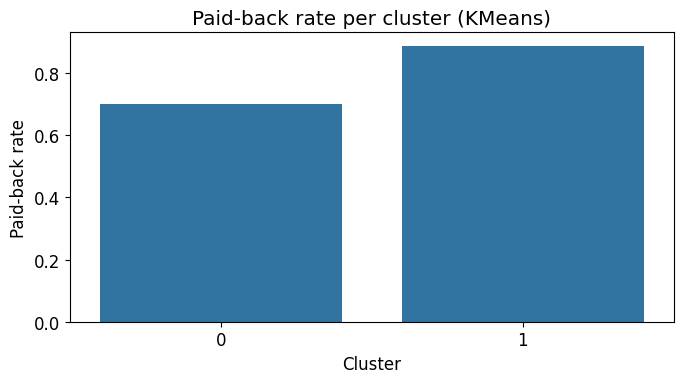

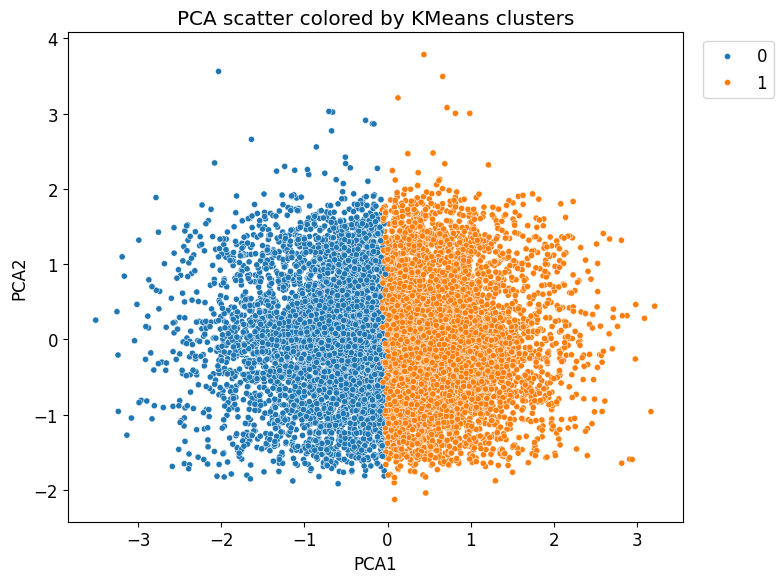

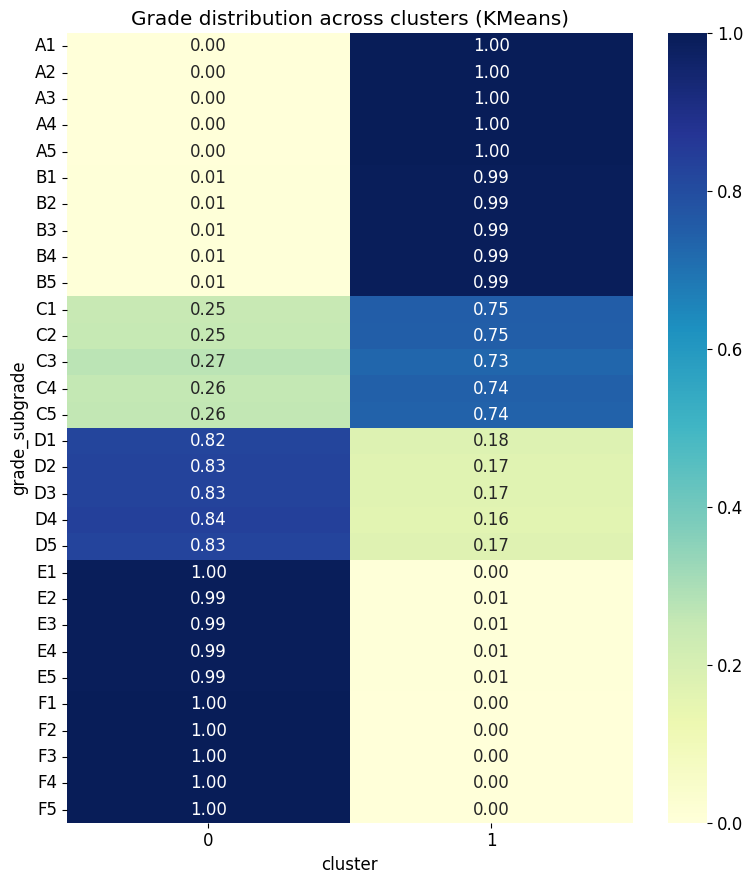

In [26]:
best_k = None
best_sil = -1
k_range = range(2,7)
kmeans_results = []

# Limit silhouette computation to a subset for performance
sample_size = min(10000, x_clust_proc.shape[0])
rng = np.random.default_rng(42)

for k in k_range:
    # Fit KMeans with fixed random state for reproducibility
    km = KMeans(n_clusters = k, random_state = 42, n_init = 10)
    labels_k = km.fit_predict(x_clust_proc)

    # Compute silhouette score on a random subset
    sample_idx = rng.choice(len(x_clust_proc), size = sample_size, replace = False)
    sil = silhouette_score(x_clust_proc[sample_idx], labels_k[sample_idx])
    
    display(Markdown(f"- KMeans **k = {k}**, silhouette = **{sil:.4f}**"))
    
    kmeans_results.append((k, sil))

    # Track the best configuration
    if sil > best_sil:
        best_sil = float(sil)
        best_k = int(k)

# Summary of KMeans results
kmeans_df = pd.DataFrame(kmeans_results, columns = ["k", "silhouette"]) \
             .sort_values("silhouette", ascending = False) \
             .reset_index(drop = True)
kmeans_df["silhouette"] = kmeans_df["silhouette"].round(4)

display(Markdown("**KMeans: silhouette by number of clusters**"))
display(kmeans_df)
display(Markdown(f"**Best KMeans:** k = `{best_k}` (silhouette = `{best_sil:.4f}`)"))

# Final KMeans fit and cluster analysis
kmeans = KMeans(n_clusters = best_k, random_state = 42, n_init = 10)
labels_kmeans = kmeans.fit_predict(x_clust_proc)
res_kmeans = analyze_and_plot(
    labels = labels_kmeans,
    name = "KMeans",
    silhouette_sample_size = 10000,
    scatter_sample_size = 10000)

#### K-Means clustering analysis

- K-means clustering reveals two distinct clusters with different loan repayment behavior. Cluster 1 predominantly contains high-grade loans (A–C) and exhibits a high loan repayment rate of approximately 89%, while cluster 0 predominantly contains lower-grade loans (D–F) with a repayment rate of about 70%.
- Despite a relatively low silhouette score (~0.09), the resulting clusters align closely with existing expert-driven `grade_subgrade` classification. This indicates that, although the feature space does not form well-separated geometric clusters, it still encodes a strong risk-related signal.
- The results suggest that unsupervised clustering can recover a coarse but meaningful separation between low-risk and high-risk borrowers, largely reproducing the structure of the credit grading system without using it explicitly.
- The low silhouette score highlights the absence of strong geometric separation, but does not invalidate the practical relevance of the segmentation for exploratory credit risk analysis.

### Gaussian Mixture Model (GMM) clustering

**GMM components = 2** | silhouette = **0.0596**

**GMM components = 3** | silhouette = **0.0559**

**GMM components = 4** | silhouette = **0.0814**

**GMM components = 5** | silhouette = **0.0615**

**GMM components = 6** | silhouette = **0.0633**

...

,n_components,silhouette
0,4,0.0814
1,6,0.0633
2,5,0.0615
3,2,0.0596
4,3,0.0559


**Best GMM:** n_components = `4` (silhouette = `0.0814`)

**Algorithm: GMM**
- **Number of clusters:** 4
- **Silhouette score (subset):** 0.0835

**Cluster summary (top by paid-back rate):**

,paid_back_rate,n_samples
cluster,,
3,0.8125,293644
1,0.8078,271654
2,0.8055,3660
0,0.5393,25036


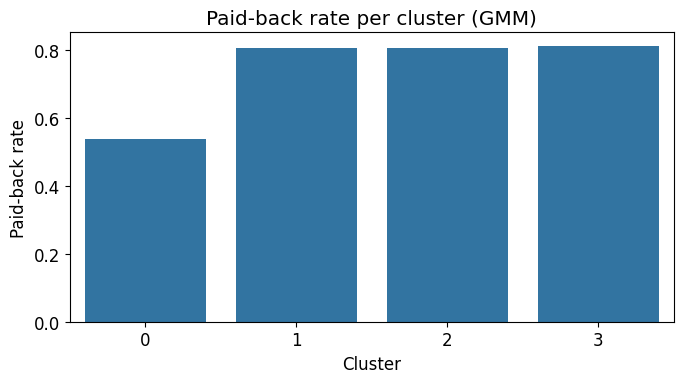

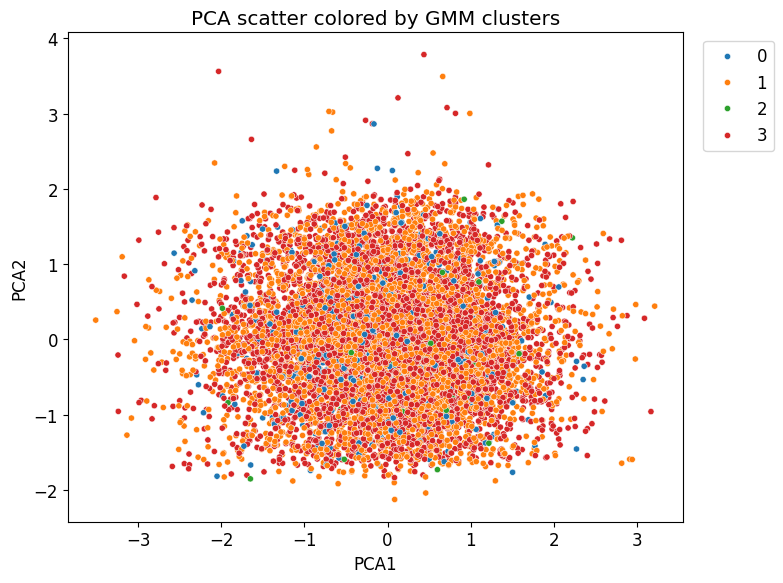

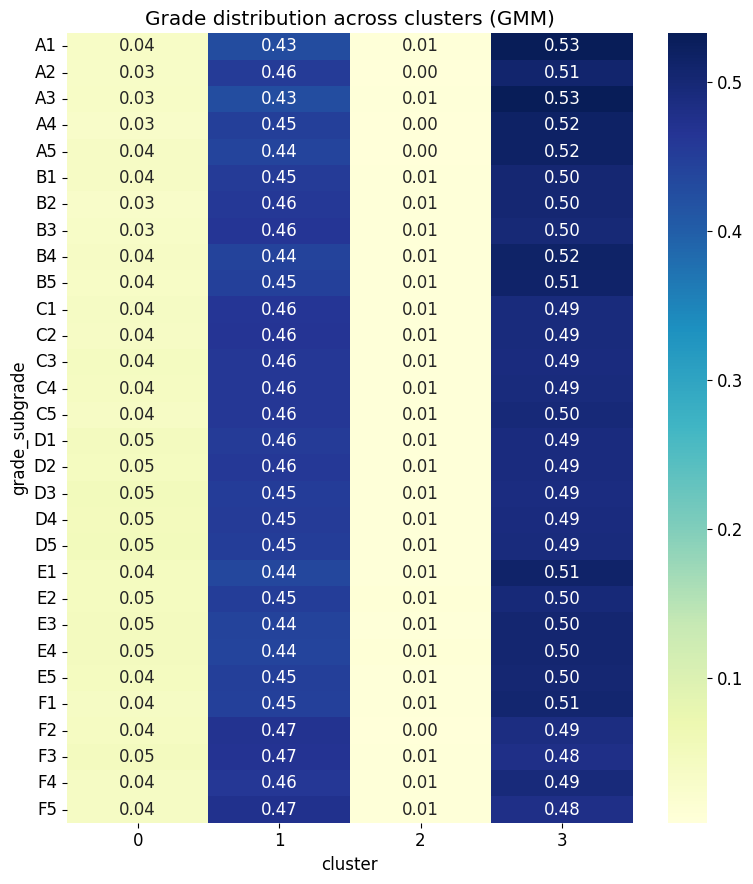

In [27]:
best_g = None
best_sil_g = -1
gmm_results = []

# Limit silhouette computation to a subset for performance
sample_size = min(10000, x_clust_proc.shape[0])
rng = np.random.default_rng(42)

for g in k_range:
    # Fit GMM with fixed random state for reproducibility
    gm = GaussianMixture(n_components = g, random_state = 42)
    labels_g = gm.fit_predict(x_clust_proc)

     # Compute silhouette score on a subset
    sample_idx = rng.choice(len(x_clust_proc), size = sample_size, replace = False)
    sil = silhouette_score(x_clust_proc[sample_idx], labels_g[sample_idx])

    display(Markdown(f"**GMM components = {g}** | silhouette = **{sil:.4f}**"))
    gmm_results.append((g, sil))

    # Track the best configuration
    if sil > best_sil_g:
        best_sil_g = float(sil)
        best_g = int(g)

# Summary of GMM results
gmm_df = (
    pd.DataFrame(gmm_results, columns = ["n_components", "silhouette"])
    .sort_values("silhouette", ascending = False)
    .reset_index(drop = True))
gmm_df["silhouette"] = gmm_df["silhouette"].round(4)

display(Markdown("**GMM: silhouette by number of components**"))
display(gmm_df)

display(Markdown(
    f"**Best GMM:** n_components = `{best_g}` "
    f"(silhouette = `{best_sil_g:.4f}`)"))

# Final GMM fit and cluster analysis
gmm = GaussianMixture(n_components = best_g, random_state = 42)
labels_gmm = gmm.fit_predict(x_clust_proc)

res_gmm = analyze_and_plot(
    labels = labels_gmm,
    name = "GMM",
    silhouette_sample_size = 10000,
    scatter_sample_size = 10000)

#### Gaussian Mixture Model (GMM) clustering analysis

- The Gaussian Mixture Model identifies four clusters with overlapping distributions in feature space and no visually distinct boundaries.
- Three clusters (1, 2, and 3) exhibit consistently high repayment rates (~81%), while cluster 0 stands out with a significantly lower loan repayment rate of 54%.
- Unlike K-means, the GMM clusters do not align with the grade_subgrade system: each cluster contains a broad mix of grades in similar proportions.
- Although the clustering does not correspond to existing credit grades, the GMM uncovers a latent high-risk segment.
- This suggests that probabilistic clustering can reveal subtle risk patterns embedded in the feature distribution, even in the absence of clear geometric separation or alignment with expert-defined categories.

In [28]:
summary_list = [{'algo': res_kmeans['name'],
                 'n_clusters': res_kmeans['n_clusters'],
                 'silhouette': res_kmeans['silhouette']},
                {'algo': res_gmm['name'],
                 'n_clusters': res_gmm['n_clusters'],
                 'silhouette': res_gmm['silhouette']}]

summary = pd.DataFrame(summary_list).sort_values('silhouette', ascending = False)
display(summary)

,algo,n_clusters,silhouette
0,KMeans,2,0.091042
1,GMM,4,0.083481


#### Clustering summary

- Both clustering approaches yield low silhouette scores, indicating weak geometric separation in the feature space.
- However, the clusters remain behaviorally informative:
    - K-means largely reproduces the existing credit grading structure, confirming its consistency with the underlying data.
    - GMM reveals a latent high-risk segment that cuts across traditional credit grades.
- These results demonstrate that, even in the absence of well-separated clusters, unsupervised learning can provide valuable exploratory insights into credit risk structure and complement supervised modeling.
- Overall, clustering is used here as an exploratory tool to assess whether the feature space supports meaningful borrower segmentation beyond the expert-driven credit grade.

<a id="model-training-and-hyperparameter-tuning"></a>
## Model training & hyperparameter tuning

In [29]:
results = {}
final_pipelines = {}
kf = StratifiedKFold (n_splits = 5, shuffle = True, random_state = 42)
kf_fast = StratifiedKFold (n_splits = 3, shuffle = True, random_state = 42)

- To ensure a consistent and reproducible comparison across models, all experiments will be evaluated using stratified `cross-validation` with a fixed random seed, while a separate hold-out split will be reserved for final performance reporting. Model performance will be tracked in a unified `results` dictionary, and the best-performing `pipelines` will be stored for subsequent comparison and downstream analysis.
- Two cross-validation configurations will be employed: a 5-fold StratifiedKFold (`kf`) for primary model selection and reliable performance estimation, and a lighter 3-fold StratifiedKFold (`kf_fast`) for quick exploratory sweeps and computationally expensive model families.

<a id="linear-models"></a>
## Linear models

### Baseline — Logistic Regression (full features, StandardScaler, L2 regularization)

- As a reference point for all subsequent experiments, a `baseline` Logistic Regression model is trained to establish a strong, interpretable benchmark and to quantify the incremental value of alternative preprocessing choices and regularization schemes.

In [31]:
pipeline_baseline = Pipeline([
    ('preprocessor', preprocessor_baseline),
    ('classifier', LogisticRegression(
        random_state = 42,
        max_iter = 5000,
        class_weight = 'balanced',
        solver = 'lbfgs',
        penalty = 'l2',
        C = 1.0))])

pipeline_baseline.fit(x_train_train, y_train)

model_name = 'Logistic Regression Baseline'
results[model_name] = evaluate_classification_model(
    pipeline_baseline,
    x_train_test,
    y_test,
    model_name)

final_pipelines[model_name] = pipeline_baseline

**Model evaluation: Logistic Regression Baseline**

,Metric,Value
0,ROC-AUC,0.9107
1,Accuracy,0.8614
2,F1,0.9107
3,Precision,0.9383
4,Recall,0.8847


,Predicted 0,Predicted 1
Actual 0,18381,5519
Actual 1,10944,83955


**Baseline analysis**
- The baseline Logistic Regression model demonstrates strong overall performance, achieving a ROC-AUC of 0.91 with a balanced trade-off between high precision and recall, and therefore serves as a solid reference point for subsequent model comparisons.

**Regularization strength and search ranges**

- After establishing the `baseline`, a systematic set of Logistic Regression variants will be evaluated to disentangle the effect of key design choices in the preprocessing and modeling pipeline. Specifically, the forthcoming experiments will compare:
    - feature set definition (full vs. selected features),
    - feature scaling (StandardScaler vs. RobustScaler),
    - regularization type (L1, L2, Elastic Net), and
    - outlier treatment via winsorization.
- This controlled experimental setup will make it possible to identify which components materially affect generalization performance and which ones are largely redundant for this dataset.

- In Logistic Regression, the hyperparameter `C` controls the inverse strength of regularization. Its effective impact is expected to depend on several factors:
    - the type of regularization (L1, L2, Elastic Net),
    - feature scaling and preprocessing choices (e.g. StandardScaler vs. RobustScaler, log-transformation, outlier treatment),
    - and class reweighting via `class_weight = 'balanced'`.
- Different regularization penalties impose qualitatively different constraints on model coefficients:
    - L2 regularization shrinks all coefficients smoothly,
    - L1 promotes sparsity by driving some coefficients to zero, and
    - Elastic Net combines both behaviors.
- As a result, the same numerical value of `C` does not correspond to the same effective regularization strength across penalty types.
- For this reason, separate and partially overlapping C ranges will be explored for different regularization schemes and preprocessing configurations. The search ranges are informed by an initial coarse exploration and are subsequently narrowed to focus on promising regions, allowing efficient hyperparameter tuning without unnecessary computational overhead.

### Logistic Regression (full features, log transform, StandardScaler, L1 regularization)

In [32]:
pipeline_log_reg_l1_full_ss = Pipeline([
    ('preprocessor', preprocessor_full_ss),
    ('classifier', LogisticRegression(random_state = 42, max_iter = 5000, class_weight = 'balanced', penalty = 'l1'))])

param_grid_log_reg_l1_full_ss = {
    'classifier__C': [0.01, 0.05, 0.1],
    'classifier__solver': ['liblinear', 'saga']}

grid_search_log_reg_l1_full_ss = GridSearchCV(
    pipeline_log_reg_l1_full_ss, 
    param_grid_log_reg_l1_full_ss, 
    scoring = 'roc_auc',
    cv = kf,
    verbose = 1,
    n_jobs = -1)

grid_search_log_reg_l1_full_ss.fit(x_train_train, y_train)

best_log_reg_l1_full_ss = grid_search_log_reg_l1_full_ss.best_estimator_
best_params_log_reg_l1_full_ss = grid_search_log_reg_l1_full_ss.best_params_
best_score_cv_log_reg_l1_full_ss = grid_search_log_reg_l1_full_ss.best_score_

model_name = 'Logistic Regression L1 (Full, SS)'
results[model_name] = evaluate_classification_model(
    best_log_reg_l1_full_ss, 
    x_train_test, 
    y_test, 
    model_name)

final_pipelines[model_name] = best_log_reg_l1_full_ss

display(f"\nOptimal hyperparameters for {model_name}: {best_params_log_reg_l1_full_ss}")
display(f"Best ROC-AUC (CV): {best_score_cv_log_reg_l1_full_ss:.4f}")

Fitting 5 folds for each of 6 candidates, totalling 30 fits


**Model evaluation: Logistic Regression L1 (Full, SS)**

,Metric,Value
0,ROC-AUC,0.9108
1,Accuracy,0.8599
2,F1,0.9096
3,Precision,0.9387
4,Recall,0.8822


,Predicted 0,Predicted 1
Actual 0,18431,5469
Actual 1,11179,83720


"\nOptimal hyperparameters for Logistic Regression L1 (Full, SS): {'classifier__C': 0.05, 'classifier__solver': 'liblinear'}"

'Best ROC-AUC (CV): 0.9111'

### Logistic Regression (full features, log transform, RobustScaler, L1 regularization)

In [33]:
pipeline_log_reg_l1_full_rs = Pipeline([
    ('preprocessor', preprocessor_full_rs),
    ('classifier', LogisticRegression(random_state = 42, max_iter = 5000, class_weight = 'balanced', penalty = 'l1'))])

param_grid_log_reg_l1_full_rs = {
    'classifier__C': [0.01, 0.05, 0.1],
    'classifier__solver': ['liblinear', 'saga']}

grid_search_log_reg_l1_full_rs = GridSearchCV(
    pipeline_log_reg_l1_full_rs, 
    param_grid_log_reg_l1_full_rs, 
    scoring = 'roc_auc',
    cv = kf,
    verbose = 1,
    n_jobs = -1)

grid_search_log_reg_l1_full_rs.fit(x_train_train, y_train)

best_log_reg_l1_full_rs = grid_search_log_reg_l1_full_rs.best_estimator_
best_params_log_reg_l1_full_rs = grid_search_log_reg_l1_full_rs.best_params_
best_score_cv_log_reg_l1_full_rs = grid_search_log_reg_l1_full_rs.best_score_

model_name = 'Logistic Regression L1 (Full, RS)'
results[model_name] = evaluate_classification_model(
    best_log_reg_l1_full_rs, 
    x_train_test, 
    y_test, 
    model_name)

final_pipelines[model_name] = best_log_reg_l1_full_rs

display(f"\nOptimal hyperparameters for {model_name}: {best_params_log_reg_l1_full_rs}")
display(f"Best ROC-AUC (CV): {best_score_cv_log_reg_l1_full_rs:.4f}")

Fitting 5 folds for each of 6 candidates, totalling 30 fits


**Model evaluation: Logistic Regression L1 (Full, RS)**

,Metric,Value
0,ROC-AUC,0.9108
1,Accuracy,0.8599
2,F1,0.9096
3,Precision,0.9387
4,Recall,0.8822


,Predicted 0,Predicted 1
Actual 0,18433,5467
Actual 1,11182,83717


"\nOptimal hyperparameters for Logistic Regression L1 (Full, RS): {'classifier__C': 0.05, 'classifier__solver': 'liblinear'}"

'Best ROC-AUC (CV): 0.9111'

### Logistic Regression (full features, log transform, RobustScaler, L1 regularization, outlier treatment)

In [34]:
pipeline_log_reg_l1_full_rs_winsor = Pipeline([
    ('preprocessor', preprocessor_full_rs_winsor),
    ('classifier', LogisticRegression(random_state = 42, max_iter = 5000, class_weight = 'balanced', penalty = 'l1', solver = 'liblinear'))])

param_grid_log_reg_l1_full_rs_winsor = {
    'classifier__C': [0.01, 0.05, 0.1]}

grid_search_log_reg_l1_full_rs_winsor = GridSearchCV(
    pipeline_log_reg_l1_full_rs_winsor, 
    param_grid_log_reg_l1_full_rs_winsor, 
    scoring = 'roc_auc',
    cv = kf,
    verbose = 1,
    n_jobs = -1)

grid_search_log_reg_l1_full_rs_winsor.fit(x_train_train, y_train)

best_log_reg_l1_full_rs_winsor = grid_search_log_reg_l1_full_rs_winsor.best_estimator_
best_params_log_reg_l1_full_rs_winsor = grid_search_log_reg_l1_full_rs_winsor.best_params_
best_score_cv_log_reg_l1_full_rs_winsor = grid_search_log_reg_l1_full_rs_winsor.best_score_

model_name = 'Logistic Regression L1 (Full, RS, Winsor)'
results[model_name] = evaluate_classification_model(
    best_log_reg_l1_full_rs_winsor, 
    x_train_test, 
    y_test, 
    model_name)

final_pipelines[model_name] = best_log_reg_l1_full_rs_winsor

display(f"\nOptimal hyperparameters for {model_name}: {best_params_log_reg_l1_full_rs_winsor}")
display(f"Best ROC-AUC (CV): {best_score_cv_log_reg_l1_full_rs_winsor:.4f}")

Fitting 5 folds for each of 3 candidates, totalling 15 fits


**Model evaluation: Logistic Regression L1 (Full, RS, Winsor)**

,Metric,Value
0,ROC-AUC,0.9109
1,Accuracy,0.8594
2,F1,0.9092
3,Precision,0.9389
4,Recall,0.8813


,Predicted 0,Predicted 1
Actual 0,18460,5440
Actual 1,11266,83633


"\nOptimal hyperparameters for Logistic Regression L1 (Full, RS, Winsor): {'classifier__C': 0.05}"

'Best ROC-AUC (CV): 0.9112'

### Logistic Regression (full features, log transform, StandardScaler, L2 regularization)

In [35]:
pipeline_log_reg_l2_full_ss = Pipeline([
    ('preprocessor', preprocessor_full_ss),
    ('classifier', LogisticRegression(random_state = 42, max_iter = 5000, class_weight = 'balanced', penalty = 'l2'))])

param_grid_log_reg_l2_full_ss = {
    'classifier__C': [0.1, 0.5, 1.0],
    'classifier__solver': ['lbfgs', 'liblinear', 'saga']}

grid_search_log_reg_l2_full_ss = GridSearchCV(
    pipeline_log_reg_l2_full_ss, 
    param_grid_log_reg_l2_full_ss, 
    scoring = 'roc_auc',
    cv = kf,
    verbose = 1,
    n_jobs = -1)

grid_search_log_reg_l2_full_ss.fit(x_train_train, y_train)

best_log_reg_l2_full_ss = grid_search_log_reg_l2_full_ss.best_estimator_
best_params_log_reg_l2_full_ss = grid_search_log_reg_l2_full_ss.best_params_
best_score_cv_log_reg_l2_full_ss = grid_search_log_reg_l2_full_ss.best_score_

model_name = 'Logistic Regression L2 (Full, SS)'
results[model_name] = evaluate_classification_model(
    best_log_reg_l2_full_ss, 
    x_train_test, 
    y_test, 
    model_name)

final_pipelines[model_name] = best_log_reg_l2_full_ss

display(f"\nOptimal hyperparameters for {model_name}: {best_params_log_reg_l2_full_ss}")
display(f"Best ROC-AUC (CV): {best_score_cv_log_reg_l2_full_ss:.4f}")

Fitting 5 folds for each of 9 candidates, totalling 45 fits


**Model evaluation: Logistic Regression L2 (Full, SS)**

,Metric,Value
0,ROC-AUC,0.9107
1,Accuracy,0.8599
2,F1,0.9096
3,Precision,0.9387
4,Recall,0.8822


,Predicted 0,Predicted 1
Actual 0,18434,5466
Actual 1,11178,83721


"\nOptimal hyperparameters for Logistic Regression L2 (Full, SS): {'classifier__C': 0.5, 'classifier__solver': 'saga'}"

'Best ROC-AUC (CV): 0.9110'

### Logistic Regression (full features, log transform, RobustScaler, L2 regularization)

In [36]:
pipeline_log_reg_l2_full_rs = Pipeline([
    ('preprocessor', preprocessor_full_rs),
    ('classifier', LogisticRegression(random_state = 42, max_iter = 5000, class_weight = 'balanced', penalty = 'l2'))])

param_grid_log_reg_l2_full_rs = {
    'classifier__C': [1.0, 1.5, 2.0],
    'classifier__solver': ['lbfgs', 'liblinear', 'saga']}

grid_search_log_reg_l2_full_rs = GridSearchCV(
    pipeline_log_reg_l2_full_rs, 
    param_grid_log_reg_l2_full_rs, 
    scoring = 'roc_auc',
    cv = kf,
    verbose = 1,
    n_jobs = -1)

grid_search_log_reg_l2_full_rs.fit(x_train_train, y_train)

best_log_reg_l2_full_rs = grid_search_log_reg_l2_full_rs.best_estimator_
best_params_log_reg_l2_full_rs = grid_search_log_reg_l2_full_rs.best_params_
best_score_cv_log_reg_l2_full_rs = grid_search_log_reg_l2_full_rs.best_score_

model_name = 'Logistic Regression L2 (Full, RS)'
results[model_name] = evaluate_classification_model(
    best_log_reg_l2_full_rs, 
    x_train_test, 
    y_test, 
    model_name)

final_pipelines[model_name] = best_log_reg_l2_full_rs

display(f"\nOptimal hyperparameters for {model_name}: {best_params_log_reg_l2_full_rs}")
display(f"Best ROC-AUC (CV): {best_score_cv_log_reg_l2_full_rs:.4f}")

Fitting 5 folds for each of 9 candidates, totalling 45 fits


**Model evaluation: Logistic Regression L2 (Full, RS)**

,Metric,Value
0,ROC-AUC,0.9107
1,Accuracy,0.8600
2,F1,0.9097
3,Precision,0.9387
4,Recall,0.8824


,Predicted 0,Predicted 1
Actual 0,18434,5466
Actual 1,11162,83737


"\nOptimal hyperparameters for Logistic Regression L2 (Full, RS): {'classifier__C': 1.5, 'classifier__solver': 'lbfgs'}"

'Best ROC-AUC (CV): 0.9110'

### Logistic Regression (full features, log transform, RobustScaler, L2 regularization, outlier treatment)

In [37]:
pipeline_log_reg_l2_full_rs_winsor = Pipeline([
    ('preprocessor', preprocessor_full_rs_winsor),
    ('classifier', LogisticRegression(
        random_state = 42, max_iter = 5000, class_weight = 'balanced', penalty = 'l2'))])

param_grid_log_reg_l2_full_rs_winsor = {
    'classifier__C': [0.5, 1.0, 1.5, 2.0],
    'classifier__solver': ['lbfgs', 'saga']}

grid_search_log_reg_l2_full_rs_winsor = GridSearchCV(
    pipeline_log_reg_l2_full_rs_winsor,
    param_grid = param_grid_log_reg_l2_full_rs_winsor,
    scoring = 'roc_auc',
    cv = kf,
    verbose = 1,
    n_jobs = -1)

grid_search_log_reg_l2_full_rs_winsor.fit(x_train_train, y_train)

best_log_reg_l2_full_rs_winsor = grid_search_log_reg_l2_full_rs_winsor.best_estimator_
best_params_log_reg_l2_full_rs_winsor = grid_search_log_reg_l2_full_rs_winsor.best_params_
best_score_cv_log_reg_l2_full_rs_winsor = grid_search_log_reg_l2_full_rs_winsor.best_score_

model_name = 'Logistic Regression L2 (Full, RS, Winsor)'
results[model_name] = evaluate_classification_model(
    best_log_reg_l2_full_rs_winsor,
    x_train_test,
    y_test,
    model_name)

final_pipelines[model_name] = best_log_reg_l2_full_rs_winsor

display(f"\nOptimal hyperparameters for {model_name}: {best_params_log_reg_l2_full_rs_winsor}")
display(f"Best ROC-AUC (CV): {best_score_cv_log_reg_l2_full_rs_winsor:.4f}")

Fitting 5 folds for each of 8 candidates, totalling 40 fits


**Model evaluation: Logistic Regression L2 (Full, RS, Winsor)**

,Metric,Value
0,ROC-AUC,0.9108
1,Accuracy,0.8592
2,F1,0.9091
3,Precision,0.9388
4,Recall,0.8812


,Predicted 0,Predicted 1
Actual 0,18451,5449
Actual 1,11272,83627


"\nOptimal hyperparameters for Logistic Regression L2 (Full, RS, Winsor): {'classifier__C': 0.5, 'classifier__solver': 'saga'}"

'Best ROC-AUC (CV): 0.9112'

### Logistic Regression (full features, log transform, StandardScaler, Elastic Net regularization)

In [38]:
pipeline_log_reg_elastic_full_ss = Pipeline([
    ('preprocessor', preprocessor_full_ss),
    ('classifier', LogisticRegression(random_state = 42, max_iter = 5000, class_weight = 'balanced', penalty = 'elasticnet', solver = 'saga'))])

param_grid_log_reg_elastic_full_ss = {
    'classifier__C': [0.01, 0.05, 0.1, 0.5],
    'classifier__l1_ratio': [0.5, 0.7, 0.9]}

grid_search_log_reg_elastic_full_ss = GridSearchCV(
    pipeline_log_reg_elastic_full_ss, 
    param_grid_log_reg_elastic_full_ss, 
    scoring = 'roc_auc',
    cv = kf,
    verbose = 1,
    n_jobs = -1)

grid_search_log_reg_elastic_full_ss.fit(x_train_train, y_train)

best_log_reg_elastic_full_ss = grid_search_log_reg_elastic_full_ss.best_estimator_
best_params_log_reg_elastic_full_ss = grid_search_log_reg_elastic_full_ss.best_params_
best_score_cv_elastic_full_ss = grid_search_log_reg_elastic_full_ss.best_score_

model_name = 'Logistic Regression ElasticNet (Full, SS)'
results[model_name] = evaluate_classification_model(
    best_log_reg_elastic_full_ss, 
    x_train_test, 
    y_test, 
    model_name)

final_pipelines[model_name] = best_log_reg_elastic_full_ss

display(f"\nOptimal hyperparameters for {model_name}: {best_params_log_reg_elastic_full_ss}")
display(f"Best ROC-AUC (CV): {best_score_cv_elastic_full_ss:.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits


**Model evaluation: Logistic Regression ElasticNet (Full, SS)**

,Metric,Value
0,ROC-AUC,0.9108
1,Accuracy,0.8599
2,F1,0.9096
3,Precision,0.9387
4,Recall,0.8823


,Predicted 0,Predicted 1
Actual 0,18428,5472
Actual 1,11173,83726


"\nOptimal hyperparameters for Logistic Regression ElasticNet (Full, SS): {'classifier__C': 0.05, 'classifier__l1_ratio': 0.9}"

'Best ROC-AUC (CV): 0.9111'

### Logistic Regression (full features, log transform, RobustScaler, Elastic Net regularization)

In [39]:
pipeline_log_reg_elastic_full_rs = Pipeline([
    ('preprocessor', preprocessor_full_rs),
    ('classifier', LogisticRegression(random_state = 42, max_iter = 5000, class_weight = 'balanced', penalty = 'elasticnet', solver = 'saga'))])

param_grid_log_reg_elastic_full_rs = {
    'classifier__C': [0.01, 0.05, 0.1, 0.5],
    'classifier__l1_ratio': [0.5, 0.7, 0.9]}

grid_search_log_reg_elastic_full_rs = GridSearchCV(
    pipeline_log_reg_elastic_full_rs, 
    param_grid_log_reg_elastic_full_rs, 
    scoring = 'roc_auc',
    cv = kf,
    verbose = 1,
    n_jobs = -1)

grid_search_log_reg_elastic_full_rs.fit(x_train_train, y_train)

best_log_reg_elastic_full_rs = grid_search_log_reg_elastic_full_rs.best_estimator_
best_params_log_reg_elastic_full_rs = grid_search_log_reg_elastic_full_rs.best_params_
best_score_cv_elastic_full_rs = grid_search_log_reg_elastic_full_rs.best_score_

model_name = 'Logistic Regression ElasticNet (Full, RS)'
results[model_name] = evaluate_classification_model(
    best_log_reg_elastic_full_rs, 
    x_train_test, 
    y_test, 
    model_name)

final_pipelines[model_name] = best_log_reg_elastic_full_rs

display(f"\nOptimal hyperparameters for {model_name}: {best_params_log_reg_elastic_full_rs}")
display(f"Best ROC-AUC (CV): {best_score_cv_elastic_full_rs:.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits


**Model evaluation: Logistic Regression ElasticNet (Full, RS)**

,Metric,Value
0,ROC-AUC,0.9108
1,Accuracy,0.8599
2,F1,0.9096
3,Precision,0.9387
4,Recall,0.8823


,Predicted 0,Predicted 1
Actual 0,18429,5471
Actual 1,11172,83727


"\nOptimal hyperparameters for Logistic Regression ElasticNet (Full, RS): {'classifier__C': 0.05, 'classifier__l1_ratio': 0.9}"

'Best ROC-AUC (CV): 0.9111'

### Logistic Regression (full features, log transform, RobustScaler, Elastic Net regularization, outlier treatment)

In [40]:
pipeline_log_reg_elastic_full_rs_winsor = Pipeline([
    ('preprocessor', preprocessor_full_rs_winsor),
    ('classifier', LogisticRegression(
        random_state = 42, max_iter = 5000, class_weight = 'balanced', penalty = 'elasticnet', solver = 'saga'))])

param_grid_log_reg_elastic_full_rs_winsor = {
    'classifier__C': [0.01, 0.05, 0.1],
    'classifier__l1_ratio': [0.7, 0.9]}

grid_search_log_reg_elastic_full_rs_winsor = GridSearchCV(
    pipeline_log_reg_elastic_full_rs_winsor,
    param_grid = param_grid_log_reg_elastic_full_rs_winsor,
    scoring = 'roc_auc',
    cv = kf,
    verbose = 1,
    n_jobs = -1)

grid_search_log_reg_elastic_full_rs_winsor.fit(x_train_train, y_train)

best_log_reg_elastic_full_rs_winsor = grid_search_log_reg_elastic_full_rs_winsor.best_estimator_
best_params_log_reg_elastic_full_rs_winsor = grid_search_log_reg_elastic_full_rs_winsor.best_params_
best_score_cv_elastic_full_rs_winsor = grid_search_log_reg_elastic_full_rs_winsor.best_score_

model_name = 'Logistic Regression ElasticNet (Full, RS, Winsor)'
results[model_name] = evaluate_classification_model(
    best_log_reg_elastic_full_rs_winsor,
    x_train_test,
    y_test,
    model_name)

final_pipelines[model_name] = best_log_reg_elastic_full_rs_winsor

display(f"\nOptimal hyperparameters for {model_name}: {best_params_log_reg_elastic_full_rs_winsor}")
display(f"Best ROC-AUC (CV): {best_score_cv_elastic_full_rs_winsor:.4f}")

Fitting 5 folds for each of 6 candidates, totalling 30 fits


**Model evaluation: Logistic Regression ElasticNet (Full, RS, Winsor)**

,Metric,Value
0,ROC-AUC,0.9109
1,Accuracy,0.8594
2,F1,0.9092
3,Precision,0.9389
4,Recall,0.8813


,Predicted 0,Predicted 1
Actual 0,18456,5444
Actual 1,11262,83637


"\nOptimal hyperparameters for Logistic Regression ElasticNet (Full, RS, Winsor): {'classifier__C': 0.05, 'classifier__l1_ratio': 0.9}"

'Best ROC-AUC (CV): 0.9112'

### Logistic Regression (selected features, log transform, StandardScaler, L1 regularization)

In [41]:
pipeline_log_reg_l1_selected_ss = Pipeline([
    ('preprocessor', preprocessor_selected_ss),
    ('classifier', LogisticRegression(random_state = 42, max_iter = 5000, class_weight = 'balanced', penalty = 'l1'))])

param_grid_log_reg_l1_selected_ss = {
    'classifier__C': [0.01, 0.05, 0.1],
    'classifier__solver': ['liblinear', 'saga']}

grid_search_log_reg_l1_selected_ss = GridSearchCV(
    pipeline_log_reg_l1_selected_ss, 
    param_grid_log_reg_l1_selected_ss, 
    scoring = 'roc_auc',
    cv = kf,
    verbose = 1,
    n_jobs = -1)

grid_search_log_reg_l1_selected_ss.fit(x_train_train, y_train)

best_log_reg_l1_selected_ss = grid_search_log_reg_l1_selected_ss.best_estimator_
best_params_log_reg_l1_selected_ss = grid_search_log_reg_l1_selected_ss.best_params_
best_score_cv_log_reg_l1_selected_ss = grid_search_log_reg_l1_selected_ss.best_score_

model_name = 'Logistic Regression L1 (Selected, SS)'
results[model_name] = evaluate_classification_model(
    best_log_reg_l1_selected_ss, 
    x_train_test, 
    y_test, 
    model_name)

final_pipelines[model_name] = best_log_reg_l1_selected_ss

display(f"\nOptimal hyperparameters for {model_name}: {best_params_log_reg_l1_selected_ss}")
display(f"Best ROC-AUC (CV): {best_score_cv_log_reg_l1_selected_ss:.4f}")

Fitting 5 folds for each of 6 candidates, totalling 30 fits


**Model evaluation: Logistic Regression L1 (Selected, SS)**

,Metric,Value
0,ROC-AUC,0.9107
1,Accuracy,0.8599
2,F1,0.9096
3,Precision,0.9386
4,Recall,0.8823


,Predicted 0,Predicted 1
Actual 0,18427,5473
Actual 1,11165,83734


"\nOptimal hyperparameters for Logistic Regression L1 (Selected, SS): {'classifier__C': 0.05, 'classifier__solver': 'liblinear'}"

'Best ROC-AUC (CV): 0.9110'

### Logistic Regression (selected features, log transform, RobustScaler, L1 regularization)

In [42]:
pipeline_log_reg_l1_selected_rs = Pipeline([
    ('preprocessor', preprocessor_selected_rs),
    ('classifier', LogisticRegression(random_state = 42, max_iter = 5000, class_weight = 'balanced', penalty = 'l1'))])

param_grid_log_reg_l1_selected_rs = {
    'classifier__C': [0.01, 0.05, 0.1],
    'classifier__solver': ['liblinear', 'saga']}

grid_search_log_reg_l1_selected_rs = GridSearchCV(
    pipeline_log_reg_l1_selected_rs, 
    param_grid_log_reg_l1_selected_rs, 
    scoring = 'roc_auc',
    cv = kf,
    verbose = 1,
    n_jobs = -1)

grid_search_log_reg_l1_selected_rs.fit(x_train_train, y_train)

best_log_reg_l1_selected_rs = grid_search_log_reg_l1_selected_rs.best_estimator_
best_params_log_reg_l1_selected_rs = grid_search_log_reg_l1_selected_rs.best_params_
best_score_cv_log_reg_l1_selected_rs = grid_search_log_reg_l1_selected_rs.best_score_

model_name = 'Logistic Regression L1 (Selected, RS)'
results[model_name] = evaluate_classification_model(
    best_log_reg_l1_selected_rs, 
    x_train_test, 
    y_test, 
    model_name)

final_pipelines[model_name] = best_log_reg_l1_selected_rs

display(f"\nOptimal hyperparameters for {model_name}: {best_params_log_reg_l1_selected_rs}")
display(f"Best ROC-AUC (CV): {best_score_cv_log_reg_l1_selected_rs:.4f}")

Fitting 5 folds for each of 6 candidates, totalling 30 fits


**Model evaluation: Logistic Regression L1 (Selected, RS)**

,Metric,Value
0,ROC-AUC,0.9107
1,Accuracy,0.8599
2,F1,0.9096
3,Precision,0.9386
4,Recall,0.8823


,Predicted 0,Predicted 1
Actual 0,18427,5473
Actual 1,11165,83734


"\nOptimal hyperparameters for Logistic Regression L1 (Selected, RS): {'classifier__C': 0.05, 'classifier__solver': 'liblinear'}"

'Best ROC-AUC (CV): 0.9110'

### Logistic Regression (selected features, log transform, RobustScaler, L1 regularization, outlier treatment)

In [43]:
pipeline_log_reg_l1_selected_rs_winsor = Pipeline([
    ('preprocessor', preprocessor_selected_rs_winsor),
    ('classifier', LogisticRegression(
        random_state = 42, max_iter = 5000, class_weight = 'balanced', penalty = 'l1', solver = 'liblinear'))])

param_grid_log_reg_l1_selected_rs_winsor = {
    'classifier__C': [0.01, 0.05, 0.1]}

grid_search_log_reg_l1_selected_rs_winsor = GridSearchCV(
    pipeline_log_reg_l1_selected_rs_winsor,
    param_grid = param_grid_log_reg_l1_selected_rs_winsor,
    scoring = 'roc_auc',
    cv = kf,
    verbose = 1,
    n_jobs = -1)

grid_search_log_reg_l1_selected_rs_winsor.fit(x_train_train, y_train)

best_log_reg_l1_selected_rs_winsor = grid_search_log_reg_l1_selected_rs_winsor.best_estimator_
best_params_log_reg_l1_selected_rs_winsor = grid_search_log_reg_l1_selected_rs_winsor.best_params_
best_score_cv_log_reg_l1_selected_rs_winsor = grid_search_log_reg_l1_selected_rs_winsor.best_score_

model_name = 'Logistic Regression L1 (Selected, RS, Winsor)'
results[model_name] = evaluate_classification_model(
    best_log_reg_l1_selected_rs_winsor,
    x_train_test,
    y_test,
    model_name)

final_pipelines[model_name] = best_log_reg_l1_selected_rs_winsor

display(f"\nOptimal hyperparameters for {model_name}: {best_params_log_reg_l1_selected_rs_winsor}")
display(f"Best ROC-AUC (CV): {best_score_cv_log_reg_l1_selected_rs_winsor:.4f}")

Fitting 5 folds for each of 3 candidates, totalling 15 fits


**Model evaluation: Logistic Regression L1 (Selected, RS, Winsor)**

,Metric,Value
0,ROC-AUC,0.9108
1,Accuracy,0.8592
2,F1,0.9091
3,Precision,0.9390
4,Recall,0.8810


,Predicted 0,Predicted 1
Actual 0,18465,5435
Actual 1,11290,83609


"\nOptimal hyperparameters for Logistic Regression L1 (Selected, RS, Winsor): {'classifier__C': 0.05}"

'Best ROC-AUC (CV): 0.9112'

### Logistic Regression (selected features, log transform, StandardScaler, L2 regularization)

In [44]:
pipeline_log_reg_l2_selected_ss = Pipeline([
    ('preprocessor', preprocessor_selected_ss),
    ('classifier', LogisticRegression(random_state = 42, max_iter = 5000, class_weight = 'balanced', penalty = 'l2'))])

param_grid_log_reg_l2_selected_ss = {
    'classifier__C': [0.1, 0.5, 1.0],
    'classifier__solver': ['lbfgs', 'liblinear', 'saga']}

grid_search_log_reg_l2_selected_ss = GridSearchCV(
    pipeline_log_reg_l2_selected_ss, 
    param_grid_log_reg_l2_selected_ss, 
    scoring = 'roc_auc',
    cv = kf,
    verbose = 1,
    n_jobs = -1)

grid_search_log_reg_l2_selected_ss.fit(x_train_train, y_train)

best_log_reg_l2_selected_ss = grid_search_log_reg_l2_selected_ss.best_estimator_
best_params_log_reg_l2_selected_ss = grid_search_log_reg_l2_selected_ss.best_params_
best_score_cv_log_reg_l2_selected_ss = grid_search_log_reg_l2_selected_ss.best_score_

model_name = 'Logistic Regression L2 (Selected, SS)'
results[model_name] = evaluate_classification_model(
    best_log_reg_l2_selected_ss, 
    x_train_test, 
    y_test, 
    model_name)

final_pipelines[model_name] = best_log_reg_l2_selected_ss

display(f"\nOptimal hyperparameters for {model_name}: {best_params_log_reg_l2_selected_ss}")
display(f"Best ROC-AUC (CV): {best_score_cv_log_reg_l2_selected_ss:.4f}")

Fitting 5 folds for each of 9 candidates, totalling 45 fits


**Model evaluation: Logistic Regression L2 (Selected, SS)**

,Metric,Value
0,ROC-AUC,0.9107
1,Accuracy,0.8601
2,F1,0.9097
3,Precision,0.9388
4,Recall,0.8823


,Predicted 0,Predicted 1
Actual 0,18440,5460
Actual 1,11165,83734


"\nOptimal hyperparameters for Logistic Regression L2 (Selected, SS): {'classifier__C': 0.5, 'classifier__solver': 'saga'}"

'Best ROC-AUC (CV): 0.9110'

### Logistic Regression (selected features, log transform, RobustScaler, L2 regularization)

In [45]:
pipeline_log_reg_l2_selected_rs = Pipeline([
    ('preprocessor', preprocessor_selected_rs),
    ('classifier', LogisticRegression(random_state = 42, max_iter = 5000, class_weight = 'balanced', penalty = 'l2'))])

param_grid_log_reg_l2_selected_rs = {
    'classifier__C': [0.1, 0.5, 1.0],
    'classifier__solver': ['lbfgs', 'liblinear', 'saga']}

grid_search_log_reg_l2_selected_rs = GridSearchCV(
    pipeline_log_reg_l2_selected_rs, 
    param_grid_log_reg_l2_selected_rs, 
    scoring = 'roc_auc',
    cv = kf,
    verbose = 1,
    n_jobs = -1)

grid_search_log_reg_l2_selected_rs.fit(x_train_train, y_train)

best_log_reg_l2_selected_rs = grid_search_log_reg_l2_selected_rs.best_estimator_
best_params_log_reg_l2_selected_rs = grid_search_log_reg_l2_selected_rs.best_params_
best_score_cv_log_reg_l2_selected_rs = grid_search_log_reg_l2_selected_rs.best_score_

model_name = 'Logistic Regression L2 (Selected, RS)'
results[model_name] = evaluate_classification_model(
    best_log_reg_l2_selected_rs, 
    x_train_test, 
    y_test, 
    model_name)

final_pipelines[model_name] = best_log_reg_l2_selected_rs

display(f"\nOptimal hyperparameters for {model_name}: {best_params_log_reg_l2_selected_rs}")
display(f"Best ROC-AUC (CV): {best_score_cv_log_reg_l2_selected_rs:.4f}")

Fitting 5 folds for each of 9 candidates, totalling 45 fits


**Model evaluation: Logistic Regression L2 (Selected, RS)**

,Metric,Value
0,ROC-AUC,0.9107
1,Accuracy,0.8600
2,F1,0.9097
3,Precision,0.9388
4,Recall,0.8823


,Predicted 0,Predicted 1
Actual 0,18440,5460
Actual 1,11166,83733


"\nOptimal hyperparameters for Logistic Regression L2 (Selected, RS): {'classifier__C': 0.5, 'classifier__solver': 'saga'}"

'Best ROC-AUC (CV): 0.9110'

### Logistic Regression (selected features, log transform, RobustScaler, L2 regularization, outlier treatment)

In [46]:
pipeline_log_reg_l2_selected_rs_winsor = Pipeline([
    ('preprocessor', preprocessor_selected_rs_winsor),
    ('classifier', LogisticRegression(random_state = 42, max_iter = 5000, class_weight = 'balanced', penalty = 'l2', solver = 'saga'))])

param_grid_log_reg_l2_selected_rs_winsor = {
    'classifier__C': [0.1, 0.5, 1.0]}

grid_search_log_reg_l2_selected_rs_winsor = GridSearchCV(
    pipeline_log_reg_l2_selected_rs_winsor,
    param_grid = param_grid_log_reg_l2_selected_rs_winsor,
    scoring = 'roc_auc',
    cv = kf,
    verbose = 1,
    n_jobs = -1)

grid_search_log_reg_l2_selected_rs_winsor.fit(x_train_train, y_train)

best_log_reg_l2_selected_rs_winsor = grid_search_log_reg_l2_selected_rs_winsor.best_estimator_
best_params_log_reg_l2_selected_rs_winsor = grid_search_log_reg_l2_selected_rs_winsor.best_params_
best_score_cv_log_reg_l2_selected_rs_winsor = grid_search_log_reg_l2_selected_rs_winsor.best_score_

model_name = 'Logistic Regression L2 (Selected, RS, Winsor)'
results[model_name] = evaluate_classification_model(
    best_log_reg_l2_selected_rs_winsor,
    x_train_test,
    y_test,
    model_name)

final_pipelines[model_name] = best_log_reg_l2_selected_rs_winsor

display(f"\nOptimal hyperparameters for {model_name}: {best_params_log_reg_l2_selected_rs_winsor}")
display(f"Best ROC-AUC (CV): {best_score_cv_log_reg_l2_selected_rs_winsor:.4f}")

Fitting 5 folds for each of 3 candidates, totalling 15 fits


**Model evaluation: Logistic Regression L2 (Selected, RS, Winsor)**

,Metric,Value
0,ROC-AUC,0.9108
1,Accuracy,0.8592
2,F1,0.9091
3,Precision,0.9389
4,Recall,0.8811


,Predicted 0,Predicted 1
Actual 0,18457,5443
Actual 1,11287,83612


"\nOptimal hyperparameters for Logistic Regression L2 (Selected, RS, Winsor): {'classifier__C': 0.5}"

'Best ROC-AUC (CV): 0.9111'

### Logistic Regression (selected features, log transform, StandardScaler, Elastic Net regularization)

In [47]:
pipeline_log_reg_elastic_selected_ss = Pipeline([
    ('preprocessor', preprocessor_selected_ss),
    ('classifier', LogisticRegression(random_state = 42, max_iter = 5000, class_weight = 'balanced', penalty = 'elasticnet', solver = 'saga'))])

param_grid_log_reg_elastic_selected_ss = {
    'classifier__C': [0.01, 0.05, 0.1],
    'classifier__l1_ratio': [0.5, 0.7, 0.9]}

grid_search_log_reg_elastic_selected_ss = GridSearchCV(
    pipeline_log_reg_elastic_selected_ss, 
    param_grid_log_reg_elastic_selected_ss, 
    scoring = 'roc_auc',
    cv = kf,
    verbose = 1,
    n_jobs = -1)

grid_search_log_reg_elastic_selected_ss.fit(x_train_train, y_train)

best_log_reg_elastic_selected_ss = grid_search_log_reg_elastic_selected_ss.best_estimator_
best_params_log_reg_elastic_selected_ss = grid_search_log_reg_elastic_selected_ss.best_params_
best_score_cv_elastic_selected_ss = grid_search_log_reg_elastic_selected_ss.best_score_

model_name = 'Logistic Regression ElasticNet (Selected, SS)'
results[model_name] = evaluate_classification_model(
    best_log_reg_elastic_selected_ss, 
    x_train_test, 
    y_test, 
    model_name)

final_pipelines[model_name] = best_log_reg_elastic_selected_ss

display(f"\nOptimal hyperparameters for {model_name}: {best_params_log_reg_elastic_selected_ss}")
display(f"Best ROC-AUC (CV): {best_score_cv_elastic_selected_ss:.4f}")

Fitting 5 folds for each of 9 candidates, totalling 45 fits


**Model evaluation: Logistic Regression ElasticNet (Selected, SS)**

,Metric,Value
0,ROC-AUC,0.9107
1,Accuracy,0.8600
2,F1,0.9097
3,Precision,0.9387
4,Recall,0.8824


,Predicted 0,Predicted 1
Actual 0,18428,5472
Actual 1,11162,83737


"\nOptimal hyperparameters for Logistic Regression ElasticNet (Selected, SS): {'classifier__C': 0.05, 'classifier__l1_ratio': 0.9}"

'Best ROC-AUC (CV): 0.9110'

### Logistic Regression (selected features, log transform, RobustScaler, Elastic Net regularization)

In [48]:
pipeline_log_reg_elastic_selected_rs = Pipeline([
    ('preprocessor', preprocessor_selected_rs),
    ('classifier', LogisticRegression(random_state = 42, max_iter = 5000, class_weight = 'balanced', penalty = 'elasticnet', solver = 'saga'))])

param_grid_log_reg_elastic_selected_rs = {
    'classifier__C': [0.01, 0.05, 0.1],
    'classifier__l1_ratio': [0.5, 0.7, 0.9]}

grid_search_log_reg_elastic_selected_rs = GridSearchCV(
    pipeline_log_reg_elastic_selected_rs, 
    param_grid_log_reg_elastic_selected_rs, 
    scoring = 'roc_auc',
    cv = kf,
    verbose = 1,
    n_jobs = -1)

grid_search_log_reg_elastic_selected_rs.fit(x_train_train, y_train)

best_log_reg_elastic_selected_rs = grid_search_log_reg_elastic_selected_rs.best_estimator_
best_params_log_reg_elastic_selected_rs = grid_search_log_reg_elastic_selected_rs.best_params_
best_score_cv_elastic_selected_rs = grid_search_log_reg_elastic_selected_rs.best_score_

model_name = 'Logistic Regression ElasticNet (Selected, RS)'
results[model_name] = evaluate_classification_model(
    best_log_reg_elastic_selected_rs, 
    x_train_test, 
    y_test, 
    model_name)

final_pipelines[model_name] = best_log_reg_elastic_selected_rs

display(f"\nOptimal hyperparameters for {model_name}: {best_params_log_reg_elastic_selected_rs}")
display(f"Best ROC-AUC (CV): {best_score_cv_elastic_selected_rs:.4f}")

Fitting 5 folds for each of 9 candidates, totalling 45 fits


**Model evaluation: Logistic Regression ElasticNet (Selected, RS)**

,Metric,Value
0,ROC-AUC,0.9107
1,Accuracy,0.8600
2,F1,0.9097
3,Precision,0.9387
4,Recall,0.8824


,Predicted 0,Predicted 1
Actual 0,18427,5473
Actual 1,11161,83738


"\nOptimal hyperparameters for Logistic Regression ElasticNet (Selected, RS): {'classifier__C': 0.05, 'classifier__l1_ratio': 0.9}"

'Best ROC-AUC (CV): 0.9110'

### Logistic Regression (selected features, log transform, RobustScaler, Elastic Net regularization, outlier treatment)

In [49]:
pipeline_log_reg_elastic_selected_rs_winsor = Pipeline([
    ('preprocessor', preprocessor_selected_rs_winsor),
    ('classifier', LogisticRegression(
        random_state = 42,
        max_iter = 5000,
        class_weight = 'balanced',
        penalty = 'elasticnet',
        solver = 'saga'))])

param_grid_log_reg_elastic_selected_rs_winsor = {
    'classifier__C': [0.01, 0.05, 0.1],
    'classifier__l1_ratio': [0.7, 0.9]}

grid_search_log_reg_elastic_selected_rs_winsor = GridSearchCV(
    pipeline_log_reg_elastic_selected_rs_winsor,
    param_grid = param_grid_log_reg_elastic_selected_rs_winsor,
    scoring = 'roc_auc',
    cv = kf,
    verbose = 1,
    n_jobs = -1)

grid_search_log_reg_elastic_selected_rs_winsor.fit(x_train_train, y_train)

best_log_reg_elastic_selected_rs_winsor = grid_search_log_reg_elastic_selected_rs_winsor.best_estimator_
best_params_log_reg_elastic_selected_rs_winsor = grid_search_log_reg_elastic_selected_rs_winsor.best_params_
best_score_cv_elastic_selected_rs_winsor = grid_search_log_reg_elastic_selected_rs_winsor.best_score_

model_name = 'Logistic Regression ElasticNet (Selected, RS, Winsor)'
results[model_name] = evaluate_classification_model(
    best_log_reg_elastic_selected_rs_winsor,
    x_train_test,
    y_test,
    model_name)

final_pipelines[model_name] = best_log_reg_elastic_selected_rs_winsor

display(f"\nOptimal hyperparameters for {model_name}: {best_params_log_reg_elastic_selected_rs_winsor}")
display(f"Best ROC-AUC (CV): {best_score_cv_elastic_selected_rs_winsor:.4f}")

Fitting 5 folds for each of 6 candidates, totalling 30 fits


**Model evaluation: Logistic Regression ElasticNet (Selected, RS, Winsor)**

,Metric,Value
0,ROC-AUC,0.9108
1,Accuracy,0.8593
2,F1,0.9092
3,Precision,0.9390
4,Recall,0.8812


,Predicted 0,Predicted 1
Actual 0,18466,5434
Actual 1,11278,83621


"\nOptimal hyperparameters for Logistic Regression ElasticNet (Selected, RS, Winsor): {'classifier__C': 0.05, 'classifier__l1_ratio': 0.9}"

'Best ROC-AUC (CV): 0.9112'

#### Logistic Regression analysis

**Regularization**
- Across all configurations (L1, L2, ElasticNet), Logistic Regression achieves almost identical ROC-AUC, accuracy, and F1-scores.
This indicates that:
    - the dataset is well-suited for linear models,
    - no specific regularization type provides a measurable advantage,
    - the model is stable and not overly sensitive to the choice of penalty.

**Scaler comparison**  
- StandardScaler (SS) and RobustScaler (RS) produce practically identical results across all regularization types. This suggests that:
    - the linear decision boundary is not strongly affected by outliers,
    - preprocessing differences do not translate into performance differences for this model.
- However, since the dataset contains distorted numerical characteristics and outliers, RobustScaler remains a more suitable choice for future scale-sensitive models (KNN, SVM, Naive Bayes).

**Feature selection**  
- Using a selected subset of features provides almost the same performance as using the full feature set. Removing less informative or noisy features does not harm model performance. The most predictable structure is already embedded in the main functions.
- Selected features will be used for KNN, SVM, and Naive Bayes, because these algorithms are sensitive to irrelevant or noisy features.
- Full feature set will be used for tree-based models (Random Forest, Gradient Boosting), since these algorithms are inherently robust to irrelevant features and can automatically identify the most informative features.

**Winsorization**
- Adding winsorization produces only marginal changes in ROC-AUC and other metrics.
- Therefore, outlier clipping is treated as an optional preprocessing variant and its value will be judged empirically in later model comparisons rather than assumed beneficial by default.

**Overall**, Logistic Regression demonstrates stable and strong baseline performance, confirming that the dataset is well-suited for linear modeling. Feature selection and preprocessing variants lead to only minor performance differences on the hold-out split, indicating that for Logistic Regression these choices have a limited effect relative to the strength of the underlying signal in the data.

<a id="k-nearest-neighbors"></a>
## K-Nearest Neighbors

- K-Nearest Neighbors will be evaluated on a stratified `50k subsample` of the training data due to its high computational cost and memory requirements on large datasets. The subsample is chosen as a compromise between computational feasibility and preserving the original class distribution.
- Given the distance-based nature of KNN, all models will use `RobustScaler` to ensure comparable feature scales and to reduce sensitivity to extreme values. Hyperparameter tuning will focus on the number of neighbors (`n_neighbors`), which directly controls the bias–variance trade-off and helps mitigate noise in high-dimensional feature spaces. Feature selection and outlier handling will be evaluated as secondary factors.

In [50]:
x_train_knn, _, y_train_knn, _ = train_test_split(
    x_train_train,
    y_train,
    train_size = 50_000,
    stratify = y_train,
    random_state = 42)

param_grid_knn = {'classifier__n_neighbors': [99, 201, 301, 401, 501, 601, 701]}

### K-Nearest Neighbors (full features, log transform, RobustScaler, 50k subset)

In [51]:
pipeline_knn_full_rs = Pipeline([
    ('preprocessor', preprocessor_full_rs),
    ('classifier', KNeighborsClassifier(n_jobs = -1, weights = 'uniform', metric = 'minkowski', p = 2))])

grid_search_knn_full_rs = GridSearchCV(
    pipeline_knn_full_rs,
    param_grid_knn,
    cv = kf_fast,
    scoring = 'roc_auc',
    n_jobs = -1,
    verbose = 1)

grid_search_knn_full_rs.fit(x_train_knn, y_train_knn)

best_knn_full_rs = grid_search_knn_full_rs.best_estimator_
best_params_knn_full_rs = grid_search_knn_full_rs.best_params_
best_score_cv_knn_full_rs = grid_search_knn_full_rs.best_score_

model_name = 'KNN (Full, RS, 50k subset)'
results[model_name] = evaluate_classification_model(
    best_knn_full_rs,
    x_train_test,
    y_test,
    model_name)

display(f"Best parameters: {best_params_knn_full_rs}")
display(f"Best ROC-AUC (CV): {best_score_cv_knn_full_rs:.4f}")

Fitting 3 folds for each of 7 candidates, totalling 21 fits


**Model evaluation: KNN (Full, RS, 50k subset)**

,Metric,Value
0,ROC-AUC,0.8980
1,Accuracy,0.8700
2,F1,0.9245
3,Precision,0.8617
4,Recall,0.9973


,Predicted 0,Predicted 1
Actual 0,8711,15189
Actual 1,260,94639


"Best parameters: {'classifier__n_neighbors': 301}"

'Best ROC-AUC (CV): 0.8972'

### K-Nearest Neighbors (selected features, log transform, RobustScaler, 50k subset)

In [52]:
pipeline_knn_selected_rs = Pipeline([
    ('preprocessor', preprocessor_selected_rs),
    ('classifier', KNeighborsClassifier(n_jobs = -1, weights = 'uniform', metric = 'minkowski', p = 2))])

grid_search_knn_selected_rs = GridSearchCV(
    pipeline_knn_selected_rs,
    param_grid_knn,
    cv = kf_fast,
    scoring = 'roc_auc',
    n_jobs = -1,
    verbose = 1)

grid_search_knn_selected_rs.fit(x_train_knn, y_train_knn)

best_knn_selected_rs = grid_search_knn_selected_rs.best_estimator_
best_params_knn_selected_rs = grid_search_knn_selected_rs.best_params_
best_score_cv_knn_selected_rs = grid_search_knn_selected_rs.best_score_

model_name = 'KNN (Selected, RS, 50k subset)'
results[model_name] = evaluate_classification_model(
    best_knn_selected_rs,
    x_train_test,
    y_test,
    model_name)

display(f"Best parameters: {best_params_knn_selected_rs}")
display(f"Best ROC-AUC (CV): {best_score_cv_knn_selected_rs:.4f}")

Fitting 3 folds for each of 7 candidates, totalling 21 fits


**Model evaluation: KNN (Selected, RS, 50k subset)**

,Metric,Value
0,ROC-AUC,0.8998
1,Accuracy,0.8781
2,F1,0.9289
3,Precision,0.8699
4,Recall,0.9965


,Predicted 0,Predicted 1
Actual 0,9753,14147
Actual 1,334,94565


"Best parameters: {'classifier__n_neighbors': 501}"

'Best ROC-AUC (CV): 0.9000'

### K-Nearest Neighbors (selected features, log transform, RobustScaler, outlier treatment, 50k subset)

In [53]:
pipeline_knn_selected_rs_winsor = Pipeline([
    ('preprocessor', preprocessor_selected_rs_winsor),
    ('classifier', KNeighborsClassifier(n_jobs = -1, weights = 'uniform', metric = 'minkowski', p = 2))])

grid_search_knn_selected_rs_winsor = GridSearchCV(
    pipeline_knn_selected_rs_winsor,
    param_grid_knn,
    cv = kf_fast,
    scoring = 'roc_auc',
    n_jobs = -1,
    verbose = 1)

grid_search_knn_selected_rs_winsor.fit(x_train_knn, y_train_knn)

best_knn_selected_rs_winsor = grid_search_knn_selected_rs_winsor.best_estimator_
best_params_knn_selected_rs_winsor = grid_search_knn_selected_rs_winsor.best_params_
best_score_cv_knn_selected_rs_winsor = grid_search_knn_selected_rs_winsor.best_score_

model_name = 'KNN (Selected, RS, Winsor, 50k subset)'
results[model_name] = evaluate_classification_model(
    best_knn_selected_rs_winsor,
    x_train_test,
    y_test,
    model_name)

display(f"Best parameters: {best_params_knn_selected_rs_winsor}")
display(f"Best ROC-AUC (CV): {best_score_cv_knn_selected_rs_winsor:.4f}")

Fitting 3 folds for each of 7 candidates, totalling 21 fits


**Model evaluation: KNN (Selected, RS, Winsor, 50k subset)**

,Metric,Value
0,ROC-AUC,0.8998
1,Accuracy,0.8781
2,F1,0.9289
3,Precision,0.8697
4,Recall,0.9968


,Predicted 0,Predicted 1
Actual 0,9727,14173
Actual 1,307,94592


"Best parameters: {'classifier__n_neighbors': 501}"

'Best ROC-AUC (CV): 0.9001'

#### K-Nearest Neighbors analysis

- NN is sensitive to feature scaling and the choice of the number of neighbors; therefore, the use of `RobustScaler` and explicit tuning of `n_neighbors` is appropriate.
- Using selected features yields a slight improvement in ROC-AUC compared to the full feature set, while winsorization has a negligible effect on performance.
- The model exhibits very high `recall` combined with comparatively low `precision`, reflecting a highly unbalanced precision–recall trade-off. This directly results in a large number of defaulted loans being misclassified as repaid, as confirmed by the confusion matrix.
- Additionally, K-NN is computationally expensive at prediction time, particularly on large datasets.
- Overall, K-NN serves as a useful benchmark but is not suitable as a primary credit-risk scoring model under the current business objective of minimizing defaults.

<a id="support-vector-machines"></a>
## Support Vector Machines

### Support Vector Classifier (full features, log transform, RobustScaler)

In [54]:
pipeline_linsvc_full_rs = Pipeline([
    ('preprocessor', preprocessor_full_rs),
    ('classifier', LinearSVC(random_state = 42, max_iter = 5000))])

param_grid_linsvc_full_rs = {
    'classifier__C': [6, 6.5, 7]}

grid_search_linsvc_full_rs = GridSearchCV(
    pipeline_linsvc_full_rs,
    param_grid_linsvc_full_rs,
    scoring = 'roc_auc',
    cv = kf,
    verbose = 1,
    n_jobs = -1)

grid_search_linsvc_full_rs.fit(x_train_train, y_train)

best_linsvc_full_rs = grid_search_linsvc_full_rs.best_estimator_
best_params_linsvc_full_rs = grid_search_linsvc_full_rs.best_params_
best_score_cv_linsvc_full_rs = grid_search_linsvc_full_rs.best_score_

model_name = 'LinearSVC (Full, RS)'
results[model_name] = evaluate_classification_model(
    best_linsvc_full_rs,
    x_train_test,
    y_test,
    model_name)

final_pipelines[model_name] = best_linsvc_full_rs

display(f"\nOptimal hyperparameters for {model_name}: {best_params_linsvc_full_rs}")
display(f"Best ROC-AUC (CV): {best_score_cv_linsvc_full_rs:.4f}")

Fitting 5 folds for each of 3 candidates, totalling 15 fits


**Model evaluation: LinearSVC (Full, RS)**

,Metric,Value
0,ROC-AUC,0.9102
1,Accuracy,0.8990
2,F1,0.9395
3,Precision,0.9014
4,Recall,0.9809


,Predicted 0,Predicted 1
Actual 0,13714,10186
Actual 1,1810,93089


"\nOptimal hyperparameters for LinearSVC (Full, RS): {'classifier__C': 6}"

'Best ROC-AUC (CV): 0.9106'

### Support Vector Classifier (selected features, log transform, RobustScaler)

In [55]:
pipeline_linsvc_selected_rs = Pipeline([
    ('preprocessor', preprocessor_selected_rs),
    ('classifier', LinearSVC(random_state = 42, max_iter = 5000))])

param_grid_linsvc_selected_rs = {
    'classifier__C': [6, 6.5, 7]}

grid_search_linsvc_selected_rs = GridSearchCV(
    pipeline_linsvc_selected_rs,
    param_grid_linsvc_selected_rs,
    scoring = 'roc_auc',
    cv = kf,
    verbose = 1,
    n_jobs = -1)

grid_search_linsvc_selected_rs.fit(x_train_train, y_train)

best_linsvc_selected_rs = grid_search_linsvc_selected_rs.best_estimator_
best_params_linsvc_selected_rs = grid_search_linsvc_selected_rs.best_params_
best_score_cv_linsvc_selected_rs = grid_search_linsvc_selected_rs.best_score_

model_name = 'LinearSVC (Selected, RS)'
results[model_name] = evaluate_classification_model(
    best_linsvc_selected_rs,
    x_train_test,
    y_test,
    model_name)

final_pipelines[model_name] = best_linsvc_selected_rs

display(f"\nOptimal hyperparameters for {model_name}: {best_params_linsvc_selected_rs}")
display(f"Best ROC-AUC (CV): {best_score_cv_linsvc_selected_rs:.4f}")

Fitting 5 folds for each of 3 candidates, totalling 15 fits


**Model evaluation: LinearSVC (Selected, RS)**

,Metric,Value
0,ROC-AUC,0.9102
1,Accuracy,0.8989
2,F1,0.9394
3,Precision,0.9013
4,Recall,0.9808


,Predicted 0,Predicted 1
Actual 0,13711,10189
Actual 1,1819,93080


"\nOptimal hyperparameters for LinearSVC (Selected, RS): {'classifier__C': 6.5}"

'Best ROC-AUC (CV): 0.9106'

### Support Vector Classifier (selected features, log transform, RobustScaler, outlier treatment)

In [56]:
pipeline_linsvc_selected_rs_winsor = Pipeline([
    ('preprocessor', preprocessor_selected_rs_winsor),
    ('classifier', LinearSVC(random_state = 42, max_iter = 5000))])

param_grid_linsvc_selected_rs_winsor = {
    'classifier__C': [6, 6.5, 7]}

grid_search_linsvc_selected_rs_winsor = GridSearchCV(
    pipeline_linsvc_selected_rs_winsor,
    param_grid_linsvc_selected_rs_winsor,
    scoring = 'roc_auc',
    cv = kf,
    verbose = 1,
    n_jobs = -1)

grid_search_linsvc_selected_rs_winsor.fit(x_train_train, y_train)

best_linsvc_selected_rs_winsor = grid_search_linsvc_selected_rs_winsor.best_estimator_
best_params_linsvc_selected_rs_winsor = grid_search_linsvc_selected_rs_winsor.best_params_
best_score_cv_linsvc_selected_rs_winsor = grid_search_linsvc_selected_rs_winsor.best_score_

model_name = 'LinearSVC (Selected, RS, Winsor)'
results[model_name] = evaluate_classification_model(
    best_linsvc_selected_rs_winsor,
    x_train_test,
    y_test,
    model_name)

final_pipelines[model_name] = best_linsvc_selected_rs_winsor

display(f"\nOptimal hyperparameters for {model_name}: {best_params_linsvc_selected_rs_winsor}")
display(f"Best ROC-AUC (CV): {best_score_cv_linsvc_selected_rs_winsor:.4f}")

Fitting 5 folds for each of 3 candidates, totalling 15 fits


**Model evaluation: LinearSVC (Selected, RS, Winsor)**

,Metric,Value
0,ROC-AUC,0.9102
1,Accuracy,0.8990
2,F1,0.9395
3,Precision,0.9009
4,Recall,0.9816


,Predicted 0,Predicted 1
Actual 0,13651,10249
Actual 1,1744,93155


"\nOptimal hyperparameters for LinearSVC (Selected, RS, Winsor): {'classifier__C': 6}"

'Best ROC-AUC (CV): 0.9106'

#### LinearSVC analysis

- `Winsorization` does not materially change ROC-AUC or other metrics, suggesting that the linear margin-based solution is relatively robust to extreme values after scaling. 
- Using `selected vs. full` features also produces almost identical performance, which indicates that the predictive signal is captured by the main features and that removing weak predictors does not improve separation.
- The best `C` values are relatively high, implying weak regularization (a strong penalty for misclassified points), so the model fits a tighter margin to the training data. 
- Overall, LinearSVC achieves performance comparable to Logistic Regression, but does not provide a consistent improvement in ROC-AUC, so it remains a strong linear benchmark rather than a clear best model.

<a id="naive-bayes-models"></a>
## Naive Bayes models

- The following implementation evaluates Gaussian Naive Bayes through various preprocessing architectures, focusing on the contrast between scaled and original feature distributions.

**Choice of `var_smoothing` range under feature scaling**

- When applying `RobustScaler`, numerical features are transformed to a comparable scale based on the median and interquartile range (IQR), resulting in feature variances of similar magnitude. Under this setup, var_smoothing primarily serves as a variance stabilization mechanism, preventing degenerately small variance estimates and excessive sensitivity to local fluctuations in the training data.
- The range `var_smoothing` ∈ [0.01, 1.0] is therefore appropriate, as normalized variances require a sufficiently large smoothing term to impose a meaningful variance floor, improve numerical stability, and enhance generalization, without materially distorting the relative contribution of individual features.

### Gaussian Naive Bayes (full features, log transform, RobustScaler)

In [57]:
pipeline_nb_full_rs = Pipeline([
    ('preprocessor', preprocessor_full_rs),
    ('classifier', GaussianNB())])

param_grid_nb_full_rs = {'classifier__var_smoothing': [0.01, 0.1, 1]}

grid_search_nb_full_rs = GridSearchCV(
    pipeline_nb_full_rs, 
    param_grid_nb_full_rs, 
    scoring = 'roc_auc',
    cv = kf, 
    verbose = 1,
    n_jobs = -1)

grid_search_nb_full_rs.fit(x_train_train, y_train)

best_nb_full_rs = grid_search_nb_full_rs.best_estimator_
best_params_nb_full_rs = grid_search_nb_full_rs.best_params_
best_score_cv_nb_full_rs = grid_search_nb_full_rs.best_score_

model_name = 'Naive Bayes (Full, RS)'
results[model_name] = evaluate_classification_model(
    best_nb_full_rs, 
    x_train_test, 
    y_test, 
    model_name)

final_pipelines[model_name] = best_nb_full_rs

display(f"\nOptimal hyperparameters for {model_name}: {best_params_nb_full_rs}")
display(f"Best ROC-AUC (CV): {best_score_cv_nb_full_rs:.4f}")

Fitting 5 folds for each of 3 candidates, totalling 15 fits


**Model evaluation: Naive Bayes (Full, RS)**

,Metric,Value
0,ROC-AUC,0.8984
1,Accuracy,0.8982
2,F1,0.9383
3,Precision,0.9099
4,Recall,0.9686


,Predicted 0,Predicted 1
Actual 0,14795,9105
Actual 1,2984,91915


"\nOptimal hyperparameters for Naive Bayes (Full, RS): {'classifier__var_smoothing': 0.1}"

'Best ROC-AUC (CV): 0.8985'

### Gaussian Naive Bayes (selected features, log transform, RobustScaler)

In [58]:
pipeline_nb_selected_rs = Pipeline([
    ('preprocessor', preprocessor_selected_rs),
    ('classifier', GaussianNB())])

param_grid_nb_selected_rs = {'classifier__var_smoothing': [0.01, 0.1, 1]}

grid_search_nb_selected_rs = GridSearchCV(
    pipeline_nb_selected_rs, 
    param_grid_nb_selected_rs, 
    scoring = 'roc_auc',
    cv = kf, 
    verbose = 1,
    n_jobs = -1)

grid_search_nb_selected_rs.fit(x_train_train, y_train)

best_nb_selected_rs = grid_search_nb_selected_rs.best_estimator_
best_params_nb_selected_rs = grid_search_nb_selected_rs.best_params_
best_score_cv_nb_selected_rs = grid_search_nb_selected_rs.best_score_

model_name = 'Naive Bayes (Selected, RS)'
results[model_name] = evaluate_classification_model(
    best_nb_selected_rs, 
    x_train_test, 
    y_test, 
    model_name)

final_pipelines[model_name] = best_nb_selected_rs

display(f"\nOptimal hyperparameters for {model_name}: {best_params_nb_selected_rs}")
display(f"Best ROC-AUC (CV): {best_score_cv_nb_selected_rs:.4f}")

Fitting 5 folds for each of 3 candidates, totalling 15 fits


**Model evaluation: Naive Bayes (Selected, RS)**

,Metric,Value
0,ROC-AUC,0.8982
1,Accuracy,0.8981
2,F1,0.9382
3,Precision,0.9104
4,Recall,0.9678


,Predicted 0,Predicted 1
Actual 0,14857,9043
Actual 1,3058,91841


"\nOptimal hyperparameters for Naive Bayes (Selected, RS): {'classifier__var_smoothing': 0.1}"

'Best ROC-AUC (CV): 0.8982'

### Gaussian Naive Bayes (selected features, RobustScaler, outlier treatment)

In [59]:
pipeline_nb_selected_rs_winsor = Pipeline([
    ('preprocessor', preprocessor_selected_rs_winsor),
    ('classifier', GaussianNB())])

param_grid_nb_selected_rs_winsor = {'classifier__var_smoothing': [0.01, 0.1, 1]}

grid_search_nb_selected_rs_winsor = GridSearchCV(
    pipeline_nb_selected_rs_winsor,
    param_grid = param_grid_nb_selected_rs_winsor,
    scoring = 'roc_auc',
    cv = kf,
    verbose = 1,
    n_jobs = -1)

grid_search_nb_selected_rs_winsor.fit(x_train_train, y_train)

best_nb_selected_rs_winsor = grid_search_nb_selected_rs_winsor.best_estimator_
best_params_nb_selected_rs_winsor = grid_search_nb_selected_rs_winsor.best_params_
best_score_cv_nb_selected_rs_winsor = grid_search_nb_selected_rs_winsor.best_score_

model_name = 'Naive Bayes (Selected, RS, Winsor)'
results[model_name] = evaluate_classification_model(
    best_nb_selected_rs_winsor,
    x_train_test,
    y_test,
    model_name)

final_pipelines[model_name] = best_nb_selected_rs_winsor

display(f"\nOptimal hyperparameters for {model_name}: {best_params_nb_selected_rs_winsor}")
display(f"Best ROC-AUC (CV): {best_score_cv_nb_selected_rs_winsor:.4f}")

Fitting 5 folds for each of 3 candidates, totalling 15 fits


**Model evaluation: Naive Bayes (Selected, RS, Winsor)**

,Metric,Value
0,ROC-AUC,0.8984
1,Accuracy,0.8983
2,F1,0.9383
3,Precision,0.9105
4,Recall,0.9679


,Predicted 0,Predicted 1
Actual 0,14872,9028
Actual 1,3048,91851


"\nOptimal hyperparameters for Naive Bayes (Selected, RS, Winsor): {'classifier__var_smoothing': 0.1}"

'Best ROC-AUC (CV): 0.8983'

**Choice of `var_smoothing` range without feature scaling**

- In the `absence of feature scaling`, input variables retain their original and often highly heterogeneous magnitudes and variances. Since Gaussian Naive Bayes implements `var_smoothing` as an additive term proportional to the maximum feature variance, overly large smoothing values would disproportionately suppress informative features with low variance.
- Therefore, a substantially smaller range `var_smoothing` ∈ [1e−15, 1e−3] is employed. This range is primarily intended to ensure numerical stability and prevent variance collapse, while minimizing artificial distortion of the underlying Gaussian probability density functions and preserving the original variance structure of the data.

### Gaussian Naive Bayes (full features, log transform)

In [60]:
pipeline_nb_full = Pipeline([
    ('preprocessor', preprocessor_full_nb),
    ('classifier', GaussianNB())])

param_grid_nb_full = {'classifier__var_smoothing': [1e-15, 1e-12, 1e-9, 1e-6, 1e-3]}

grid_search_nb_full = GridSearchCV(
    pipeline_nb_full, 
    param_grid_nb_full, 
    scoring = 'roc_auc',
    cv = kf, 
    verbose = 1,
    n_jobs = -1)

grid_search_nb_full.fit(x_train_train, y_train)

best_nb_full = grid_search_nb_full.best_estimator_
best_params_nb_full = grid_search_nb_full.best_params_
best_score_cv_nb_full = grid_search_nb_full.best_score_

model_name = 'Naive Bayes (Full)'
results[model_name] = evaluate_classification_model(
    best_nb_full, 
    x_train_test, 
    y_test, 
    model_name)

final_pipelines[model_name] = best_nb_full

display(f"\nOptimal hyperparameters for {model_name}: {best_params_nb_full}")
display(f"Best ROC-AUC (CV): {best_score_cv_nb_full:.4f}")

Fitting 5 folds for each of 5 candidates, totalling 25 fits


**Model evaluation: Naive Bayes (Full)**

,Metric,Value
0,ROC-AUC,0.8732
1,Accuracy,0.6951
2,F1,0.7741
3,Precision,0.9483
4,Recall,0.6540


,Predicted 0,Predicted 1
Actual 0,20513,3387
Actual 1,32832,62067


"\nOptimal hyperparameters for Naive Bayes (Full): {'classifier__var_smoothing': 1e-15}"

'Best ROC-AUC (CV): 0.8713'

### Gaussian Naive Bayes (selected features, log transform)

In [61]:
pipeline_nb_selected = Pipeline([
    ('preprocessor', preprocessor_selected_nb),
    ('classifier', GaussianNB())])

param_grid_nb_selected = {'classifier__var_smoothing': [1e-15, 1e-12, 1e-9, 1e-6, 1e-3]}

grid_search_nb_selected = GridSearchCV(
    pipeline_nb_selected, 
    param_grid_nb_selected, 
    scoring = 'roc_auc',
    cv = kf, 
    verbose = 1,
    n_jobs = -1)

grid_search_nb_selected.fit(x_train_train, y_train)

best_nb_selected = grid_search_nb_selected.best_estimator_
best_params_nb_selected = grid_search_nb_selected.best_params_
best_score_cv_nb_selected = grid_search_nb_selected.best_score_

model_name = 'Naive Bayes (Selected)'
results[model_name] = evaluate_classification_model(
    best_nb_selected, 
    x_train_test, 
    y_test, 
    model_name)

final_pipelines[model_name] = best_nb_selected

display(f"\nOptimal hyperparameters for {model_name}: {best_params_nb_selected}")
display(f"Best ROC-AUC (CV): {best_score_cv_nb_selected:.4f}")

Fitting 5 folds for each of 5 candidates, totalling 25 fits


**Model evaluation: Naive Bayes (Selected)**

,Metric,Value
0,ROC-AUC,0.8733
1,Accuracy,0.6955
2,F1,0.7744
3,Precision,0.9484
4,Recall,0.6544


,Predicted 0,Predicted 1
Actual 0,20521,3379
Actual 1,32797,62102


"\nOptimal hyperparameters for Naive Bayes (Selected): {'classifier__var_smoothing': 1e-12}"

'Best ROC-AUC (CV): 0.8714'

#### Gaussian Naive Bayes analysis

- The Gaussian Naive Bayes models were evaluated across multiple preprocessing configurations to assess their robustness to feature selection, outlier treatment, and feature scaling.
- The Gaussian naive Bayes algorithm using `RobustScaler` achieves approximately the same ROC-AUC value in the considered variants. This stability suggests that the model is not very sensitive to outliers and selecting a set of the features.
- In the scaled setting, the accuracy and F1-score are high, and the model demonstrates a high level of recall combined with slightly lower precicion, which means the successful detection of the majority of positive cases and a moderate number of false positive predictions. The confusion matrices confirm this.
- In contrast, Gaussian Naive Bayes models trained `without feature scaling` demonstrate a substantial degradation in predictive performance. While ROC-AUC remains at a moderate level, both accuracy and recall drop sharply, indicating a strong bias of the classifier towards the negative class. This behavior is further confirmed by the confusion matrices, which show a large number of false negatives and a conservative decision boundary.
- This performance collapse can be attributed to the strong heterogeneity of feature variances in the unscaled data. In such conditions, Gaussian Naive Bayes becomes dominated by high-variance features, while informative low-variance variables are effectively suppressed. As a result, the model fails to adequately capture the joint contribution of features to credit default risk, despite the use of logarithmic transformations and variance smoothing.
- Overall, these results highlight that feature scaling is a critical prerequisite for the effective use of Gaussian Naive Bayes in credit-risk modeling. While the scaled variants provide stable and computationally efficient baseline performance, their discriminative ability remains inferior to that of Logistic Regression. Consequently, Gaussian Naive Bayes is best suited as a benchmark or supporting model rather than as a primary scoring solution in this application.

<a id="tree-based-models"></a>
## Tree-based models

- Tree-based ensemble methods are well known for their strong performance on structured tabular data, as they naturally capture nonlinear relationships and high-order feature interactions while remaining robust to feature scaling and monotonic transformations. Given these properties, strong results are expected from tree-based models in this credit-risk setting.
- Based on preliminary experiments on this dataset, the overall behavior of tree-based models is well understood. Therefore, a focused hyperparameter search is employed, emphasizing refinement rather than exhaustive optimization.

### Random Forest (full features, one-hot encoding only)

In [30]:
pipeline_rf = Pipeline([
    ('preprocessor', preprocessor_ohe),
    ('classifier', RandomForestClassifier(random_state = 42, class_weight = 'balanced', n_jobs = 1, max_depth = 15, n_estimators = 250))])

param_grid_rf = {
    'classifier__min_samples_leaf': [5, 10],
    'classifier__min_samples_split': [20, 30]}

grid_search_rf = GridSearchCV(
    pipeline_rf, 
    param_grid_rf, 
    scoring = 'roc_auc',
    cv = kf_fast, 
    verbose = 1,
    n_jobs = -1)

grid_search_rf.fit(x_train_train, y_train)

best_rf = grid_search_rf.best_estimator_
best_params_rf = grid_search_rf.best_params_
best_score_cv_rf = grid_search_rf.best_score_

model_name = 'Random Forest'
results[model_name] = evaluate_classification_model(
    best_rf, 
    x_train_test, 
    y_test, 
    model_name)

final_pipelines[model_name] = best_rf

display(f"\nOptimal hyperparameters for {model_name}: {best_params_rf}")
display(f"Best ROC-AUC (CV): {best_score_cv_rf:.4f}")

Fitting 3 folds for each of 4 candidates, totalling 12 fits


**Model evaluation: Random Forest**

,Metric,Value
0,ROC-AUC,0.9124
1,Accuracy,0.8735
2,F1,0.9194
3,Precision,0.9358
4,Recall,0.9035


,Predicted 0,Predicted 1
Actual 0,18020,5880
Actual 1,9154,85745


"\nOptimal hyperparameters for Random Forest: {'classifier__min_samples_leaf': 5, 'classifier__min_samples_split': 30}"

'Best ROC-AUC (CV): 0.9126'

#### Random forest analysis

- Random Forest does not require feature scaling or logarithmic transformations and remains highly competitive. Its ability to model nonlinear relationships and feature interactions allows it to outperform linear classifiers.
- The model achieves a ROC-AUC of 0.9124, slightly outperforming the baseline Logistic Regression.
- Hyperparameter tuning selects relatively conservative values (`min_samples_split = 30`, `min_samples_leaf = 5`), which limit tree growth and effectively control overfitting. The close alignment between cross-validated and test ROC-AUC supports this conclusion.
- Overall, Random Forest demonstrates strong predictive performance and serves as a reliable baseline nonlinear model for this dataset.

### XGBoost (full features, one-hot encoding only)

In [62]:
pipeline_xgb = Pipeline([
    ('preprocessor', preprocessor_ohe),
    ('classifier', xgb.XGBClassifier(
        random_state = 42, 
        eval_metric = 'logloss',
        use_label_encoder = False,
        n_estimators = 300,
        learning_rate = 0.05,
        colsample_bytree = 0.6,
        subsample = 0.8,
        n_jobs = -1))])

param_grid_xgb = {
    'classifier__max_depth': [6, 8],
    'classifier__reg_lambda': [0.5, 1]}

grid_search_xgb = GridSearchCV(
    pipeline_xgb, 
    param_grid_xgb, 
    scoring = 'roc_auc',
    cv = kf_fast, 
    verbose = 1,
    n_jobs = -1)

grid_search_xgb.fit(x_train_train, y_train)

best_xgb = grid_search_xgb.best_estimator_
best_params_xgb = grid_search_xgb.best_params_
best_score_cv_xgb = grid_search_xgb.best_score_

model_name = 'XGBoost'
results[model_name] = evaluate_classification_model(
    best_xgb, 
    x_train_test, 
    y_test, 
    model_name)

final_pipelines[model_name] = best_xgb

display(f"\nOptimal hyperparameters for {model_name}: {best_params_xgb}")
display(f"Best ROC-AUC (CV): {best_score_cv_xgb:.4f}")

Fitting 3 folds for each of 4 candidates, totalling 12 fits


**Model evaluation: XGBoost**

,Metric,Value
0,ROC-AUC,0.9204
1,Accuracy,0.9045
2,F1,0.9425
3,Precision,0.9078
4,Recall,0.9800


,Predicted 0,Predicted 1
Actual 0,14451,9449
Actual 1,1896,93003


"\nOptimal hyperparameters for XGBoost: {'classifier__max_depth': 8, 'classifier__reg_lambda': 1}"

'Best ROC-AUC (CV): 0.9205'

#### XGBoost analysis

- XGBoost achieves a ROC-AUC of 0.9204, representing a clear improvement over both Logistic Regression and Random Forest and confirming the effectiveness of boosted tree ensembles on tabular data.
- The model exhibits very high recall combined with comparatively lower precision, indicating a recall-oriented decision policy that leads to an increased number of false positives. This behavior is directly confirmed by the confusion matrix.
- Hyperparameter tuning selects `max_depth = 8` and `reg_lambda = 1`, suggesting that the model benefits from capturing complex feature interactions while relying on moderate L2 regularization to control overfitting.
- Overall, XGBoost delivers the strongest performance among the tested models at this stage, but its tendency to overpredict the positive class may require decision-threshold adjustment in a real credit-risk deployment.

### LightGBM (full features, one-hot encoding only)

In [63]:
pipeline_lgbm = Pipeline([
    ('preprocessor', preprocessor_ohe),
    ('classifier', lgb.LGBMClassifier(
        random_state = 42, 
        n_jobs = -1, 
        n_estimators = 400, 
        max_depth = 6,
        learning_rate = 0.1,
        reg_lambda = 0.5,
        colsample_bytree = 0.6,
        subsample = 0.8, 
        verbose = -1))])

param_grid_lgbm = {
    'classifier__num_leaves': [50, 60],
    'classifier__min_child_samples': [15, 25, 35, 45]}

grid_search_lgbm = GridSearchCV(
    pipeline_lgbm, 
    param_grid_lgbm, 
    scoring = 'roc_auc',
    cv = kf_fast, 
    verbose = 1,
    n_jobs = -1)

grid_search_lgbm.fit(x_train_train, y_train)

best_lgbm = grid_search_lgbm.best_estimator_
best_params_lgbm = grid_search_lgbm.best_params_
best_score_cv_lgbm = grid_search_lgbm.best_score_

model_name = 'LightGBM'
results[model_name] = evaluate_classification_model(
    best_lgbm, 
    x_train_test, 
    y_test, 
    model_name)

final_pipelines[model_name] = best_lgbm

display(f"\nOptimal hyperparameters for {model_name}: {best_params_lgbm}")
display(f"Best ROC-AUC (CV): {best_score_cv_lgbm:.4f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits


**Model evaluation: LightGBM**

,Metric,Value
0,ROC-AUC,0.9223
1,Accuracy,0.9063
2,F1,0.9435
3,Precision,0.9103
4,Recall,0.9791


,Predicted 0,Predicted 1
Actual 0,14750,9150
Actual 1,1987,92912


"\nOptimal hyperparameters for LightGBM: {'classifier__min_child_samples': 45, 'classifier__num_leaves': 60}"

'Best ROC-AUC (CV): 0.9220'

#### LightGBM analysis

- LightGBM achieves a ROC-AUC of 0.9223, delivering the strongest performance among all evaluated models and indicating excellent class-separation capability.
- The model exhibits very high recall, meaning that it rarely misses positive cases, while comparatively lower precision implies a non-negligible number of false positives. This reflects a recall-oriented precision–recall trade-off.
- The selected hyperparameters (`num_leaves = 60`, `min_child_samples = 45`) indicate a moderately complex model that avoids excessive tree growth while retaining sufficient flexibility to capture complex feature interactions.
- Overall, LightGBM demonstrates strong generalization performance and slightly outperforms XGBoost in terms of ROC-AUC, making it the leading candidate at this stage of model comparison.

### CatBoost (full features)

In [64]:
pipeline_cb = Pipeline([
    ('classifier', CatBoostClassifier(
        iterations = 1000,
        learning_rate = 0.05,
        subsample = 0.7,
        rsm = 0.8,
        depth = 8,
        loss_function = 'Logloss',
        eval_metric = 'AUC',
        random_seed = 42,
        thread_count = -1,
        verbose = 0,
        cat_features = categorical_features,
        allow_writing_files = False))])

param_grid_cb = {
    'classifier__l2_leaf_reg': [4, 5]}

grid_search_cb = GridSearchCV(
    pipeline_cb,
    param_grid_cb,
    scoring = 'roc_auc',
    cv = kf_fast,
    verbose = 1,
    n_jobs = -1)

grid_search_cb.fit(x_train_train, y_train)

best_cb = grid_search_cb.best_estimator_
best_params_cb = grid_search_cb.best_params_
best_score_cv_cb = grid_search_cb.best_score_

model_name = 'CatBoost'
results[model_name] = evaluate_classification_model(
    best_cb,
    x_train_test,
    y_test,
    model_name)

final_pipelines[model_name] = best_cb

display(f"\nOptimal hyperparameters for {model_name}: {best_params_cb}")
display(f"Best ROC-AUC (CV): {best_score_cv_cb:.4f}")

Fitting 3 folds for each of 2 candidates, totalling 6 fits


**Model evaluation: CatBoost**

,Metric,Value
0,ROC-AUC,0.9211
1,Accuracy,0.9057
2,F1,0.9432
3,Precision,0.9091
4,Recall,0.9800


,Predicted 0,Predicted 1
Actual 0,14603,9297
Actual 1,1900,92999


"\nOptimal hyperparameters for CatBoost: {'classifier__l2_leaf_reg': 4}"

'Best ROC-AUC (CV): nan'

#### CatBoost analysis

- CatBoost achieves a ROC-AUC of 0.9211, placing it among the top-performing models and making it highly competitive with LightGBM and XGBoost.
- The model exhibits very high recall, capturing nearly all positive cases, while comparatively lower precision implies an increased number of false positives. This reflects a recall-oriented precision–recall trade-off.
- The selected regularization parameter (`l2_leaf_reg = 4`) allows the model to remain flexible while effectively controlling overfitting. The close alignment between cross-validated and test ROC-AUC confirms strong generalization performance.
- Overall, CatBoost proves to be a robust gradient boosting model for this tabular dataset. Its performance is very close to LightGBM, with slightly higher recall but slightly lower precision, highlighting a trade-off between maximizing detection of positive cases and limiting false approvals.

<a id="neural-network-model"></a>
## Neural network model

### MLP (selected features, log transform, RobustScaler, outlier treatment)

In [65]:
pipeline_mlp = Pipeline([
    ('preprocessor', preprocessor_selected_rs_winsor),
    ('classifier', MLPClassifier(
        max_iter = 300,
        random_state = 42,
        early_stopping = True,
        validation_fraction = 0.1,
        n_iter_no_change = 20))])

param_grid_mlp = {
    'classifier__hidden_layer_sizes': [
        (64,),
        (64, 32)],
    'classifier__alpha': [0.001, 0.01, 0.1],
    'classifier__learning_rate_init': [0.001, 0.01, 0.1]}

grid_search_mlp = GridSearchCV(
    pipeline_mlp,
    param_grid_mlp,
    scoring = 'roc_auc',
    cv = kf_fast,
    verbose = 1,
    n_jobs = -1)

grid_search_mlp.fit(x_train_train, y_train)

best_mlp = grid_search_mlp.best_estimator_
best_params_mlp = grid_search_mlp.best_params_
best_score_cv_mlp = grid_search_mlp.best_score_

model_name = 'MLP'
results[model_name] = evaluate_classification_model(
    best_mlp,
    x_train_test,
    y_test,
    model_name)

final_pipelines[model_name] = best_mlp

display(f"\nOptimal hyperparameters for {model_name}: {best_params_mlp}")
display(f"Best ROC-AUC (CV): {best_score_cv_mlp:.4f}")

Fitting 3 folds for each of 18 candidates, totalling 54 fits


**Model evaluation: MLP**

,Metric,Value
0,ROC-AUC,0.9116
1,Accuracy,0.9017
2,F1,0.9409
3,Precision,0.9055
4,Recall,0.9792


,Predicted 0,Predicted 1
Actual 0,14197,9703
Actual 1,1978,92921


"\nOptimal hyperparameters for MLP: {'classifier__alpha': 0.01, 'classifier__hidden_layer_sizes': (64, 32), 'classifier__learning_rate_init': 0.01}"

'Best ROC-AUC (CV): 0.9120'

#### MLP analysis

- The MLP achieves a ROC-AUC of 0.9119, placing it close to the tree-based models, though still below CatBoost, LightGBM, and XGBoost.
- The model exhibits very high recall, successfully identifying nearly all positive cases, while comparatively lower precision indicates a moderate number of false positives. This reflects a recall-oriented precision–recall trade-off.
- The selected hyperparameters indicate a reasonably expressive network architecture that avoids overfitting. The close match between cross-validated and test ROC-AUC confirms strong generalization performance.
- Overall, the MLP captures nonlinear relationships in the data and performs well after careful preprocessing. However, it does not outperform the best gradient-boosting models, suggesting that neural networks are less effective than tree-based methods for this specific tabular credit-risk dataset.

<a id="final-model-lightgbm"></a>
## Final model: LightGBM

- After identifying `LightGBM` as the best-performing algorithm in the comparative evaluation, the final model is trained using the native LightGBM training API (`lgb.train`). This choice enables more flexible control over early stopping, cross-validation, and decision threshold optimization, while preserving the same model structure and hyperparameters.

In [66]:
def find_threshold_by_target_fpr(y_true, y_score, target_fpr = 0.20, grid_size = 1000):
    """The function defines the threshold so that the FPR is as close as possible to target_fpr.
    FPR = FP / (FP + TN)."""
    
    y_true = np.asarray(y_true).ravel()
    y_score = np.asarray(y_score).ravel()

    uniq = np.unique(y_score)
    thresholds = uniq if uniq.size <= grid_size else np.quantile(y_score, np.linspace(0.001, 0.999, grid_size + 1))

    best_thr, best_gap, best_info = None, float("inf"), None

    for thr in thresholds:
        y_pred = (y_score >=  thr).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels = [0, 1]).ravel()

        fpr = fp / (fp + tn + 1e-12)
        gap = abs(fpr - target_fpr)

        if gap < best_gap:
            best_gap = gap
            best_thr = float(thr)
            best_info = {"FPR": float(fpr), "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp)}

    return best_thr, best_info

- The `find_threshold_by_target_fpr` function selects a decision threshold by controlling the false positive rate (FPR). The threshold is chosen such that the resulting FPR on the validation set is as close as possible to the specified target value.

### Training with early stopping and found threshold

In [67]:
x_train_train_proc = preprocessor_ohe.fit_transform(x_train_train)
x_train_test_proc  = preprocessor_ohe.transform(x_train_test)

train_full = lgb.Dataset(x_train_train_proc, label = y_train)

lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.1,
    'max_depth': 6,
    'lambda_l2': 0.5,
    'subsample': 0.8,
    'colsample_bytree': 0.6,
    'num_leaves': best_params_lgbm['classifier__num_leaves'],
    'min_data_in_leaf': best_params_lgbm['classifier__min_child_samples'],
    'verbose': -1,
    'seed': 42}

cv_res = lgb.cv(
    lgb_params,
    train_full,
    num_boost_round = 5000,
    nfold = 5,
    stratified = True,
    shuffle = True,
    seed = 42,
    callbacks = [lgb.early_stopping(stopping_rounds = 50), lgb.log_evaluation(period = 50)])

best_iter = len(cv_res['valid auc-mean'])
display("Best iteration from CV:", best_iter)

bst = lgb.train(lgb_params, train_full, num_boost_round = best_iter)

model_name = "LightGBM_threshold = 0.5"
final_pipelines[model_name] = bst
results[model_name] = evaluate_classification_model(
    bst, x_train_test_proc, y_test, model_name = model_name, threshold = 0.5)

Training until validation scores don't improve for 50 rounds
[50]	valid's auc: 0.917255 + 0.000472408
[100]	valid's auc: 0.919635 + 0.000575198
[150]	valid's auc: 0.920514 + 0.000534026
[200]	valid's auc: 0.921115 + 0.000509234
[250]	valid's auc: 0.9217 + 0.000596545
[300]	valid's auc: 0.922108 + 0.000585252
[350]	valid's auc: 0.922278 + 0.000581237
[400]	valid's auc: 0.922457 + 0.000624098
[450]	valid's auc: 0.922543 + 0.000596044
[500]	valid's auc: 0.922558 + 0.000615533
[550]	valid's auc: 0.922536 + 0.000597443
Early stopping, best iteration is:
[512]	valid's auc: 0.922569 + 0.000608508


'Best iteration from CV:'

512

**Model evaluation: LightGBM_threshold = 0.5**

,Metric,Value
0,ROC-AUC,0.9225
1,Accuracy,0.9063
2,F1,0.9434
3,Precision,0.9109
4,Recall,0.9783


,Predicted 0,Predicted 1
Actual 0,14823,9077
Actual 1,2056,92843


In [68]:
# Internal split only for threshold selection
x_thr_train, x_thr_val, y_thr_train, y_thr_val = train_test_split(x_train_train, y_train, test_size = 0.20, random_state = 42, stratify = y_train)

x_thr_val_proc = preprocessor_ohe.transform(x_thr_val)

# Threshold chosen on internal validation
y_thr_score = bst.predict(x_thr_val_proc)
best_thr, thr_info = find_threshold_by_target_fpr(y_thr_val, y_thr_score, target_fpr = 0.20)

display("\nChosen threshold (selected on internal validation from the training set):")
display(f"best_thr = {best_thr:.4f} | thr_info = {thr_info}")

# Evaluate on hold-out with selected threshold
model_name = f"LightGBM_threshold = {best_thr:.4f})"
final_pipelines[model_name] = bst
results[model_name] = evaluate_classification_model(
    bst,
    x_train_test_proc,
    y_test,
    model_name = model_name,
    threshold = best_thr)

'\nChosen threshold (selected on internal validation from the training set):'

"best_thr = 0.7702 | thr_info = {'FPR': 0.19968619246861924, 'TN': 15302, 'FP': 3818, 'FN': 6798, 'TP': 69121}"

**Model evaluation: LightGBM_threshold = 0.7702)**

,Metric,Value
0,ROC-AUC,0.9225
1,Accuracy,0.8792
2,F1,0.9229
3,Precision,0.9410
4,Recall,0.9055


,Predicted 0,Predicted 1
Actual 0,18508,5392
Actual 1,8964,85935


#### LightGBM with early stopping and selected threshold analysis

- LightGBM is retained as the final model, as it demonstrates the strongest overall discrimination among all evaluated algorithms, achieving a ROC-AUC of 0.9225 on the hold-out set. To ensure robust training and avoid dependence on a single validation split, the model is trained using cross-validated early stopping via `lgb.cv`.
- Instead of allocating a fixed validation subset, the optimal number of boosting iterations is determined through 5-fold cross-validation on the full training set (`x_train_train`). Early stopping is applied based on the mean validation AUC across folds, allowing model complexity to be selected in a data-driven and statistically stable manner. This approach reduces sensitivity to random data splits and provides a more reliable estimate of effective model capacity than a single validation split. After identifying the optimal number of boosting rounds, the model is retrained on the entire training set using this value.
- The hold-out set (`x_train_test`) remains completely unseen during both model training and the early stopping procedure and is used exclusively for final performance evaluation. On this independent data, the model preserves strong ranking performance, achieving a ROC-AUC of 0.9225, which indicates stable generalization beyond the cross-validated training process.
- To further align the model with business-driven credit risk objectives, decision threshold optimization is performed as a separate post-training step. While the model itself is trained on the full training data, a small internal validation split (20% of `x_train_train`) is used exclusively for threshold calibration. This additional split is not used to retrain or fine-tune model parameters, but solely to select a decision threshold that explicitly controls the False Positive Rate (FPR).
- This design reflects the asymmetric cost structure of credit decisions. In particular, false approvals—defaulted borrowers incorrectly predicted as repaid—typically result in direct financial losses, whereas false rejections—creditworthy borrowers incorrectly declined—mainly incur opportunity costs that can be partially mitigated through alternative investments. Accordingly, the decision threshold is selected to target an FPR of 20%, enforcing a more conservative lending policy.
- Applying the selected threshold (`best_thr = 0.7702`) substantially reduces the number of false positives on the hold-out set (from 9077 to 5392), increasing precision from 0.9109 to 0.9410. This improvement comes at the expense of recall (from 0.9783 to 0.9055), reflecting fewer approvals overall and a higher share of rejected borrowers. Importantly, the ROC-AUC remains unchanged, confirming that threshold tuning affects only the decision policy and not the underlying ranking ability of the model.
- Overall, this final LightGBM configuration combines strong predictive performance with explicit risk control. Cross-validated early stopping ensures stable model training, while business-oriented threshold calibration aligns model behavior with real-world credit risk priorities. As a result, this threshold-adjusted LightGBM model is selected as the final scoring model for generating predictions on new, unlabeled data.

<a id="final-model-evaluation-and-comparison"></a>
## Final model evaluation and comparison

,ROC-AUC,Accuracy,F1,Precision,Recall
LightGBM_threshold = 0.5,0.922500,0.906300,0.943400,0.910900,0.978300
LightGBM_threshold = 0.7702),0.922500,0.879200,0.922900,0.941000,0.905500
LightGBM,0.922300,0.906300,0.943500,0.910300,0.979100
CatBoost,0.921100,0.905700,0.943200,0.909100,0.980000
XGBoost,0.920400,0.904500,0.942500,0.907800,0.980000
Random Forest,0.912400,0.873500,0.919400,0.935800,0.903500
MLP,0.911600,0.901700,0.940900,0.905500,0.979200
"Logistic Regression ElasticNet (Full, RS, Winsor)",0.910900,0.859400,0.909200,0.938900,0.881300
"Logistic Regression L1 (Full, RS, Winsor)",0.910900,0.859400,0.909200,0.938900,0.881300
"Logistic Regression L2 (Selected, RS, Winsor)",0.910800,0.859200,0.909100,0.938900,0.881100


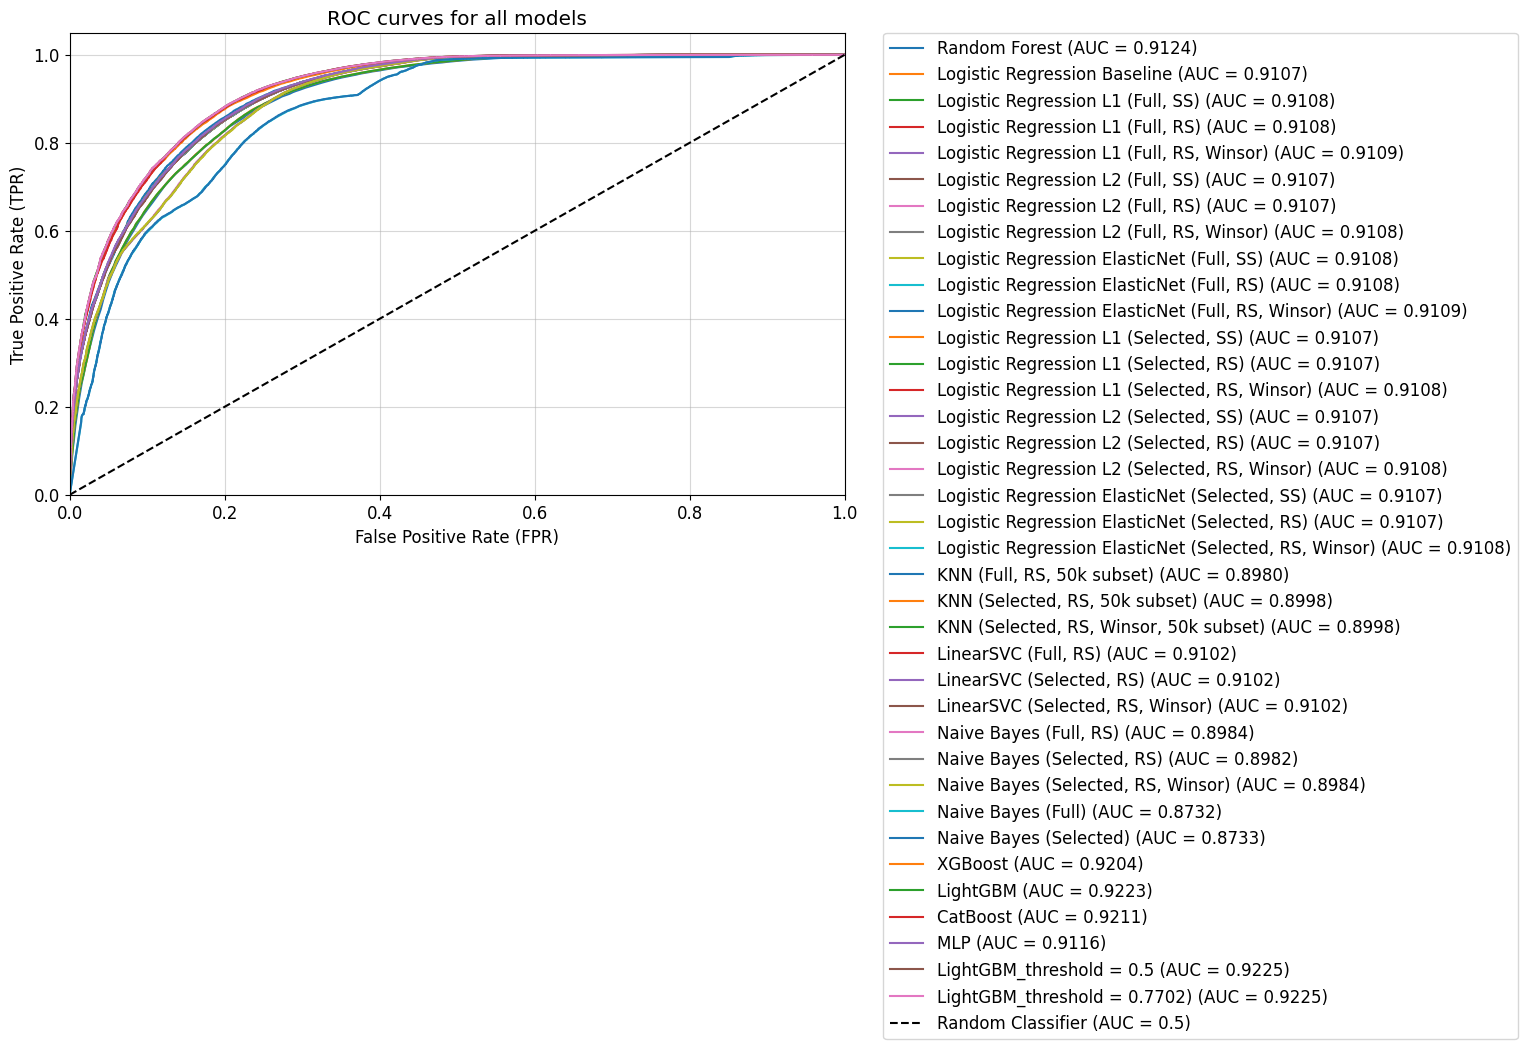

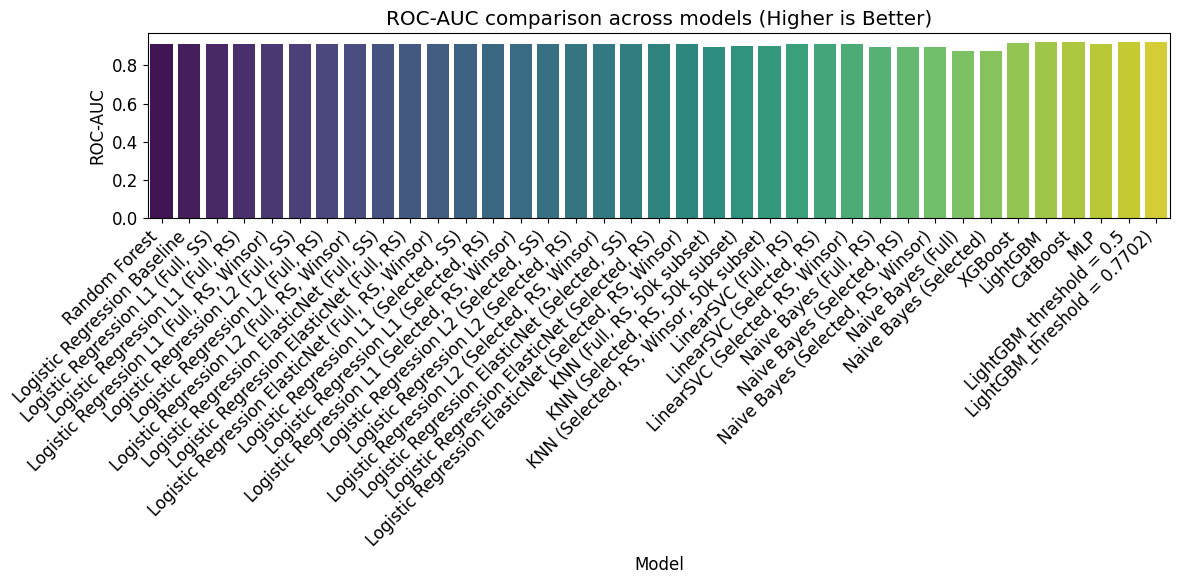

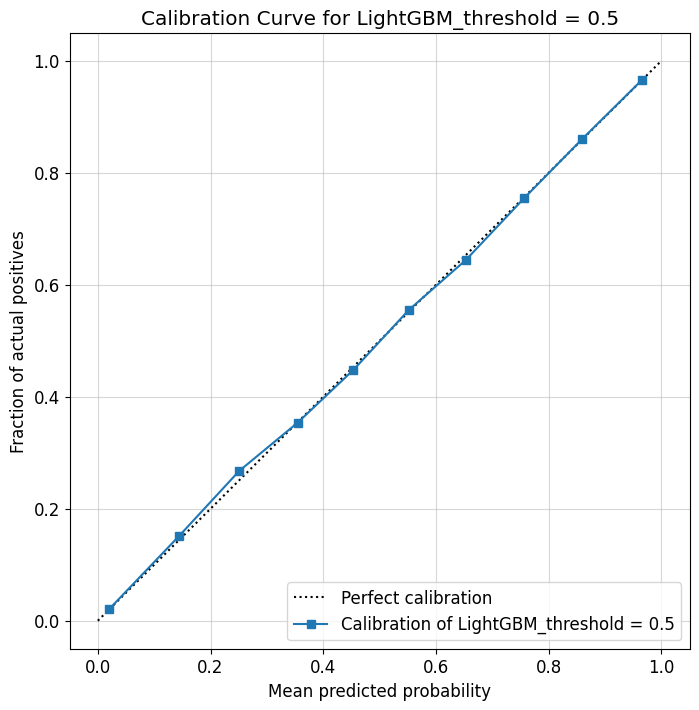

In [69]:
# Build a compact metrics table from `results` (exclude raw predictions to keep it readable)
metrics_df = pd.DataFrame({
    name: {key: val for key, val in res.items() if key not in ['y_pred_proba', 'y_pred', 'Model']}
    for name, res in results.items()}).T

# Ensure metrics are numeric and nicely rounded for display / sorting
metrics_df_display = metrics_df.copy()
cols_to_convert = ['ROC-AUC', 'Accuracy', 'F1', 'Precision', 'Recall'] 

for col in cols_to_convert:
    metrics_df_display[col] = pd.to_numeric(metrics_df_display[col], errors = 'coerce')

metrics_df_display['Accuracy'] = metrics_df_display['Accuracy'].round(4)
metrics_df_display['F1'] = metrics_df_display['F1'].round(4)
metrics_df_display['Precision'] = metrics_df_display['Precision'].round(4)
metrics_df_display['Recall'] = metrics_df_display['Recall'].round(4)
metrics_df_display['ROC-AUC'] = metrics_df_display['ROC-AUC'].round(4)

# Styled summary table (sorted by ROC-AUC)
styled_table = (
    metrics_df_display
    .sort_values(by = 'ROC-AUC', ascending = False)
    .style
    .set_caption("Summary metrics table")
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '16px'), ('font-weight', 'bold')]},
        {'selector': 'th',
         'props': [('font-size', '13px')]},
        {'selector': 'td',
         'props': [('font-size', '12px')]}]))
display(styled_table)

# Compare model discrimination: plot ROC curves for all models with available probability scores
plt.figure(figsize = (10, 6))
for name, res in results.items():
    if 'y_pred_proba' not in res or res['y_pred_proba'] is None:
        continue
    y_proba_scores = res['y_pred_proba']
    if y_proba_scores.ndim > 1 and y_proba_scores.shape[1] > 1:
        y_proba = y_proba_scores[:, 1]
    else:
        y_proba = y_proba_scores
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label = f'{name} (AUC = {roc_auc:.4f})')

# Baseline: random classifier
plt.plot([0, 1], [0, 1], 'k--', label = 'Random Classifier (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC curves for all models')
plt.legend(bbox_to_anchor = (1.05, 1), loc = 2, borderaxespad = 0.0)
plt.grid(True, alpha = 0.5)
plt.show()

# Compare ROC-AUC scores across models
plt.figure(figsize = (12, 6))
sns.barplot(x = metrics_df.index, y = metrics_df['ROC-AUC'], palette = "viridis")
plt.title('ROC-AUC comparison across models (Higher is Better)')
plt.xlabel('Model')
plt.ylabel('ROC-AUC')
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()
plt.show()

# Calibration curve: check how well predicted probabilities match observed frequencies
best_model_name = metrics_df['ROC-AUC'].idxmax() 
best_y_proba_scores = results[best_model_name]['y_pred_proba']

if best_y_proba_scores.ndim > 1 and best_y_proba_scores.shape[1] > 1:
    best_y_proba = best_y_proba_scores[:, 1]
else:
    best_y_proba = best_y_proba_scores

fraction_of_positives, mean_predicted_value = calibration_curve(y_test, best_y_proba, n_bins = 10)

plt.figure(figsize = (8, 8))
plt.plot([0, 1], [0, 1], "k:", label = "Perfect сalibration")
plt.plot(mean_predicted_value, fraction_of_positives, "s-", label = f"Calibration of {best_model_name}")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of actual positives")
plt.title(f"Calibration Curve for {best_model_name}")
plt.legend(loc = "lower right")
plt.grid(True, alpha = 0.5)
plt.show()

#### Discussion of final model performance

- All trained models are compared using a unified set of performance metrics, including ROC-AUC, Accuracy, Precision, Recall, and F1-score. The summary table is sorted by ROC-AUC, which is selected as the primary comparison metric due to class imbalance and its independence from a specific classification threshold. This allows a fair comparison of models based on their intrinsic ranking ability rather than a particular operating point.
- The results clearly show that gradient boosting models — particularly LightGBM, XGBoost, and CatBoost—outperform linear models, distance-based methods, and Naive Bayes in terms of ROC-AUC. Among them, LightGBM achieves the highest overall ROC-AUC, confirming its superior ability to separate defaulted and non-defaulted borrowers across a wide range of thresholds.
- It is important to note that multiple LightGBM entries appear in the table. These correspond to the same underlying model trained with identical hyperparameters, but evaluated under different decision thresholds. While the version with the default threshold = 0.5 maximizes recall and approval rate, the threshold-adjusted version reflects a more conservative operating point designed to explicitly control the False Positive Rate. This comparison illustrates that changes in Accuracy, Precision, Recall, and F1-score are driven by threshold selection rather than differences in the underlying model, while ROC-AUC remains unchanged.
- To further assess model behavior beyond scalar metrics, ROC curves are plotted for all models. These curves confirm the relative ranking observed in the summary table and provide a visual comparison of discriminative performance across the full spectrum of classification thresholds.
- Finally, a calibration curve is constructed for the best-performing model according to ROC-AUC. While ROC-AUC captures ranking quality, calibration analysis evaluates whether predicted probabilities correspond to observed outcome frequencies. This step is particularly important in credit risk applications, where predicted probabilities may be used directly in downstream decision-making, pricing, or risk-based policy design.
- Overall, this comprehensive evaluation confirms that LightGBM provides the strongest combination of discriminative power and practical flexibility. When combined with business-driven threshold calibration, it offers a robust and interpretable foundation for real-world credit risk scoring.

<a id="feature-importance-analysis"></a>
## Feature importance analysis

In [70]:
def plot_top_features_auto(results, metrics_df, final_pipelines, x_train_test_proc, y_test, top_n = 5, booster_feature_names = None):
    '''The function automatically extracts and visualizes the top N most important features for the best-performing model based on ROC-AUC.'''

    # Select the best model based on ROC-AUC
    best_model_name = metrics_df['ROC-AUC'].idxmax()
    best_model = final_pipelines[best_model_name]

    # If the model is a pipeline, extract classifier and (optionally) the preprocessor
    if hasattr(best_model, 'named_steps'):
        classifier = best_model.named_steps['classifier']
        preprocessor = best_model.named_steps.get('preprocessor')
    else:
        classifier = best_model
        preprocessor = None

    # Determine feature names aligned with the transformed feature matrix (prefer provided names, then preprocessor output, then DataFrame columns)
    if booster_feature_names is not None:
        feature_names_final = booster_feature_names
    elif preprocessor is not None:
        try:
            feature_names_final = preprocessor.get_feature_names_out()
        except Exception:
            feature_names_final = x_train_test_proc.columns if hasattr(x_train_test_proc, 'columns') else [f'Feat_{i}' for i in range(x_train_test_proc.shape[1])]
    else:
        feature_names_final = x_train_test_proc.columns if hasattr(x_train_test_proc, 'columns') else [f'Feat_{i}' for i in range(x_train_test_proc.shape[1])]

    # Compute feature importances using the first supported method
    if hasattr(classifier, 'feature_importances_'):
        importances = classifier.feature_importances_
        method = "Feature importance (gain)"
    elif hasattr(classifier, 'coef_'):
        importances = np.abs(classifier.coef_)
        if importances.ndim > 1:
            importances = importances[0]
        method = "Absolute coefficients"
    elif type(classifier).__name__ ==  'Booster':
        importances = classifier.feature_importance(importance_type = 'gain')
        method = "LightGBM booster gain"
    else:
        # Permutation importance is a model-agnostic fallback (more expensive but works broadly)
        r = permutation_importance(classifier, x_train_test_proc, y_test, scoring = 'roc_auc', n_repeats = 5, random_state = 42, n_jobs = -1)
        importances = r.importances_mean
        method = "Permutation importance (ROC-AUC)"

    # Safety: align feature names length with importance vector length
    if len(importances) !=  len(feature_names_final):
        feature_names_final = [f'Feat_{i}' for i in range(len(importances))]

    # Assemble a feature-importance table; optionally drop non-positive importances to focus on meaningful contributors
    feature_importance_df = pd.DataFrame({
        'Feature': feature_names_final,
        'Importance': importances})
    feature_importance_df = feature_importance_df[feature_importance_df['Importance'] > 0]
    top_features = feature_importance_df.sort_values(by = 'Importance', ascending = False).head(top_n)

    # Plot top-N features as a horizontal bar chart
    plt.figure(figsize = (10, 6))
    sns.set_style("whitegrid")
    barplot = sns.barplot(
        x = 'Importance',
        y = 'Feature',
        data = top_features.sort_values(by = 'Importance', ascending = True),
        palette = 'viridis')

    # Add importance values on the bars (format depends on scale)
    for index, value in enumerate(top_features.sort_values(by = 'Importance', ascending = True)['Importance']):
        barplot.text(value + 0.01, index, f'{value:.0f}', va = 'center')

    plt.title(f"Top {top_n} Feature Importances ({best_model_name})", weight = 'bold')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

    return top_features

- The most influential features of the best-performing model are analyzed to improve interpretability and provide insights into the model’s decision-making process.
- The feature importance extraction method is determined dynamically depending on the model type:
    - Tree-based models use built-in feature importance measures based on information gain.
    - Linear models rely on the absolute values of model coefficients.
    - Boosting frameworks (e.g., LightGBM) utilize gain-based importance from the underlying booster.
- For models without native importance measures, permutation importance based on ROC-AUC is applied.
- The top-ranked features are visualized using a horizontal bar chart, highlighting the Top N most important features contributing to the model’s predictions. This analysis supports model transparency and helps identify the key factors influencing credit repayment outcomes, which is especially valuable for model validation and business interpretation.

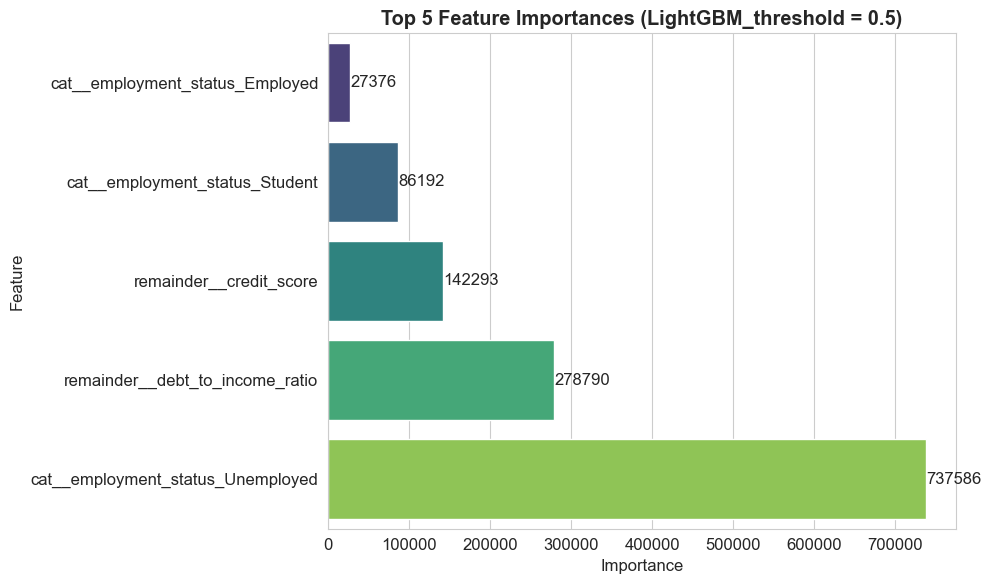

Rank,Feature
1,employment_status_Unemployed
2,debt_to_income_ratio
3,credit_score
4,employment_status_Student
5,employment_status_Employed


In [71]:
top_n = 5

# Extract final feature names after preprocessing (OHE) to keep importances interpretable
feature_names = preprocessor_ohe.get_feature_names_out()

# Compute and plot top-N important features for the best model (by ROC-AUC)
top_features = plot_top_features_auto(
    results = results,
    metrics_df = metrics_df,
    final_pipelines = final_pipelines,
    x_train_test_proc = x_train_test_proc,
    y_test = y_test,
    top_n = top_n,
    booster_feature_names = feature_names)

# Prepare a presentation-friendly top-features table (add rank and strip preprocessing prefixes)
top_features_styler = (
    top_features
    .sort_values(by = 'Importance', ascending = False)
    .head(top_n)
    .reset_index(drop = True)
    .assign(
        Rank = lambda df: range(1, len(df) + 1),
        Feature = lambda df: df['Feature'].str.replace(
            r'^(cat|num|remainder)__', '', regex = True))
    [['Rank', 'Feature']]
    .style
    .hide(axis = "index")
    .set_caption("Top features (importance-based)")
    .set_table_styles([
        {'selector': 'caption',
            'props': [
                ('text-align', 'center'),
                ('font-size', '16px'),
                ('font-weight', 'bold'),
                ('color', 'black'),
                ('margin-bottom', '10px')]},
        {'selector': 'th',
         'props': [
                ('text-align', 'center'),
                ('font-weight', 'bold')]},
        {'selector': 'td',
         'props': [('text-align', 'center')]}]))

# Center the styled table in the notebook output
display(HTML(f"""
<div style = "width:100%; text-align:center;">
    <div style = "display:inline-block;">
        {top_features_styler.to_html()}
    </div>
</div>"""))

#### Feature importance analysis

- The most influential features of the best-performing model are examined to improve interpretability and to validate that model behavior aligns with domain expectations in a credit-risk setting. The feature importance extraction method is selected automatically based on the estimator type: tree-based models use built-in importance measures; linear models rely on absolute coefficient magnitudes; and for a native LightGBM Booster, importance is computed using gain.
- For LightGBM, gain-based importance reflects how much a feature contributes to improving split quality across the ensemble. Importantly, this measure captures the relative usefulness of a feature for prediction but does not indicate the direction of impact (i.e., it does not directly tell whether higher values increase or decrease default risk). In addition, one-hot encoded categorical variables may distribute importance across multiple dummy indicators, and correlated predictors can share importance, so the Top N list should be interpreted as a high-level summary rather than a definitive ranking.
- The Top 5 features are visualized to provide a compact view of the main drivers of the model’s decisions. These features serve as a practical sanity check for potential leakage and help identify the key factors associated with repayment outcomes. In downstream business use, this analysis can support model validation, stakeholder communication, and the design of reason codes or policy rules built around the most influential variables.

<a id="final-prediction-and-submission-file-generation"></a>
## Final prediction and submission file generation

In [72]:
def predict_final_any_model(model, x_test, test_data, preprocessor = None, model_name = "model", threshold = 0.5):
    '''The function performs final inference by generating probability-based predictions for the test data and
    saving them in a standardized submission file. It additionally applies a decision threshold to produce
    binary predictions, which are stored in a separate output file for downstream decision-making.'''

    # Unwrap best estimator if GridSearchCV/RandomizedSearchCV is passed
    if hasattr(model, "best_estimator_"):
        model = model.best_estimator_

    # Use pipeline preprocessing and the final estimator for prediction
    if isinstance(model, Pipeline):
        Xt = x_test

        # Apply all preprocessing steps (everything except the final estimator)
        for name, step in model.steps[:-1]:
            if step is None:
                continue
            if hasattr(step, "transform"):
                Xt = step.transform(Xt)
            else:
                raise TypeError(f"Pipeline step '{name}' has no transform().")

        est = model.steps[-1][1]
        x_test_proc = Xt

    else:
        # Non-pipeline: apply provided preprocessor if available (e.g., for lgb.train Booster)
        x_test_proc = preprocessor.transform(x_test) if preprocessor is not None else x_test
        est = model

    # Generate probability-like scores using model-specific prediction interfaces
    try:
        y_proba = None

        # Preferred: standard scikit-learn probability output
        if hasattr(est, "predict_proba"):
            proba = est.predict_proba(x_test_proc)
            proba = np.asarray(proba)
            y_proba = proba[:, 1] if proba.ndim == 2 and proba.shape[1] > 1 else proba

        # Fallback: decision_function (e.g., SVM without probabilities)
        elif hasattr(est, "decision_function"):
            y_proba = np.asarray(est.decision_function(x_test_proc))

        # CatBoost: sometimes supports prediction_type = "Probability" on native model
        elif "catboost" in str(type(est)).lower() and hasattr(est, "predict"):
            pred = None
            try:
                pred = est.predict(x_test_proc, prediction_type = "Probability")
            except Exception:
                pred = None

            if pred is not None:
                pred = np.asarray(pred)
                y_proba = pred[:, 1] if pred.ndim == 2 and pred.shape[1] > 1 else pred
            else:
                y_proba = np.asarray(est.predict(x_test_proc))

        # LightGBM native Booster / other models: predict() often returns probability directly
        elif hasattr(est, "predict"):
            y_proba = np.asarray(est.predict(x_test_proc))

        else:
            raise ValueError(f"Model {model_name} cannot predict.")

    except Exception as e:
        raise RuntimeError(f"Prediction failed for {model_name}: {e}")

    # Ensure 1D probabilities/scores
    y_proba = np.asarray(y_proba).ravel()

    # Validate prediction length against the test dataset
    if len(y_proba) != len(test_data):
        raise ValueError("Prediction length does not match test data length.")

    # Sanitize model name to produce filesystem-safe output filenames
    safe_name = re.sub(r"[^A-Za-z0-9._-]+", "_", str(model_name)).strip("_")

    # Create submission file with probability predictions
    submission_df = pd.DataFrame({
        "id": test_data["id"].values,
        "loan_paid_back": np.round(y_proba, 1)})
    submission_file = f"submission_{safe_name}.csv"
    submission_df.to_csv(submission_file, index = False)

    # Create decision file with threshold-based binary predictions
    decision_df = submission_df.rename(columns = {"loan_paid_back": "proba"}).copy()
    decision_df["prediction"] = (decision_df["proba"] >= threshold).astype(int)
    decision_file = f"predictions_{safe_name}_thr_{threshold:.4f}.csv"
    decision_df.to_csv(decision_file, index = False)

    # Render compact previews of the generated outputs for notebook inspection
    submission_preview = (
        submission_df.head(5)
        .style
        .hide(axis = "index")
        .format({"loan_paid_back": "{:.1f}"})
        .set_caption(f"Submission preview (first 5 rows) — {submission_file}")
        .set_table_styles([
            {'selector': 'caption', 'props': [
                ('text-align', 'center'),
                ('font-size', '16px'),
                ('font-weight', 'bold'),
                ('color', 'black'),
                ('margin-bottom', '10px'),
                ('white-space', 'nowrap')]},
            {'selector': 'th', 'props': [
                ('text-align', 'center'),
                ('font-weight', 'bold')]},
            {'selector': 'td', 'props': [('text-align', 'center')]}]))

    decision_preview = (
        decision_df.head(5)
        .style
        .hide(axis = "index")
        .format({"proba": "{:.1f}"})
        .set_caption(f"Decision preview (first 5 rows) {decision_file}")
        .set_table_styles([
            {'selector': 'caption', 'props': [
                ('text-align', 'center'),
                ('font-size', '16px'),
                ('font-weight', 'bold'),
                ('color', 'black'),
                ('margin-bottom', '10px'),
                ('white-space', 'nowrap')]},
            {'selector': 'th', 'props': [
                ('text-align', 'center'),
                ('font-weight', 'bold')]},
            {'selector': 'td', 'props': [('text-align', 'center')]}]))

    display(HTML(f'''
    <div style = "width:100%; text-align:center;">
        <div style = "display:inline-block;">
            {submission_preview.to_html()}
        </div>
    </div>'''))

    display(HTML(f'''
    <div style = "width:100%; text-align:center; margin-top: 16px;">
        <div style = "display:inline-block;">
            {decision_preview.to_html()}
        </div>
    </div>'''))

    return submission_df, decision_df

- The `predict_final_any_model` function performs final inference for a trained classification model and generates standardized output files for downstream usage.
- The function supports heterogeneous model types, including:
    - scikit-learn estimators and Pipelines;
    - search objects such as `GridSearchCV` and `RandomizedSearchCV`;
    - native LightGBM (`lgb.train`) and CatBoost models.
- Before inference, the function prepares the model and test features:
    - if a search object is provided, the underlying `best_estimator_` is extracted;
    - if the model is a scikit-learn `Pipeline`, all preprocessing steps are applied manually and the final estimator is used for prediction;
    - if the model is not a pipeline, an external `preprocessor` may be applied if provided.
- The function retrieves continuous model scores in a flexible, model-agnostic manner:
    - `predict_proba` is used when available to obtain positive-class probabilities;
    - if probability estimates are not supported, the function falls back to `decision_function`;
    - for native CatBoost models, probability outputs are requested explicitly when supported;
    - as a last resort, `predict` is used when it returns continuous numeric outputs (e.g. LightGBM Booster).
- The resulting scores (`y_proba`) are treated as probability-like values and validated to match the length of the test dataset.
- Two output files are generated:
    - a submission file containing instance identifiers and predicted probabilities;
    - a decision file containing probabilities and binary predictions obtained by applying a configurable decision threshold.
- File names are sanitized using the provided model_name to ensure filesystem safety and reproducibility.
- For interactive analysis, compact previews of both output files are rendered in the notebook.
- The function returns both the submission DataFrame and the threshold-based decision DataFrame for further inspection or reuse.

In [73]:
submission_df, decision_df = predict_final_any_model(
    model = bst,
    x_test = x_test,
    test_data = test_data,
    preprocessor = preprocessor_ohe,
    model_name = "LightGBM_best",
    threshold = best_thr)

id,loan_paid_back
593994,0.9
593995,1.0
593996,0.6
593997,0.9
593998,1.0


id,proba,prediction
593994,0.9,1
593995,1.0,1
593996,0.6,0
593997,0.9,1
593998,1.0,1


- The generated submission file contains the predicted probabilities of loan repayment for each test instance and is intended for evaluation or external submission. The auxiliary decision file includes both the predicted probabilities and the corresponding binary predictions obtained using the optimized decision threshold. This separation allows the probabilistic model output to be preserved while enabling threshold-based decisions for practical or business-oriented use cases.